[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T01_C_alta_frecuencia_es.ipynb)
> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Módulo 1 — Lo que el trimestre esconde: el ciclo a frecuencia mensual, semanal y diaria

**Curso complementario · puremacro**

T01_A midió los hechos del ciclo sobre trimestres, porque las cuentas nacionales son trimestrales. Pero el trimestre es una elección, no un hecho. El mercado de trabajo se mide cada mes; los precios, cada mes; el VIX, cada día; la tasa de política cambia el día del anuncio. Casi todo lo que llamamos «el ciclo» ocurre a una frecuencia más alta que la del PIB, y el PIB trimestral es el *promedio* de esos meses — un promedio que eligió quien construyó las cuentas, no la economía.

Un promedio hace tres cosas, y las tres se pueden medir. Filtra: quita el ruido de alta frecuencia, y con él quita también la caída de un mes que no dura tres. Fabrica persistencia: Working (1960) demostró que promediar un paseo aleatorio en bloques de tres produce diferencias con autocorrelación $4/19$, sin que nadie haya decidido nada. Y borra fechas: un choque que dura un mes, promediado con dos meses tranquilos, no supera ningún umbral. Muestrear en vez de promediar —quedarse con el último mes del trimestre— evita lo segundo y empeora lo primero.

La tesis de esta lección cabe en una frase: **cada sección muestra algo que el promedio trimestral borra.** La profundidad de una recesión (§1). La velocidad a la que el paro converge a su estado estacionario, que es de dos meses y por tanto invisible en datos de tres (§2). Nueve de catorce choques de incertidumbre (§3). Los dos tercios del trimestre que ya se conocen cuando termina su primer mes (§4). La restricción de *timing* que identifica un choque monetario (§5). Y la ola de veintiún meses con la que una recesión recorre cincuenta estados (§6). También se muestra lo que el trimestre *no* borra —las fechas del ciclo, la elasticidad de emparejamiento, la forma de una respuesta dinámica—, porque las hipótesis que fallaron en los datos se quedan, con su test negativo al lado. Finalmente, implementamos el Experimento Macroeconómico 3 para replicar y resolver el «price puzzle» empírico (§7).

### Objetivos de aprendizaje
Al terminar esta lección podrás:
1. **Medir lo que hace el promedio**: reproducir el efecto de Working por simulación y sobre la producción industrial, distinguir la referencia de ruido blanco de una media ($\sqrt{19/9}$) de la de un muestreo ($\sqrt{3}$), y cuantificar cuánta profundidad de cada recesión se pierde al promediar — y cuántas fechas del ciclo (ninguna).
2. **Leer el paro como un estado estacionario mensual**: $u^* = s/(s+f)$ mes a mes, su velocidad de convergencia, por qué componer el trimestre «a la ingenua» sesga $u^*$ mientras que promediar $s$ y $f$ no; estimar la función de emparejamiento de JOLTS a dos frecuencias y el bucle de Beveridge de 2020–24.
3. **Fechar choques a la frecuencia a la que ocurren**: la regla de Bloom sobre el VIX diario agregado a mensual, proyecciones locales mensuales y trimestrales sobre el mismo choque, y tres medidas de incertidumbre comparadas por su innovación.
4. **Hacer un nowcast** del PIB trimestral con MIDAS y con un modelo de factores con borde irregular, evaluarlo pseudo fuera de muestra contra un AR(1), y decir con precisión cuándo gana (2008–09, 2020) y cuándo no (el resto).
5. **Estimar la transmisión monetaria en México e identificar el efecto información del banco central**: formular una regla recursiva mensual y usar la dirección de los anuncios de Banxico como instrumento, contrastando variaciones de política no purgadas frente a la identificación en ventanas de alta frecuencia (Gertler & Karadi 2015) para resolver el «price puzzle» (Sims 1992, Miranda-Agrippino & Ricco 2021).
6. **Convertir la regla de Sahm en una distribución entre 51 estados bajo la teoría de Áreas Monetarias Óptimas**: cuantificar difusión, orden de llegada, dispersión y persistencia del desempleo interestatal (Blanchard & Katz 1992) como mecanismo de ajuste en una unión monetaria sin flexibilidad cambiaria nominal (Mundell 1961).
7. **Ejecutar el Experimento Macroeconómico 3**: Estimar proyecciones locales de Jordà a 24 meses sobre datos mensuales de EE. UU. para replicar el rompecabezas de precios empírico con variaciones de tasas no purgadas, y resolverlo purgando las innovaciones de política monetaria de las expectativas de inflación adelantada (Romer & Romer 2004).

Todo corre en Python puro sobre las series mensuales, semanales y diarias que congela `data_curso/`, sin red.

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

_cwd = __import__("pathlib").Path.cwd()


def _here(p):
    # Un sistema de archivos en sandbox (iOS) lanza PermissionError desde
    # .exists() en vez de devolver False; tratamos ilegible como ausente.
    try:
        return p.exists()
    except OSError:
        return False


_nb = _cwd if _here(_cwd / "_nbstyle.py") else _cwd / "notebooks"
sys.path.insert(0, str(_nb))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor

# Las series mensuales de FRED, el VIX diario, los flujos de la CPS, la ENOE y la
# IP de México que congela data_curso/ (T01_B §6). Nada de aquí toca la red.
from _datos import DATOS
from puremacro.spectral import business_cycle_band_power       # §1
from puremacro.labor_flows import transitions_from_shimer      # §2
from puremacro.inference import newey_west                     # §2, §4
from puremacro.regress import ols, add_constant                # §2, §4
from puremacro.data import hp_filter                           # §3
from puremacro.lp import lp_hac, lp_iv, panel_lp               # §3, §5, §6
from puremacro.midas import u_midas, beta_midas                # §4
from puremacro.nowcast import kalman_dfm                       # §4

cols = _nbstyle.palette(5)          # el más prominente primero
HASTA = "2019-12-31"    # 2020 no es un ciclo económico; ver T01_A §1.1


def _fred(serie):
    """Una serie de FRED congelada en data_curso/, indexada por fecha (primer día del periodo)."""
    df = pd.read_csv(DATOS / f"{serie}.csv", parse_dates=["observation_date"],
                     index_col="observation_date")
    return df[serie].astype(float)

## 1. Lo que promediar esconde

El PIB trimestral es una media de tres meses, y una media tiene dos efectos que no se ven hasta que se mira el mes. El primero es mecánico y lo demostró Working (1960): promedia un paseo aleatorio en bloques de $m$ observaciones y las diferencias de las medias dejan de ser ruido blanco — nace un MA(1) con autocorrelación $(m^2-1)/(2(2m^2+1))$, que con $m=3$ es $4/19 = 0.21$ y tiende a $1/4$. Nadie decidió nada: es la aritmética del promedio. El segundo es que una media no puede caer tanto como su peor mes; toda caída pico-valle medida sobre trimestres está sesgada hacia cero, y el sesgo crece con la *velocidad* de la caída, no con su tamaño.

Esta sección mide los dos efectos sobre la producción industrial (INDPRO) y el empleo privado (USPRIV), fecha el ciclo mes a mes con un Bry–Boschan de veinte líneas de numpy, y pregunta cuánto de lo que el trimestre esconde son fechas y cuánto es profundidad. La respuesta corta: casi nada de fechas y bastante de profundidad. T01_A §4 midió los hechos del ciclo sobre trimestres; aquí se ve qué parte de esos números la fabricó el trimestre.

**Una nota sobre los datos, porque es la razón de que esto sea una sección y no una nota al pie.** USREC codifica la recesión como 1 desde el mes *siguiente* al pico del NBER hasta el mes del valle inclusive; el pico es, por tanto, el mes anterior al primer 1, y equivocarse en esa convención desplaza todos los errores de fechado un mes. Los segundos momentos —autocorrelaciones, desviaciones típicas, cuotas espectrales— se cortan en 2019T4, como en T01_A §1.1. Las recesiones de 2020 (Estados Unidos y México) entran solo en las profundidades y en el fechado, donde el episodio es el objeto y no un momento muestral. La media trimestral es la media de los *niveles* y después el logaritmo, que es lo que hacen las cuentas nacionales. México no tiene NBER, así que sus ventanas son las de la propia serie (MEI de la OCDE, desestacionalizada).

In [3]:
# --- Working (1960): promediar un paseo aleatorio fabrica un MA(1) ------------
# Si X_t es paseo aleatorio y Q_k la media de m observaciones, ΔQ_k pesa los
# incrementos con (1,2,3,2,1)/3: var = 19/9, cov(1) = 4/9, rho1 = 4/19.
m = 3
rho_working = (m**2 - 1) / (2 * (2 * m**2 + 1))
rng = np.random.default_rng(1960)
x = np.cumsum(rng.standard_normal(3 * 200_000))          # 200 000 trimestres
q_media = x.reshape(-1, 3).mean(axis=1)
q_fin = x.reshape(-1, 3)[:, -1]


def ac(v, k=1):
    v = np.asarray(v, float); v = v - v.mean()
    return float((v[k:] * v[:-k]).sum() / (v * v).sum())


rho_sim_media, rho_sim_fin = ac(np.diff(q_media)), ac(np.diff(q_fin))
print(f"Working (1960), m=3: rho1 teórica = {rho_working:.4f} (límite m->inf: 0.25)")
print(f"  simulación, media trimestral : {rho_sim_media:.4f}")
print(f"  simulación, último mes       : {rho_sim_fin:+.4f}")
assert abs(rho_sim_media - rho_working) < 0.01 and abs(rho_sim_fin) < 0.01


# --- Las mismas tres versiones en INDPRO y USPRIV, 1948-2019 -----------------
def tres_versiones(nivel):
    """Δlog x100 en tres muestreos: mensual, media trimestral, último mes del trimestre."""
    n = nivel.loc["1948":HASTA]
    d_m = 100 * np.log(n).diff().dropna()
    d_qm = 100 * np.log(n.resample("QE").mean()).diff().dropna()
    d_qf = 100 * np.log(n.resample("QE").last()).diff().dropna()
    return d_m, d_qm, d_qf


ref_media, ref_fin = np.sqrt(19 / 9), np.sqrt(3)     # ruido blanco: media trim., último mes
filas = []
for nombre in ["INDPRO", "USPRIV"]:
    d_m, d_qm, d_qf = tres_versiones(_fred(nombre))
    r_med, r_fin = d_qm.std(ddof=1) / d_m.std(ddof=1), d_qf.std(ddof=1) / d_m.std(ddof=1)
    filas.append({"serie": nombre, "n_meses": len(d_m),
                  "rho1 mensual": ac(d_m), "rho2 mensual": ac(d_m, 2), "rho3 mensual": ac(d_m, 3),
                  "rho1 media trim.": ac(d_qm), "rho1 último mes": ac(d_qf),
                  "sd mensual": d_m.std(ddof=1), "sd/sd_m media trim.": r_med, "sd/sd_m último mes": r_fin,
                  "var/ruido blanco, media": (r_med / ref_media) ** 2,
                  "var/ruido blanco, último": (r_fin / ref_fin) ** 2,
                  # cuota de la banda 1.5-8 años; segmentos de Welch de 16 años en las dos frecuencias
                  "banda 18-96m (mensual)": business_cycle_band_power(d_m.to_numpy(), fs=12, low_period=1.5, high_period=8, n_seg=192),
                  "banda 6-32q (media trim.)": business_cycle_band_power(d_qm.to_numpy(), fs=4, low_period=1.5, high_period=8, n_seg=64),
                  "banda 6-32q (último mes)": business_cycle_band_power(d_qf.to_numpy(), fs=4, low_period=1.5, high_period=8, n_seg=64),
                  "< 18 meses (mensual)": business_cycle_band_power(d_m.to_numpy(), fs=12, low_period=2 / 12, high_period=1.5, n_seg=192)})
AC = pd.DataFrame(filas).set_index("serie").T
print(f"\nΔlog de INDPRO y USPRIV, 1948-2019 (referencia ruido blanco: sd media trim. = "
      f"{ref_media:.3f} sd_m, último mes = {ref_fin:.3f} sd_m):")
print(AC.round(3).to_string())
brecha = AC.loc["rho1 media trim."] - AC.loc["rho1 último mes"]
print(f"\nrho1, media trimestral menos último mes: INDPRO {brecha['INDPRO']:+.2f}, USPRIV {brecha['USPRIV']:+.2f}")
assert 0.05 < brecha["INDPRO"] < 0.25 and (AC.loc["var/ruido blanco, media"] > 1.5).all()
assert (AC.loc["banda 18-96m (mensual)"] < AC.loc["banda 6-32q (media trim.)"]).all()

Working (1960), m=3: rho1 teórica = 0.2105 (límite m->inf: 0.25)
  simulación, media trimestral : 0.2065
  simulación, último mes       : -0.0002

Δlog de INDPRO y USPRIV, 1948-2019 (referencia ruido blanco: sd media trim. = 1.453 sd_m, último mes = 1.732 sd_m):
serie                       INDPRO   USPRIV
n_meses                    863.000  863.000
rho1 mensual                 0.384    0.428
rho2 mensual                 0.257    0.473
rho3 mensual                 0.216    0.408
rho1 media trim.             0.527    0.759
rho1 último mes              0.409    0.681
sd mensual                   0.946    0.326
sd/sd_m media trim.          2.056    2.262
sd/sd_m último mes           2.172    2.323
var/ruido blanco, media      2.003    2.424
var/ruido blanco, último     1.573    1.799
banda 18-96m (mensual)       0.280    0.445
banda 6-32q (media trim.)    0.585    0.731
banda 6-32q (último mes)     0.538    0.702
< 18 meses (mensual)         0.692    0.481

rho1, media trimestral menos últ

### 1.1 Working está en INDPRO: 0.12 de autocorrelación que no fabricaron los datos

Mes a mes, el crecimiento de INDPRO tiene autocorrelación 0.38 a un rezago, 0.26 a dos y 0.22 a tres (863 meses). Toma el último mes de cada trimestre y la autocorrelación trimestral es 0.41; promedia los tres meses y sube a 0.53. Los 0.12 de diferencia son Working: los mismos datos, la misma frecuencia, y la única diferencia es cómo se construyó el trimestre. En USPRIV son 0.68 frente a 0.76 (+0.08): el empleo ya es tan persistente que el promedio tiene menos que añadir.

La escala de la varianza cuenta lo mismo con otro número. Si el crecimiento mensual fuera ruido blanco, la desviación típica del crecimiento de la media trimestral sería $\sqrt{19/9} = 1.45$ veces la mensual, y la del último mes $\sqrt{3} = 1.73$ veces. En INDPRO son 2.06 y 2.17: la varianza trimestral es 2.0 veces la que el ruido blanco justificaría con el promedio y 1.6 veces con el último mes. Esa razón es una medida de persistencia mensual que no necesita ningún modelo — y en USPRIV vale 2.4 y 1.8.

El espectro dice dónde vive lo que el trimestre no ve. El 69% de la varianza del crecimiento mensual de INDPRO (48% en USPRIV) está en periodos de menos de 18 meses. La cuota de la banda de ciclo (1.5–8 años, los 18–96 meses o 6–32 trimestres de Burns–Mitchell) es 0.28 en el mes y 0.59 en la media trimestral. No hay más ciclo en el trimestre: hay menos ruido, porque promediar es un filtro de paso bajo, y las cuotas espectrales de T01_A §4 se miden sobre series que ya pasaron por él.

In [4]:
# --- Profundidad de las recesiones: mes a mes frente a medias trimestrales ----
rec = _fred("USREC").loc["1947":]
d = rec.diff()
NBER = pd.DataFrame({"pico": [t - pd.DateOffset(months=1) for t in rec.index[d == 1]],
                     "valle": [t - pd.DateOffset(months=1) for t in rec.index[d == -1]]})
print(f"{len(NBER)} recesiones NBER desde 1948 (USREC): pico = mes anterior al primer 1, valle = último 1")


def caida(log_nivel, ini, fin):
    """Máximo en [ini, fin] y mínimo posterior dentro de la ventana, en puntos log x100."""
    w = log_nivel.loc[ini:fin]
    t_max = w.idxmax()
    t_min = w.loc[t_max:].idxmin()
    return float(w.loc[t_max] - w.loc[t_min]), t_max, t_min


def caidas(nivel, pico, valle, margen=3):
    lm = 100 * np.log(nivel)
    lq = 100 * np.log(nivel.resample("QE").mean())          # media de niveles, luego log
    ini, fin = pico - pd.DateOffset(months=margen), valle + pd.DateOffset(months=margen)
    cm, t0, t1 = caida(lm, ini, fin)
    cq, _, _ = caida(lq, ini - pd.offsets.QuarterEnd(0), fin + pd.offsets.QuarterEnd(0))
    return cm, cq, t0, t1


PROF = []
for nombre in ["INDPRO", "USPRIV"]:
    s = _fred(nombre)
    for _, r in NBER.iterrows():
        cm, cq, t0, t1 = caidas(s, r["pico"], r["valle"])
        PROF.append({"serie": nombre, "pico NBER": r["pico"].strftime("%Y-%m"),
                     "máx serie": t0.strftime("%Y-%m"), "mín serie": t1.strftime("%Y-%m"),
                     "meses": (t1.year - t0.year) * 12 + t1.month - t0.month,
                     "caída mensual": cm, "caída trimestral": cq, "el trimestre resta": cm - cq})
PROF = pd.DataFrame(PROF)
P_IP = PROF[PROF["serie"] == "INDPRO"].set_index("pico NBER").drop(columns="serie")
P_EM = PROF[PROF["serie"] == "USPRIV"].set_index("pico NBER").drop(columns="serie")
print("\nINDPRO, caída pico-valle (100 x log), mes a mes vs media trimestral:")
print(P_IP.round(1).to_string())
print("\nUSPRIV:")
print(P_EM.round(1).to_string())
resta_ip, resta_em = P_IP["el trimestre resta"], P_EM["el trimestre resta"]
print(f"\nINDPRO: el trimestre resta {resta_ip.median():.1f} pp en la recesión mediana "
      f"(de {resta_ip.min():.1f} en {resta_ip.idxmin()} a {resta_ip.drop('2020-02').max():.1f} en "
      f"{resta_ip.drop('2020-02').idxmax()}); mediana de las caídas mensuales {P_IP['caída mensual'].median():.1f} pp")
print(f"USPRIV: mediana {resta_em.median():.1f} pp; 2020: {resta_em.loc['2020-02']:.1f} pp "
      f"({P_EM.loc['2020-02', 'caída mensual']:.1f} mensual, {P_EM.loc['2020-02', 'caída trimestral']:.1f} trimestral)")
assert (resta_ip >= -0.05).all() and (resta_em >= -0.05).all()   # promediar nunca profundiza una caída
assert resta_ip.loc["2020-02"] == resta_ip.max() and resta_em.median() < resta_ip.median()

# 2020 con las fechas del NBER: feb -> abr mes a mes, 2020T1 -> 2020T2 en medias
lip = 100 * np.log(_fred("INDPRO")); lipq = 100 * np.log(_fred("INDPRO").resample("QE").mean())
c_feb_abr = float(lip.loc["2020-02-01"] - lip.loc["2020-04-01"])
c_q1_q2 = float(lipq.loc["2020-03-31"] - lipq.loc["2020-06-30"])
print(f"2020 con fechas NBER: INDPRO feb->abr {c_feb_abr:.1f} pp; medias 2020T1->2020T2 {c_q1_q2:.1f} pp; "
      f"el trimestre resta {c_feb_abr - c_q1_q2:.1f} pp = {100 * (c_feb_abr - c_q1_q2) / c_feb_abr:.0f}% de la caída")
assert c_feb_abr > 15 and c_feb_abr - c_q1_q2 > 3

# México: IP desestacionalizada (MEI, OCDE); no hay NBER, las ventanas son las de la serie
mx = pd.read_csv(DATOS / "oecd_mei_mex_log_ip.csv", parse_dates=["date"], index_col="date")["log_ip_x100"]
MX = []
for etiqueta, ini, fin in [("Tequila 1994-95", "1994-06-01", "1995-12-01"),
                           ("2008-09", "2008-03-01", "2009-12-01"), ("2020", "2019-10-01", "2020-12-01")]:
    cm, cq, t0, t1 = caidas(np.exp(mx / 100), pd.Timestamp(ini), pd.Timestamp(fin), margen=0)
    MX.append({"episodio": etiqueta, "máx": t0.strftime("%Y-%m"), "mín": t1.strftime("%Y-%m"),
               "caída mensual": cm, "caída trimestral": cq, "el trimestre resta": cm - cq})
MX = pd.DataFrame(MX).set_index("episodio")
print("\nMéxico, IP desestacionalizada:")
print(MX.round(1).to_string())
assert MX.loc["2020", "el trimestre resta"] > 5

12 recesiones NBER desde 1948 (USREC): pico = mes anterior al primer 1, valle = último 1

INDPRO, caída pico-valle (100 x log), mes a mes vs media trimestral:
          máx serie mín serie  meses  caída mensual  caída trimestral  el trimestre resta
pico NBER                                                                                
1948-11     1948-10   1949-10     12           10.3               7.8                 2.5
1953-07     1953-07   1954-04      9           10.0               8.4                 1.5
1957-08     1957-07   1958-04      9           13.6              11.8                 1.8
1960-04     1960-01   1960-12     11            9.0               7.8                 1.1
1969-12     1969-10   1970-11     13            7.2               6.2                 1.1
1973-11     1973-11   1975-05     18           14.0              13.5                 0.6
1980-01     1980-02   1980-07      5            6.9               6.0                 0.9
1981-07     1981-07   1982-12  

### 1.2 El trimestre resta un punto a cada recesión, y cinco a 2020

En las once recesiones de 1948–2009, la caída pico-valle de INDPRO medida sobre medias trimestrales es entre 0.0 pp (2001) y 2.5 pp (1948) menor que la medida mes a mes; la mediana es 1.0 pp sobre caídas medianas de 9.9 pp. En el empleo privado, que cae despacio, la mediana es 0.2 pp: el sesgo del promedio es proporcional a la velocidad de la caída, no a su tamaño, y por eso la recesión más larga de la muestra (2007–09, 18 meses de caída) pierde 0.8 pp y la de 1948, 12 meses y más abrupta, 2.5.

2020 es la demostración. De febrero a abril INDPRO cayó 18.1 pp; la media de 2020T1 contra la de 2020T2 cae 13.4. El trimestre esconde 4.7 puntos —el 26% de la recesión— porque T1 tiene dos meses buenos y T2 tiene dos meses de recuperación. (Medida desde el máximo propio de la serie, noviembre de 2019, la caída es 18.7 frente a 15.2, que es la barra de la figura.) El empleo privado, que en 2020 cayó tan rápido como la producción, pierde 3.7 pp: 17.6 frente a 14.0. México, con la IP desestacionalizada de la OCDE: Tequila 17.0 frente a 15.3 (1.7 pp), 2008–09 12.5 frente a 11.8 (0.7 pp) y 2020 33.3 frente a 25.5 — 7.8 pp, la caída más grande y el sesgo más grande de la sección, en una recesión de cuatro meses.

In [5]:
# --- Fechar el ciclo: Bry-Boschan-lite en numpy ------------------------------
def bry_boschan_lite(x, ventana=5, fase_min=5, ciclo_min=15):
    """Extremos locales en ±ventana, alternancia pico/valle, fase >= fase_min,
    ciclo (pico a pico o valle a valle) >= ciclo_min. Devuelve [(t, +1 pico / -1 valle)]."""
    x = np.asarray(x, float); n = len(x)
    tp = []
    for t in range(ventana, n - ventana):
        w = x[t - ventana:t + ventana + 1]
        if x[t] == w.max():
            tp.append((t, +1))
        elif x[t] == w.min():
            tp.append((t, -1))

    def alternar(tp):
        out = []
        for t, k in tp:
            if out and out[-1][1] == k:              # dos del mismo tipo: se queda el más extremo
                if k * x[t] > k * x[out[-1][0]]:
                    out[-1] = (t, k)
            else:
                out.append((t, k))
        return out

    while True:
        tp = alternar(tp)
        fases = [tp[i + 1][0] - tp[i][0] for i in range(len(tp) - 1)]
        ciclos = [tp[i + 2][0] - tp[i][0] for i in range(len(tp) - 2)]
        if fases and min(fases) < fase_min:          # fase corta: fuera los dos puntos
            i = int(np.argmin(fases)); del tp[i:i + 2]; continue
        if ciclos and min(ciclos) < ciclo_min:       # ciclo corto: fuera el menos extremo
            i = int(np.argmin(ciclos)); k = tp[i][1]
            del tp[i if k * x[tp[i][0]] < k * x[tp[i + 2][0]] else i + 2]; continue
        return tp


def meses(a, b):
    return (a.year - b.year) * 12 + a.month - b.month


def errores_fechado(fechas, tipo, nber, tol=12):
    """Para cada fecha NBER, meses al giro más cercano del mismo tipo (NaN si no hay a ±tol)."""
    out = []
    for f in nber:
        dist = [meses(d, f) for d, k in fechas if k == tipo and abs(meses(d, f)) <= tol]
        out.append(min(dist, key=abs) if dist else np.nan)
    return np.array(out, float)


def evaluar(serie, mensual=True):
    if mensual:
        tp = bry_boschan_lite(serie.to_numpy())
        fechas = [(serie.index[t], k) for t, k in tp]
    else:                                             # trimestral: fechado en el mes central
        tp = bry_boschan_lite(serie.to_numpy(), ventana=2, fase_min=2, ciclo_min=5)
        fechas = [(serie.index[t] - pd.DateOffset(months=1), k) for t, k in tp]
    e = np.r_[errores_fechado(fechas, +1, NBER["pico"]), errores_fechado(fechas, -1, NBER["valle"])]
    extra = [d for d, k in fechas if k == 1 and all(abs(meses(d, f)) > 12 for f in NBER["pico"])]
    return {"giros emparejados": int(np.isfinite(e).sum()), "mediana |error|": float(np.nanmedian(np.abs(e))),
            "media |error|": float(np.nanmean(np.abs(e))), "sesgo medio": float(np.nanmean(e)),
            "picos sin recesión NBER": len(extra), "_e": e, "_fechas": fechas, "_extra": extra}


# Compuesto coincidente: Δlog de IP, empleo privado y ocupados (CPS), cada uno dividido
# por su sd de 1948-2019, promediados y acumulados -- la receta del Conference Board
# sin la corrección de tendencia. 2020 entra: aquí el episodio es el objeto.
FIN_FECHADO = "2023-12-31"
dl = pd.concat([100 * np.log(_fred(s)).diff() for s in ["INDPRO", "USPRIV", "CE16OV"]],
               axis=1).loc["1948":FIN_FECHADO].dropna()
comp = (dl / dl.loc[:HASTA].std(ddof=1)).mean(axis=1).cumsum()
ip_m = np.log(_fred("INDPRO")).loc["1948":FIN_FECHADO]
RES = {"INDPRO mensual": evaluar(ip_m), "compuesto mensual": evaluar(comp),
       "INDPRO trimestral": evaluar(np.log(_fred("INDPRO").resample("QE").mean()).loc["1948":FIN_FECHADO], False),
       "compuesto trimestral": evaluar(comp.resample("QE").mean(), False)}
for k, v in RES.items():
    print(f"{k:21s} errores (meses, algoritmo - NBER)  picos {v['_e'][:12]}")
    print(f"{'':21s}                                   valles {v['_e'][12:]}")
    if v["_extra"]:
        print(f"{'':21s} picos sin recesión NBER a ±12 meses: " + ", ".join(d.strftime("%Y-%m") for d in v["_extra"]))
RESUMEN = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if not kk.startswith("_")} for k, v in RES.items()}).T
print(f"\nFechado frente al NBER ({len(NBER)} recesiones, {2 * len(NBER)} giros, tolerancia ±12 meses):")
print(RESUMEN.round(2).to_string())
giros_2020 = [(d.strftime("%Y-%m"), "pico" if k == 1 else "valle") for d, k in RES["compuesto mensual"]["_fechas"]
              if "2019-06" <= d.strftime("%Y-%m") <= "2021-06"]
print(f"\nGiros del compuesto mensual entre 2019-06 y 2021-06: {giros_2020 or 'ninguno'} "
      "(la fase feb->abr 2020 dura 2 meses < fase mínima de 5)")
extra = {k: RES[k + " trimestral"]["media |error|"] - RES[k + " mensual"]["media |error|"] for k in ["INDPRO", "compuesto"]}
e_fin = RES["compuesto trimestral"]["_e"] + 1          # convención alternativa: último mes del trimestre
print(f"Pasar a medias trimestrales cambia el error medio en {extra['INDPRO']:+.2f} meses (INDPRO) y "
      f"{extra['compuesto']:+.2f} (compuesto); solo por redondear al mes central se esperan 2/3 de mes.")
print(f"Fechando en el último mes del trimestre (compuesto): media |error| {np.nanmean(np.abs(e_fin)):.2f}, "
      f"sesgo {np.nanmean(e_fin):+.2f} meses.")
assert RES["INDPRO mensual"]["mediana |error|"] <= 1.5 and RES["compuesto mensual"]["mediana |error|"] <= 1.5
assert all(abs(v) < 1 for v in extra.values())        # el trimestre no cuesta ni un mes de fechado
assert RES["compuesto mensual"]["picos sin recesión NBER"] < RES["INDPRO mensual"]["picos sin recesión NBER"]
assert not giros_2020

INDPRO mensual        errores (meses, algoritmo - NBER)  picos [ -5.   0.  -6. -10.  -2.   0.   1.   0.   2.  -9.   0.  nan]
                                                        valles [ 0. -1.  0. -2.  0.  2.  0.  1.  0.  1.  0.  0.]
                      picos sin recesión NBER a ±12 meses: 1951-04, 1967-01, 1986-01, 1989-01, 2003-02, 2014-11, 2018-09, 2022-04
compuesto mensual     errores (meses, algoritmo - NBER)  picos [-4. -4. -5.  0.  0.  8.  1.  0. -4. -3. -1. nan]
                                                        valles [ 0.  2.  0.  0.  0.  1.  0.  1.  2.  2.  6. nan]
                      picos sin recesión NBER a ±12 meses: 1951-03
INDPRO trimestral     errores (meses, algoritmo - NBER)  picos [ -3.   1.  -6.  -2.  -4.   0.   1.   1.   1. -10.  -1.  nan]
                                                        valles [ 1.  0.  1.  0.  0.  2.  1.  0. -1.  0. -1.  1.]
                      picos sin recesión NBER a ±12 meses: 1966-11, 1989-02, 2014-11, 2018-11, 2022-0

### 1.3 Fechar: el algoritmo yerra un mes, y el trimestre no añade ni uno

Bry–Boschan-lite sobre INDPRO empareja 23 de los 24 giros del NBER con un error mediano de 1 mes (medio de 1.8); el que pierde es el pico de 2020, porque la producción industrial había tocado techo en septiembre de 2018, 17 meses antes. Pero fecha ocho picos que el NBER nunca declaró recesión (1951, 1967, 1986, 1989, 2003, 2014, 2018, 2022): ciclos industriales sin recesión, y un sesgo medio de −1.2 meses, porque la industria gira antes que la economía. El compuesto de tres series —IP, empleo privado, ocupados— empareja 22 giros con la misma mediana, un sesgo de +0.1 meses y un solo pico sin recesión (marzo de 1951, Corea). Lo que pierde es 2020 entero: la fase pico–valle de dos meses viola la fase mínima de cinco y el algoritmo la borra. El NBER hizo una excepción a su propia regla; el algoritmo no sabe hacerla.

Sobre medias trimestrales el error medio cambia −0.17 meses en INDPRO y +0.21 en el compuesto, frente a los 2/3 de mes que costaría solo el redondeo al mes central del trimestre: el promedio quita ruido a la vez que quita resolución, y las dos cosas casi se cancelan. La convención sí importa: fechar en el último mes del trimestre —lo que hace quien dice «la recesión empezó en 2008T4»— lleva el sesgo medio del compuesto de +0.4 a +1.4 meses. Con 24 giros no hay precisión para más; el hallazgo que sobrevive es que **el trimestre esconde profundidad, no fechas.**

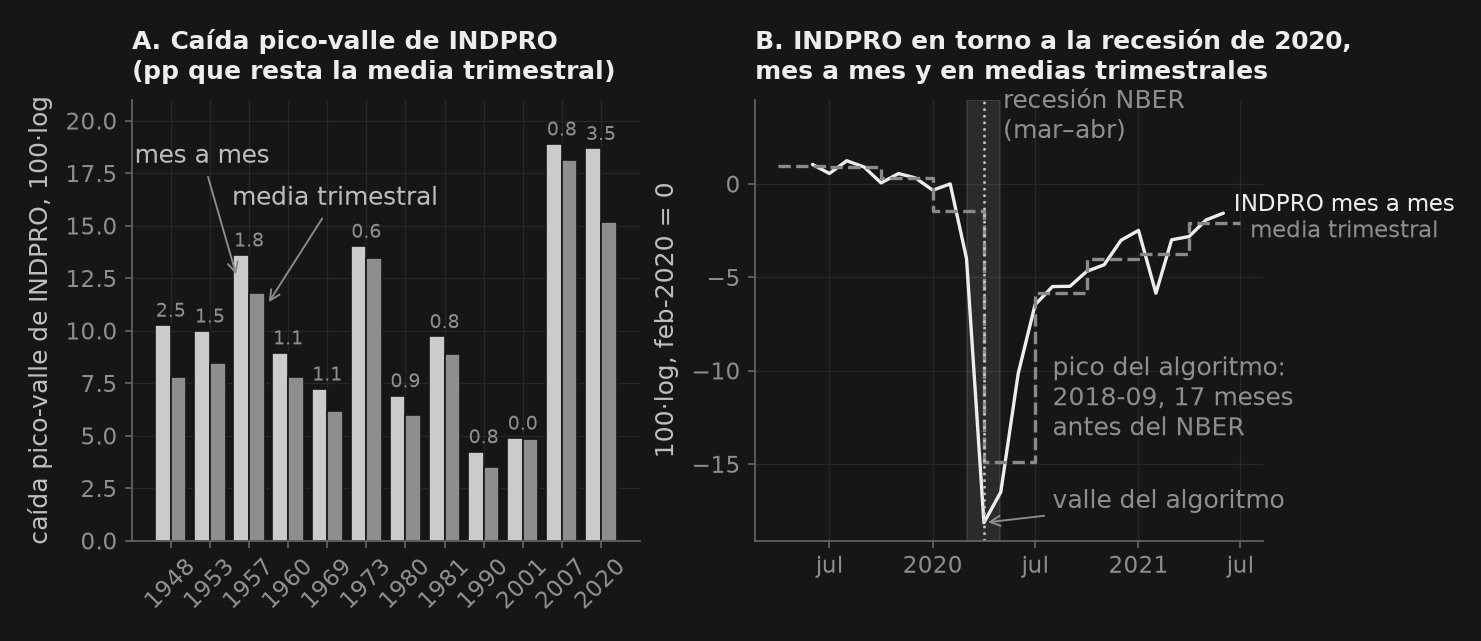

In [6]:
fig, (axL, axR) = _nbstyle.figura(1, 2)

# Izquierda: caída pico-valle de INDPRO, mes a mes y en medias trimestrales
xx = np.arange(len(P_IP))
axL.bar(xx - 0.2, P_IP["caída mensual"], 0.4, color=_nbstyle.BARRA_COLORES[0], edgecolor=_nbstyle.FONDO, lw=0.8)
axL.bar(xx + 0.2, P_IP["caída trimestral"], 0.4, color=_nbstyle.BARRA_COLORES[1], edgecolor=_nbstyle.FONDO, lw=0.8)
for i, v in enumerate(P_IP["el trimestre resta"]):
    axL.text(i, P_IP["caída mensual"].iloc[i] + 0.4, f"{v:.1f}", ha="center", color=_nbstyle.NOTA,
             fontsize=9)                       # doce cifras en cuatro pulgadas: densas como ticks
# el nombre de cada serie, con una flecha al par de 1957 desde el hueco de arriba
i57 = list(P_IP.index.str[:4]).index("1957")
axL.annotate("mes a mes", xy=(i57 - 0.3, 12.5), xytext=(i57 - 1.2, 18.0), ha="center",
             color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
axL.annotate("media trimestral", xy=(i57 + 0.45, 11.2), xytext=(i57 + 2.2, 16.0), ha="center",
             color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
axL.set_ylim(0, 21)
axL.set_xticks(xx); axL.set_xticklabels(P_IP.index.str[:4], rotation=45)
axL.set_ylabel("caída pico-valle de INDPRO, 100·log")
axL.set_title("A. Caída pico-valle de INDPRO\n(pp que resta la media trimestral)")

# Derecha: 2020 mes a mes, medias trimestrales, NBER y el valle del algoritmo
w = lip.loc["2019-06":"2021-06"]
wq = lipq.loc["2019-06":"2021-06"]
base = lip.loc["2020-02-01"]
axR.plot(w.index, w - base, color=cols[0], ls="-", lw=1.6, label="INDPRO mes a mes")
x_q = list(wq.index.to_period("Q").to_timestamp()) + [wq.index[-1]]
axR.step(x_q, list(wq - base) + [wq.iloc[-1] - base], where="post", color=cols[3], ls="--", lw=1.6, label="media trimestral")
axR.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-04-30"), color=_nbstyle.RECESION)
for f, k in RES["INDPRO mensual"]["_fechas"]:
    if pd.Timestamp("2019-06") <= f <= pd.Timestamp("2021-06"):
        axR.axvline(f, color=cols[1], ls=":", lw=1.2)
        axR.annotate(f"{'pico' if k == 1 else 'valle'} del algoritmo", xy=(f, (w - base).asof(f)),
                     xytext=(pd.Timestamp("2020-08-01"), -17.0), va="center", color=_nbstyle.NOTA,
                     arrowprops=_nbstyle.FLECHA)
axR.text(pd.Timestamp("2020-08-01"), -11.5, "pico del algoritmo:\n2018-09, 17 meses\nantes del NBER",
         va="center", color=_nbstyle.NOTA)
axR.set_ylim(top=4.5)
axR.text(pd.Timestamp("2020-05-05"), 2.0, "recesión NBER\n(mar–abr)", va="bottom", color=_nbstyle.NOTA)
xt = pd.date_range("2019-07-01", "2021-07-01", freq="6MS")       # el año en enero, "jul" en julio
axR.set_xticks(xt); axR.set_xticklabels([f"{d:%Y}" if d.month == 1 else "jul" for d in xt])
axR.set_ylabel("100·log, feb-2020 = 0")
axR.set_title("B. INDPRO en torno a la recesión de 2020,\nmes a mes y en medias trimestrales")
_nbstyle.etiquetar(axR, donde="fin")
plt.show()


## 2. El mercado de trabajo mes a mes: flujos, velocidad y emparejamiento

El desempleo es una piscina, no un pozo: cada mes sale de ella un cuarto de los desempleados y entra el 1.4% de los ocupados. T08_A §1 construye esas dos tasas —$f$ y $s$— con los flujos brutos de la CPS y la maquinaria de tres estados; aquí no la repetimos. Esta sección hace lo que el trimestre no deja hacer: comprobar que el desempleo *observado* es, casi mes a mes, el estado estacionario de esos flujos, medir a qué **velocidad** converge, y ver qué se pierde al agregar.

Tres resultados. Primero, $u^*_t = s_t/(s_t+f_t)$ sigue a UNRATE con correlación 0.975 y un error de 0.6 pp en 1990–2019, y la velocidad $s+f = 0.27$ al mes da una vida media de **2.2 meses**: la brecha entre el paro y su estado estacionario se cierra dentro del trimestre, que es exactamente por lo que un modelo trimestral no la ve. Segundo, la función de emparejamiento de JOLTS tiene elasticidad $1-\alpha = 0.69$ respecto a $v/u$, y el sesgo de agregación temporal en esa elasticidad es *cero* al segundo decimal — el sesgo está en otro sitio: en las probabilidades de transición, donde componer tres meses «a la ingenua» infla $s$ un 30% y $u^*$ en 1.3 pp. Tercero, México: la cuota informal no tiene un signo cíclico estable a frecuencia mensual; el ajuste de 2020 pasó por la participación.

**Una nota sobre los datos, porque decide la respuesta en dos de los tres bloques.** (1) `cps_transiciones_mensuales.csv` trae $f = p_{UE}$ y $s = p_{EU}$ desde 1990-02, salidas de `transitions_from_cps_flows`; $u^*$ de dos estados ignora los flujos por inactividad, así que esperamos un sesgo de nivel, no de forma. (2) `puremacro.labor_flows.transitions_from_shimer` es un *marcador de posición* — su $f$ es cero en el 60% de los meses — y aquí se sustituye por el estimador de Shimer (2005) a mano con los desempleados de menos de cinco semanas (`UEMPLT5`). (3) Las series de la ENOE son cuotas de un panel enlazado, **sin desestacionalizar** (la cuota informal sube 4.6 pp entre diciembre y febrero), con un salto de nivel de −4.2 pp en julio de 2006 que es un cambio de composición del panel y no un hecho económico, y con hueco en abril–junio de 2020: todo lo que se dice de México usa variaciones a doce meses desde 2007-07 y se dice con su tamaño de muestra al lado. Se leen de `enoe_stocks_monthly.csv`, la copia congelada fila a fila del parquet original de la ENOE (leer parquet exige `pyarrow`, que el iPad no tiene).

In [7]:
# (i) El estado estacionario mensual, su velocidad, y qué rompe la agregación.

def ols_nw(y, x, bw):
    # MCO de y sobre constante y x, con errores estándar Newey–West de ancho bw.
    X = add_constant(x)
    res = ols(y, X, cov_type="HAC", cov_kwds={"maxlags": bw})
    return np.asarray(res.params), np.asarray(res.bse), float(res.rsquared)


cps = pd.read_csv(DATOS / "cps_transiciones_mensuales.csv", parse_dates=["date"]).set_index("date")
m = pd.DataFrame({"f": cps["p_UE"], "s": cps["p_EU"], "u": _fred("UNRATE") / 100}).dropna().loc[:HASTA]
m["u_ss"] = m["s"] / (m["s"] + m["f"])


def ajuste(u, u_hat):
    return u.corr(u_hat), np.sqrt(((u - u_hat) ** 2).mean()) * 100, (u_hat - u).mean() * 100


corr_m, rmse_m, sesgo_m = ajuste(m["u"], m["u_ss"])
vel = (m["s"] + m["f"]).mean()
vida_media = np.log(0.5) / np.log(1 - vel)
print(f"Mensual {m.index[0]:%Y-%m}–{m.index[-1]:%Y-%m} (n={len(m)}): f = {m['f'].mean():.3f}, s = {m['s'].mean():.4f}")
print(f"  u* = s/(s+f) vs UNRATE: corr {corr_m:.3f}, RMSE {rmse_m:.2f} pp, sesgo {sesgo_m:+.2f} pp (dos estados: sin N)")
print(f"  velocidad s+f = {vel:.3f}/mes  ->  vida media {vida_media:.2f} meses")
assert corr_m > 0.95 and rmse_m < 1.0 and 1.5 < vida_media < 3.0

# Trimestral (a): promediar s y f dentro del trimestre no rompe nada — son suaves.
q = m.resample("QE").mean()
q["u_avg"] = q["s"] / (q["s"] + q["f"])
# Trimestral (b): tratar el trimestre como periodo y componer «a la ingenua»,
# S_Q = 1-(1-s)^3, como si nadie se separara y fuera recontratado en el mismo trimestre.
q["S_Q"], q["F_Q"] = 1 - (1 - q["s"]) ** 3, 1 - (1 - q["f"]) ** 3
q["u_naive"] = q["S_Q"] / (q["S_Q"] + q["F_Q"])
# Trimestral (c): la matriz correcta es P^3; su distribución estacionaria es la de P.
P3 = [np.linalg.matrix_power(np.array([[1 - si, si], [fi, 1 - fi]]), 3) for si, fi in zip(q["s"], q["f"])]
q["s3"], q["f3"] = [p[0, 1] for p in P3], [p[1, 0] for p in P3]
q["u_P3"] = q["s3"] / (q["s3"] + q["f3"])
for k, et in [("u_avg", "promedios trimestrales de s, f"), ("u_naive", "composición ingenua S_Q=1-(1-s)^3"), ("u_P3", "matriz P^3")]:
    c, r, b = ajuste(q["u"], q[k])
    print(f"  trimestral, {et:38s}: corr {c:.3f}, RMSE {r:.2f} pp, sesgo {b:+.2f} pp")
vel_q = (q["S_Q"] + q["F_Q"]).mean()
print(f"  s trimestral: ingenua {q['S_Q'].mean():.4f} vs P^3 {q['s3'].mean():.4f} ({q['S_Q'].mean() / q['s3'].mean() - 1:+.0%}); "
      f"f trimestral: {q['F_Q'].mean():.3f} vs {q['f3'].mean():.3f}")
print(f"  velocidad trimestral S_Q+F_Q = {vel_q:.2f}  ->  vida media {np.log(0.5) / np.log(1 - vel_q):.2f} trimestres: el ajuste termina dentro del periodo")
sesgo_naive = (q["u_naive"] - q["u"]).mean() * 100
print(f"  u* medio: mensual {m['u_ss'].mean():.2%}, P^3 {q['u_P3'].mean():.2%}, ingenuo {q['u_naive'].mean():.2%}, UNRATE {m['u'].mean():.2%}")
assert sesgo_naive > 0.5 and abs(q["u_P3"].mean() - q["u_avg"].mean()) < 1e-9

# Validación de transitions_from_shimer (puremacro) contra la CPS, y Shimer (2005) a mano.
pan = transitions_from_shimer(_fred("UNRATE").loc["1990":HASTA])
print(f"  TransitionPanel: {[a for a in dir(pan) if not a.startswith('_')]}")
pm = pan.monthly[["p_UE", "p_EU"]].join(m[["f", "s"]], how="inner")
print(f"  puremacro.transitions_from_shimer: corr(f) {pm['p_UE'].corr(pm['f']):.3f}, corr(s) {pm['p_EU'].corr(pm['s']):.3f}, "
      f"f = 0 en {(pm['p_UE'] == 0).mean():.0%} de los meses -> no sirve")
U, Us, E = _fred("UNEMPLOY"), _fred("UEMPLT5"), _fred("CE16OV")
f_sh = 1 - (U.shift(-1) - Us.shift(-1)) / U                       # Shimer (2005), ec. (1)
u2 = U / (U + E)
s_sh = (u2.shift(-1) - u2 * (1 - f_sh)) / (1 - u2)               # ley de movimiento de dos estados
sh = pd.DataFrame({"f_sh": f_sh, "s_sh": s_sh}).join(m[["f", "s"]], how="inner").dropna()
print(f"  Shimer a mano con UEMPLT5 (n={len(sh)}): corr(f) {sh['f_sh'].corr(sh['f']):.3f}, corr(s) {sh['s_sh'].corr(sh['s']):.3f}; "
      f"f_sh = {sh['f_sh'].mean():.3f} > p_UE porque cuenta salidas a N")
assert pm["p_UE"].corr(pm["f"]) < 0.3 and sh["f_sh"].corr(sh["f"]) > 0.8

Mensual 1990-02–2019-12 (n=359): f = 0.253, s = 0.0136
  u* = s/(s+f) vs UNRATE: corr 0.975, RMSE 0.62 pp, sesgo -0.51 pp (dos estados: sin N)
  velocidad s+f = 0.266/mes  ->  vida media 2.24 meses
  trimestral, promedios trimestrales de s, f        : corr 0.986, RMSE 0.58 pp, sesgo -0.51 pp
  trimestral, composición ingenua S_Q=1-(1-s)^3     : corr 0.981, RMSE 0.89 pp, sesgo +0.82 pp
  trimestral, matriz P^3                            : corr 0.986, RMSE 0.58 pp, sesgo -0.51 pp
  s trimestral: ingenua 0.0403 vs P^3 0.0311 (+30%); f trimestral: 0.579 vs 0.570
  velocidad trimestral S_Q+F_Q = 0.62  ->  vida media 0.72 trimestres: el ajuste termina dentro del periodo
  u* medio: mensual 5.33%, P^3 5.33%, ingenuo 6.67%, UNRATE 5.84%
  TransitionPanel: ['matrix_at', 'monthly', 'quarterly', 'states', 'stocks']
  puremacro.transitions_from_shimer: corr(f) 0.029, corr(s) 0.232, f = 0 en 60% de los meses -> no sirve
  Shimer a mano con UEMPLT5 (n=359): corr(f) 0.879, corr(s) 0.778; f_sh = 0.336

In [8]:
# (ii) La función de emparejamiento de JOLTS: log(H/U) = log mu + (1-alpha) log(V/U).
j = pd.DataFrame({"H": _fred("JTSHIL"), "V": _fred("JTSJOL"), "U": U}).dropna()
jq = j.resample("QE").mean()
res = {}
for et, d, bw in [("mensual", j, 12), ("trimestral", jq, 4)]:
    for nombre, sub in [("2000-12–2019-12", d.loc[:HASTA]), ("completa       ", d)]:
        y, x = np.log(sub["H"] / sub["U"]).values, np.log(sub["V"] / sub["U"]).values
        b, se, r2 = ols_nw(y, x, bw)
        res[(et, nombre.strip())] = b
        print(f"  {et:10s} {nombre} (n={len(sub):3d}, hasta {sub.index[-1]:%Y-%m}): 1-α = {b[1]:.3f} (NW {se[1]:.3f}), "
              f"α = {1 - b[1]:.3f}, log μ = {b[0]:.3f}, R² = {r2:.3f}")
alpha_m, alpha_q = 1 - res[("mensual", "2000-12–2019-12")][1], 1 - res[("trimestral", "2000-12–2019-12")][1]
print(f"  sesgo de agregación temporal en α: {alpha_q - alpha_m:+.3f}")
assert 0.25 < alpha_m < 0.35 and abs(alpha_q - alpha_m) < 0.02
# H son todas las contrataciones de JOLTS (también desde el empleo y la inactividad), no sólo las de desempleados.
hu = (j["H"] / j["U"]).loc[:HASTA].mean()
f_j = m["f"].loc["2000-12":HASTA].mean()
print(f"  H/U medio 2000-12–2019-12: {hu:.2f} frente a f = p_UE = {f_j:.3f} ({hu / f_j:.1f} veces): "
      "H son todas las contrataciones, no sólo las de desempleados")
assert hu > 1.5 * f_j
# El desplazamiento post-2020: contrataciones por desempleado frente a la función pre-2020.
b0, b1 = res[("mensual", "2000-12–2019-12")]
resid = np.log(j["H"] / j["U"]) - (b0 + b1 * np.log(j["V"] / j["U"]))
for a, b_ in [("2021-01", "2022-12"), ("2023-01", "2024-12")]:
    print(f"  residuo medio {a}..{b_}: {resid.loc[a:b_].mean() * 100:+.1f}% (eficiencia de emparejamiento vs 2000–2019)")
# Beveridge mensual 2019-12–2024-12: el episodio es el objeto, no un segundo momento.
theta = (j["V"] / j["U"])
bev = pd.DataFrame({"u": _fred("UNRATE"), "v": 100 * j["V"] / (E + j["V"])}).dropna().loc["2019-12":"2024-12"]
area = 0.5 * np.sum(bev["u"].values * np.roll(bev["v"].values, -1) - np.roll(bev["u"].values, -1) * bev["v"].values)
print(f"  θ = V/U: media 2000–2019 {theta.loc[:HASTA].mean():.2f}; máximo {theta.max():.2f} en {theta.idxmax():%Y-%m} "
      f"({theta.max() / theta.loc[:HASTA].mean():.1f} veces la media); mínimo {theta.min():.2f} en {theta.idxmin():%Y-%m}")
print(f"  Beveridge 2019-12–2024-12 (n={len(bev)}): u máx {bev['u'].max():.1f}% ({bev['u'].idxmax():%Y-%m}), v máx {bev['v'].max():.2f}% ({bev['v'].idxmax():%Y-%m}); "
      f"área firmada {area:+.1f} > 0: bucle antihorario")
assert theta.idxmax().strftime("%Y-%m") == "2022-03" and theta.max() > 1.9 and area > 0

  mensual    2000-12–2019-12 (n=229, hasta 2019-12): 1-α = 0.694 (NW 0.037), α = 0.306, log μ = -0.081, R² = 0.909
  mensual    completa        (n=305, hasta 2026-05): 1-α = 0.592 (NW 0.037), α = 0.408, log μ = -0.195, R² = 0.877
  trimestral 2000-12–2019-12 (n= 77, hasta 2019-12): 1-α = 0.698 (NW 0.040), α = 0.302, log μ = -0.078, R² = 0.914
  trimestral completa        (n=103, hasta 2026-06): 1-α = 0.591 (NW 0.039), α = 0.409, log μ = -0.195, R² = 0.883
  sesgo de agregación temporal en α: -0.004
  H/U medio 2000-12–2019-12: 0.60 frente a f = p_UE = 0.238 (2.5 veces): H son todas las contrataciones, no sólo las de desempleados
  residuo medio 2021-01..2022-12: -30.1% (eficiencia de emparejamiento vs 2000–2019)
  residuo medio 2023-01..2024-12: -24.0% (eficiencia de emparejamiento vs 2000–2019)
  θ = V/U: media 2000–2019 0.56; máximo 2.04 en 2022-03 (3.6 veces la media); mínimo 0.15 en 2009-07
  Beveridge 2019-12–2024-12 (n=61): u máx 14.8% (2020-04), v máx 7.21% (2022-03); área firma

In [9]:
# (iii) México mes a mes: cuotas de la ENOE (nunca niveles) contra la producción industrial.
# enoe_stocks_monthly.csv es la copia congelada, fila a fila, de enoe_stocks_monthly.parquet:
# leer parquet exige pyarrow, que el iPad no tiene.
e = pd.read_csv(DATOS / "enoe_stocks_monthly.csv", parse_dates=["ref_date"]).set_index("ref_date")
print(f"enoe_stocks_monthly.csv: copia congelada del parquet de la ENOE, {len(e)} meses x {list(e.columns)}")
mx = pd.DataFrame({"inf": e["I"] / (e["F"] + e["I"]), "u": e["U"] / (e["F"] + e["I"] + e["U"]),
                   "part": (e["F"] + e["I"] + e["U"]) / e.sum(axis=1)}).asfreq("MS")   # deja NaN abr–jun 2020
ip = pd.read_csv(DATOS / "oecd_mei_mex_log_ip.csv", parse_dates=["date"]).set_index("date")["log_ip_x100"].asfreq("MS")
salto = (mx["inf"].loc["2006-07"].iloc[0] - mx["inf"].loc["2006-06"].iloc[0]) * 100
DESDE = "2007-07"   # primer Δ12 que no cruza el salto de nivel del panel enlazado en 2006-07
x = mx["inf"].loc[DESDE:HASTA] * 100
est = (x - x.rolling(13, center=True).mean()).groupby(x.index.month).mean()
print(f"ENOE {mx.index[0]:%Y-%m}–{mx.index[-1]:%Y-%m}: cuota informal media {mx['inf'].mean():.1%}; estacionalidad {est.max() - est.min():.1f} pp "
      f"(máx en mes {est.idxmax()}, mín en mes {est.idxmin()}); sd de la variación mensual {x.diff().std():.2f} pp -> ruido")
print(f"  salto de nivel del panel enlazado en 2006-07: {salto:+.1f} pp en un mes -> la muestra empieza en {DESDE}")
d = pd.DataFrame({"inf": mx["inf"].diff(12) * 100, "u": mx["u"].diff(12) * 100, "part": mx["part"].diff(12) * 100, "g": ip.diff(12)}).dropna()
for a, b_ in [(DESDE, HASTA), ("2011-01", HASTA), ("2020-01", "2024-12")]:
    sub = d.loc[a:b_]
    print(f"  Δ12 {a}..{b_[:7]} (n={len(sub):3d}): corr(informal, IP) {sub['inf'].corr(sub['g']):+.3f}, "
          f"corr(u, IP) {sub['u'].corr(sub['g']):+.3f}, corr(participación, IP) {sub['part'].corr(sub['g']):+.3f}")
pre = d.loc[DESDE:HASTA]
b, se, _ = ols_nw(pre["inf"].values, pre["g"].values, 12)
print(f"  β(informal sobre IP, {DESDE[:4]}–2019) = {b[1]:+.3f} pp por 1% (NW se {se[1]:.3f}, t = {b[1] / se[1]:.1f})")
for t in ["2009-06", "2020-07", "2021-08"]:
    r = d.loc[t].iloc[0]
    print(f"  {t}: IP {r['g']:+.1f}%, informal {r['inf']:+.2f} pp, desempleo {r['u']:+.2f} pp, participación {r['part']:+.2f} pp")
c_pre, c_post = pre["inf"].corr(pre["g"]), d.loc["2011-01":HASTA, "inf"].corr(d.loc["2011-01":HASTA, "g"])
assert abs(c_pre) < 0.3 and np.sign(c_pre) != np.sign(c_post)          # signo inestable: no hay hecho
assert pre["u"].corr(pre["g"]) < -0.5 and d.loc["2020-07", "part"].iloc[0] < -4   # estos dos sí

enoe_stocks_monthly.csv: copia congelada del parquet de la ENOE, 234 meses x ['F', 'I', 'U', 'N']
ENOE 2005-04–2024-12: cuota informal media 61.7%; estacionalidad 4.6 pp (máx en mes 2, mín en mes 12); sd de la variación mensual 2.13 pp -> ruido
  salto de nivel del panel enlazado en 2006-07: -4.2 pp en un mes -> la muestra empieza en 2007-07
  Δ12 2007-07..2019-12 (n=150): corr(informal, IP) -0.095, corr(u, IP) -0.674, corr(participación, IP) +0.213
  Δ12 2011-01..2019-12 (n=108): corr(informal, IP) +0.097, corr(u, IP) -0.286, corr(participación, IP) +0.128
  Δ12 2020-01..2024-12 (n= 54): corr(informal, IP) +0.285, corr(u, IP) -0.717, corr(participación, IP) +0.697
  β(informal sobre IP, 2007–2019) = -0.038 pp por 1% (NW se 0.051, t = -0.7)
  2009-06: IP -12.5%, informal -1.92 pp, desempleo +1.53 pp, participación -0.38 pp
  2020-07: IP -10.9%, informal -1.74 pp, desempleo +1.25 pp, participación -4.72 pp
  2021-08: IP +3.7%, informal +0.61 pp, desempleo -0.49 pp, participación +3.92 p

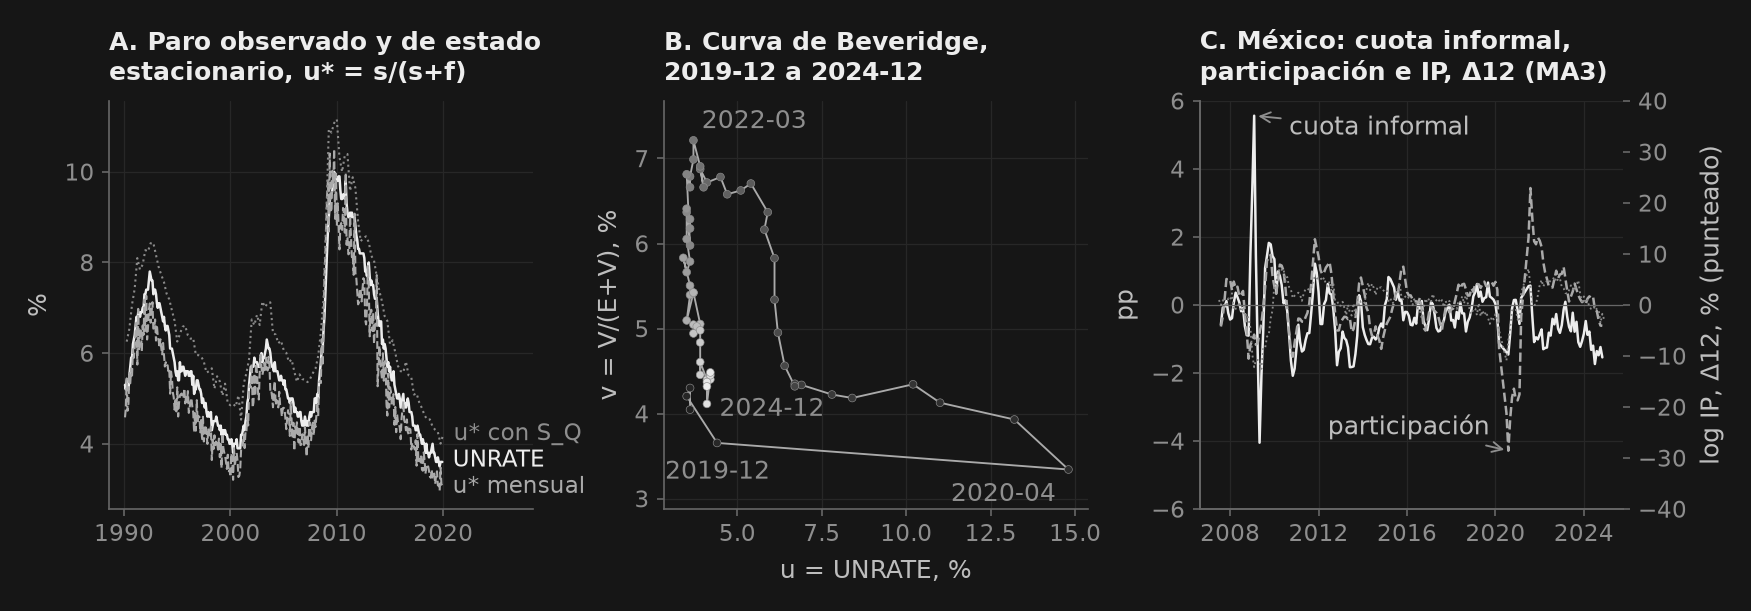

In [10]:
fig, axs = _nbstyle.figura(1, 3)
ax = axs[0]
ax.plot(m.index, m["u"] * 100, color=cols[0], lw=1.2, ls="-", label="UNRATE")
ax.plot(m.index, m["u_ss"] * 100, color=cols[2], lw=1.0, ls="--", label="u* mensual")
ax.plot(q.index, q["u_naive"] * 100, color=cols[3], lw=1.0, ls=":", label="u* con S_Q")
ax.set_ylabel("%")
ax.set_xlim(right=pd.Timestamp("2028-06"))          # sitio para los nombres tras el último dato
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.set_title("A. Paro observado y de estado\nestacionario, u* = s/(s+f)")
ax = axs[1]
ax.plot(bev["u"], bev["v"], color=cols[2], lw=0.9, ls="-")
ax.scatter(bev["u"], bev["v"], c=np.linspace(0.15, 1, len(bev)), cmap="mav_seq", s=14, zorder=3, edgecolor=_nbstyle.NOTA, lw=0.3)
ax.margins(y=0.12)                                  # sitio para el nombre del punto más alto
for t, dx_, dy_, ha_, va_ in (("2019-12", -12, -24, "left", "top"), ("2020-04", -6, -6, "right", "top"),
                              ("2022-03", 4, 3, "left", "bottom"), ("2024-12", 6, -5, "left", "top")):
    r = bev.loc[t].iloc[0]
    ax.annotate(t, (r["u"], r["v"]), xytext=(dx_, dy_), textcoords="offset points", ha=ha_, va=va_,
                color=_nbstyle.NOTA)
ax.set_xlabel("u = UNRATE, %"); ax.set_ylabel("v = V/(E+V), %")
ax.set_title("B. Curva de Beveridge,\n2019-12 a 2024-12")
ax = axs[2]
dd = d.loc[DESDE:"2024-12"]
inf3 = dd["inf"].rolling(3, center=True).mean()
part3 = dd["part"].rolling(3, center=True).mean()
ax.plot(dd.index, inf3, color=cols[0], lw=1.2, ls="-")
ax.plot(dd.index, part3, color=cols[2], lw=1.2, ls="--")
ax.axhline(0, color=_nbstyle.SPINE, lw=0.6); ax.set_ylabel("pp")
ax.set_ylim(-6, 6)                                  # el cero de las dos escalas a la misma altura
ax2 = ax.twinx(); ax2.plot(dd.index, dd["g"], color=cols[3], lw=0.9, ls=":"); ax2.grid(False)
ax2.set_ylabel("log IP, Δ12, % (punteado)"); ax2.set_ylim(-40, 40)
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.set_title("C. México: cuota informal,\nparticipación e IP, Δ12 (MA3)")
# cada serie en pp, nombrada con una flecha a su rasgo más visible
ax.annotate("cuota informal", xy=(inf3.idxmax(), inf3.max()), xytext=(pd.Timestamp("2010-09-01"), 5.2),
            va="center", color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
ax.annotate("participación", xy=(part3.idxmin(), part3.min()), xytext=(pd.Timestamp("2012-06-01"), -3.6),
            va="center", color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
_nbstyle.etiquetar(axs[0], donde="fin", fuera=True)
plt.show()


**Lo que dicen los números.** El paro observado *es* su estado estacionario a frecuencia mensual: corr 0.975, RMSE 0.62 pp, y el sesgo de −0.5 pp es el precio de dos estados (los flujos por inactividad, que T08_A sí lleva). La velocidad $s+f = 0.266$ al mes cierra la mitad de cualquier brecha en 2.2 meses. Promediar $s$ y $f$ por trimestre no daña nada (RMSE 0.58 pp): son series suaves. Lo que daña es tratar el trimestre como *periodo* y componer $S_Q = 1-(1-s)^3$: eso cuenta como separado a quien ya fue recontratado dentro del trimestre, infla $s$ un 30% (0.040 frente al 0.031 de $P^3$) y sube $u^*$ 1.3 pp, del 5.33% al 6.67% (de −0.5 pp por debajo de UNRATE a +0.8 por encima) — mientras que $P^3$ devuelve exactamente el 5.33% mensual, porque la distribución estacionaria de $P^3$ es la de $P$. Y con $S_Q+F_Q = 0.62$ la vida media es 0.7 trimestres: el ajuste termina dentro del periodo, así que datos trimestrales no identifican la velocidad. Ese es el sesgo de agregación temporal de Shimer (2012), en dos números.

En JOLTS, $1-\alpha = 0.69$ (NW 0.04) en 2000–2019 y $\alpha$ cambia 0.004 al pasar a trimestres: el sesgo de agregación **no** está en la elasticidad, y lo decimos porque lo buscamos. Una precisión: $H$ son *todas* las contrataciones de JOLTS —también las de quien cambia de empleo o viene de la inactividad—, no sólo las de desempleados, así que $H/U$ (0.60 de media en 2000–2019) es 2.5 veces la $f = p_{UE}$ del bloque (i) en el mismo periodo (0.24); la elasticidad es la de Petrongolo y Pissarides con contrataciones totales, no la de la tasa de salida del paro. Sí está en el nivel: con la función pre-2020, las contrataciones por desempleado de 2021–22 quedan 30% por debajo, y las de 2023–24, 24% — el bucle antihorario de Beveridge (área firmada +12.6) es la misma caída de eficiencia vista en el plano $(u,v)$, con $\theta$ en 2.04 en marzo de 2022, 3.6 veces su media de 2000–2019. En México, con n=150 meses y variaciones a doce meses, la cuota informal correlaciona −0.095 con la producción industrial en 2007–2019 (t = −0.7) y +0.10 en 2011–2019: **no hay un signo**, y queda como pregunta abierta con su test negativo — en las dos recesiones la cuota informal *cae* a doce meses (−1.9 pp en junio de 2009, −1.7 pp en julio de 2020), que es lo contrario de la informalidad como colchón, pero está dentro del ruido de muestreo. Lo que sí es un hecho mensual son los otros dos márgenes: el desempleo (corr −0.67) y la participación, que en julio de 2020 cayó 4.7 pp a doce meses contra 1.7 pp de la cuota informal. El ejercicio 4 pide desestacionalizar la cuota con `puremacro.sa` y comprobar que el veredicto no cambia.

## 3. De lo diario a lo mensual: los choques de incertidumbre, y lo que el trimestre esconde de ellos

Bloom (2009) hizo una cosa sencilla con una serie diaria: promedió el VIX por mes, le quitó la tendencia y llamó «choque de incertidumbre» a cada mes que quedaba más de 1.65 desviaciones estándar por encima. Diecisiete fechas entre 1962 y 2007, y detrás de cada una un nombre: la crisis de los misiles, el 11-S, LTCM. Después mostró que la producción industrial cae cerca de 1% en los meses siguientes y **rebota por encima de cero** hacia el final del primer año — el *overshoot*, la firma de una economía que pospuso decisiones y luego las recuperó de golpe.

Aquí repetimos las tres piezas con datos que no existían cuando él escribió —VIX diario de 1990 a 2026, producción industrial y empleo privado mensuales— y añadimos la pregunta que da nombre a esta lección: ¿qué queda de todo esto si sólo se mira el trimestre? La respuesta tiene dos partes y una de ellas no es la que esperábamos.

**Una nota sobre los datos, porque decide la respuesta.** `VIXCLS` empieza en enero de 1990: la CBOE recalculó su índice de 2003 hacia atrás hasta ahí, pero no antes. Los diez primeros eventos de Bloom (1962–1987) salen de la volatilidad realizada del S&P 500 y del VXO, series que no están en `data_curso`, así que no los podemos reproducir; sí podemos comprobar si su regla recupera los seis que fechó a partir de 1990 y qué añade hasta 2026. Usamos el **logaritmo** del VIX mensual medio, no el nivel como Bloom: en niveles la sd la fija 2008 (VIX medio de 63 en noviembre) y el umbral sube hasta dejar fuera episodios que en su propia escala son enormes. Y el filtro HP se aplica a la serie mensual (439 observaciones): `hp_filter` resuelve un sistema denso $n\times n$ y no hay razón para pedirle 9 234 días. La tendencia HP y la desviación típica que fijan el umbral (0.246) se calculan sobre 1990–2026 entero, 2008 y marzo de 2020 incluidos, porque el listado de episodios hasta 2026 es el objeto y Bloom hizo lo mismo con su muestra; es un segundo momento posterior a 2020 y se declara. La proyección local de §3.1, que sí es un momento del ciclo, se corta en 2019.

In [11]:
vix_d = _fred("VIXCLS").dropna()
vix_m = vix_d.resample("MS").agg(["mean", "max", "count"])
vix_m = vix_m[vix_m["count"] >= 15]                       # sólo meses completos
c_vix, _ = hp_filter(np.log(vix_m["mean"]), lamb=129_600)  # λ mensual de Bloom
z_vix = c_vix / c_vix.std()
UMBRAL = 1.65
arriba = z_vix > UMBRAL

# Un episodio = meses consecutivos por encima del umbral; lo fechamos en su pico.
episodios = []
grupo = (arriba != arriba.shift()).cumsum()
for _, g in z_vix[arriba].groupby(grupo[arriba]):
    pico = g.idxmax()
    episodios.append({"mes": pico.strftime("%Y-%m"), "meses_arriba": len(g),
                      "VIX_medio": vix_m.loc[pico, "mean"],
                      "VIX_max": vix_m.loc[pico, "max"], "z": z_vix.loc[pico]})
episodios = pd.DataFrame(episodios)

print(f"VIX diario {vix_d.index[0]:%Y-%m-%d} a {vix_d.index[-1]:%Y-%m-%d}: "
      f"{len(vix_d)} días -> {len(vix_m)} meses. Correlación entre la media y el máximo "
      f"diario del mes: {vix_m['mean'].corr(vix_m['max']):.3f}.")
print(f"sd del log VIX sin tendencia = {c_vix.std():.3f}; el umbral de 1.65 sd son "
      f"{100 * (np.exp(UMBRAL * c_vix.std()) - 1):.0f}% por encima de la tendencia.")
print(f"\n{len(episodios)} episodios de incertidumbre, 1990–2026, fechados en su pico:")
print(episodios.round(2).to_string(index=False))

# Los seis eventos que Bloom (2009, tabla A.1) fecha desde 1990: Guerra del Golfo I,
# crisis asiática, Rusia/LTCM, 11-S, WorldCom/Enron, Guerra del Golfo II; el
# decimoséptimo es el credit crunch, que su muestra (hasta junio de 2008) sólo ve empezar.
BLOOM_90 = ["1990-10", "1997-11", "1998-09", "2001-09", "2002-09", "2003-02"]
mes_ep = pd.PeriodIndex(episodios["mes"], freq="M")
recup = [b for b in BLOOM_90 if any(abs((e - pd.Period(b, "M")).n) <= 1 for e in mes_ep)]
credit = any(pd.Period("2007-07", "M") <= e <= pd.Period("2008-12", "M") for e in mes_ep)
nuevos = episodios.loc[mes_ep > pd.Period("2008-06", "M"), "mes"]
print(f"\nDe los 6 de Bloom desde 1990 recuperamos {len(recup)} (±1 mes): {', '.join(recup)}; "
      f"credit crunch 2007–08: {'sí' if credit else 'no'}.")
print(f"Episodios posteriores a su muestra: {len(nuevos)} -> {', '.join(nuevos)}.")
n_1mes = int((episodios["meses_arriba"] == 1).sum())
print(f"Episodios de un solo mes por encima del umbral: {n_1mes} de {len(episodios)}.")
assert len(recup) == 6 and credit
assert 12 <= len(episodios) <= 16 and n_1mes >= 5

VIX diario 1990-01-02 a 2026-07-21: 9234 días -> 439 meses. Correlación entre la media y el máximo diario del mes: 0.963.
sd del log VIX sin tendencia = 0.246; el umbral de 1.65 sd son 50% por encima de la tendencia.

14 episodios de incertidumbre, 1990–2026, fechados en su pico:
    mes  meses_arriba  VIX_medio  VIX_max    z
1990-10             1      29.63    33.98 1.75
1997-11             1      32.21    37.84 1.86
1998-09             2      38.20    45.29 2.19
2001-09             1      35.07    43.74 1.66
2002-09             4      37.65    40.65 2.28
2003-02             2      32.22    34.33 1.83
2008-11             7      62.67    80.86 4.28
2011-09             4      36.53    42.96 2.39
2015-09             1      24.38    31.40 2.05
2016-01             2      23.72    27.59 1.96
2020-03             4      57.74    82.69 4.58
2020-10             1      29.44    40.28 1.67
2022-10             1      30.01    33.63 1.69
2025-04             1      31.97    52.33 2.34

De los 6 de B

**La regla de Bloom no envejece.** Con log VIX y λ = 129 600 recupera **los seis** eventos que él fechó desde 1990, mes por mes —octubre de 1990, noviembre de 1997, septiembre de 1998, septiembre de 2001, septiembre de 2002, febrero de 2003— y pone el *credit crunch* en noviembre de 2008, el pico de un episodio de siete meses seguidos por encima del umbral (su muestra acababa en junio de 2008 y lo vio empezar, no culminar). Lo que añade después son ocho fechas que cualquiera reconoce: septiembre de 2011 (cuatro meses seguidos por encima: la rebaja de la deuda de EE. UU. y el euro), septiembre de 2015 y enero de 2016 (China), marzo de 2020 (VIX máximo diario de 82.7, el récord de la serie), octubre de 2020, octubre de 2022 y abril de 2025 (los aranceles: VIX máximo de 52 en un mes cuya media es 32). Catorce episodios en 36 años.

Dos detalles del cuadro. La media y el máximo diario del mes se mueven casi juntos (correlación 0.963): para *fechar* un episodio, la agregación a mensual no pierde nada, y la marca «máximo dentro del mes» sirve sobre todo para ver qué tan concentrado fue el pánico (abril de 2025 es el caso extremo: el máximo dobla la media). Y **siete de los catorce episodios duran un solo mes**, y otros tres, dos. Apúntalo, porque §3.2 vive de ese número.

**3.1 La proyección local mensual.** Regresamos $y_{t+h}-y_{t-1}$ sobre el indicador de choque (1 en el mes pico de cada episodio, 0 en el resto), seis rezagos del indicador y del resultado, y la tasa de fondos federales y la inflación interanual **rezagadas un mes** — el orden recursivo de Bloom, en el que la política reacciona al VIX dentro del mes y no al revés; `lp_hac` mete los controles contemporáneos si se los das sin rezagar, así que se los damos rezagados. La mecánica del estimador y de sus bandas HAC está en T05_B §2; aquí sólo la usamos. Muestra 1990–2019: 2020 tiene el VIX más alto de la serie y no es un ciclo económico.

In [12]:
ip = (100 * np.log(_fred("INDPRO"))).rename("ip")
emp = (100 * np.log(_fred("USPRIV"))).rename("emp")
u = _fred("UNRATE").rename("u")
ff = _fred("FEDFUNDS").rename("ff")
infl = (100 * np.log(_fred("CPIAUCSL")).diff(12)).rename("infl")   # interanual
m = pd.concat([ip, emp, u, ff, infl], axis=1).loc["1990-01-01":HASTA].copy()
m["choque"] = m.index.isin(pd.to_datetime(episodios["mes"])).astype(float)
m["ff_1"], m["infl_1"] = m["ff"].shift(1), m["infl"].shift(1)    # orden recursivo
m = m.dropna()
CTL, NL_M, H_M = ["ff_1", "infl_1"], 6, range(0, 37)
NOMBRES = [("ip", "producción industrial, %", 1.0), ("emp", "empleo privado, %", 1.0),
           ("u", "tasa de paro, pp", -1.0)]


def perfil(lp, s=1.0):
    """Valle (mínimo de s·β) con el extremo de su banda que mira a cero, y el
    rebote máximo posterior con el suyo. s = -1 para el paro, que sube."""
    i_v = (s * lp["beta"]).idxmin()
    i_r = (s * lp.loc[i_v:, "beta"]).idxmax()
    return dict(h_valle=int(lp.loc[i_v, "h"]), valle=lp.loc[i_v, "beta"],
                valle_b=lp.loc[i_v, "hi" if s > 0 else "lo"],
                h_rebote=int(lp.loc[i_r, "h"]), rebote=lp.loc[i_r, "beta"],
                rebote_b=lp.loc[i_r, "lo" if s > 0 else "hi"])


def resumen(lps, unidad):
    for y, nom, s in NOMBRES:
        p = perfil(lps[y], s)
        print(f"  {nom:26s} valle {p['valle']:+.2f} en h={p['h_valle']:2d}{unidad} "
              f"(banda hasta {p['valle_b']:+.2f}); rebote {p['rebote']:+.2f} en "
              f"h={p['h_rebote']:2d}{unidad} (banda hasta {p['rebote_b']:+.2f})")


lp_m = {y: lp_hac(m, y=y, x="choque", horizons=H_M, n_lags=NL_M, controls=CTL)
        for y, _, _ in NOMBRES}
print(f"PL mensual {m.index[0]:%Y-%m}–{m.index[-1]:%Y-%m}: {len(m)} meses, "
      f"{int(m['choque'].sum())} choques, {NL_M} rezagos, bandas HAC al 90%.")
resumen(lp_m, "m")
print("IP mes a mes, h=0..24:", " ".join(f"{b:+.1f}" for b in lp_m["ip"]["beta"].values[:25]))
p_ip = perfil(lp_m["ip"])
print(f"La IP vuelve a cero en el mes "
      f"{int(lp_m['ip'].loc[(lp_m['ip']['h'] > p_ip['h_valle']) & (lp_m['ip']['beta'] > 0), 'h'].min())}.")
lp_pre = lp_hac(m.loc[:"2007-12-31"], y="ip", x="choque", horizons=H_M, n_lags=NL_M, controls=CTL)
p_pre = perfil(lp_pre)
print(f"Sólo 1990–2007 ({int(m.loc[:'2007-12-31', 'choque'].sum())} choques): valle "
      f"{p_pre['valle']:+.2f} en h={p_pre['h_valle']}, rebote {p_pre['rebote']:+.2f} "
      f"(banda hasta {p_pre['rebote_b']:+.2f}).")
assert p_ip["valle_b"] < 0 and 3 <= p_ip["h_valle"] <= 9     # la caída es significativa
assert p_ip["rebote"] > 0 and p_ip["rebote_b"] < 0            # el rebote, no

PL mensual 1990-02–2019-12: 359 meses, 10 choques, 6 rezagos, bandas HAC al 90%.
  producción industrial, %   valle -1.62 en h= 6m (banda hasta -0.38); rebote +1.23 en h=30m (banda hasta -0.75)
  empleo privado, %          valle -0.46 en h= 7m (banda hasta -0.15); rebote +0.88 en h=36m (banda hasta +0.08)
  tasa de paro, pp           valle +0.33 en h= 7m (banda hasta +0.08); rebote -0.66 en h=36m (banda hasta +0.02)
IP mes a mes, h=0..24: -0.2 -0.7 -1.3 -1.5 -1.5 -1.5 -1.6 -1.5 -1.3 -0.9 -0.7 -0.6 -0.6 -0.6 -0.3 -0.1 -0.1 +0.1 +0.3 +0.2 +0.4 +0.5 +0.3 +0.4 +0.7
La IP vuelve a cero en el mes 17.
Sólo 1990–2007 (6 choques): valle -1.57 en h=8, rebote +0.34 (banda hasta -2.62).


**La caída está; el rebote, no.** Tras un choque la producción industrial cae hasta **−1.6% en el mes 6** (banda del 90% hasta −0.38), el empleo privado −0.46% en el mes 7, y el paro sube 0.33 puntos en el mismo mes 7. La IP cruza de nuevo el cero en el mes 17 y el punto estimado sigue subiendo hasta +1.2% en el mes 30 — la forma del *overshoot* de Bloom, pero su banda llega a −0.75: con diez eventos, no se distingue de cero. Y en 1990–2007, los seis eventos que él tenía, el rebote es +0.3 con una banda que baja a −2.6. **El rebote queda como pregunta abierta con su test negativo.** Sí sobrevive el orden de magnitud de la caída (Bloom: cerca de 1% hacia el cuarto mes) y su forma: nada el primer mes, todo entre el segundo y el sexto.

**3.2 Y ahora sólo el trimestre.** Promediamos todo a trimestral —IP, empleo, paro, tasa de fondos, inflación— y volvemos a estimar con horizontes de 0 a 12 trimestres y dos rezagos. El choque, por ahora, sigue fechado con los datos mensuales: un trimestre lleva un 1 si contiene un mes pico. Eso aísla la primera pregunta: ¿pierde algo la *respuesta* por medirse en promedios trimestrales?

In [13]:
q = m[["ip", "emp", "u", "ff", "infl"]].resample("QS").mean()
q["choque"] = m["choque"].resample("QS").max()             # el mes pico, visto desde el trimestre
q["ff_1"], q["infl_1"] = q["ff"].shift(1), q["infl"].shift(1)
q = q.dropna()
H_Q = range(0, 13)
lp_q = {y: lp_hac(q, y=y, x="choque", horizons=H_Q, n_lags=2, controls=CTL)
        for y, _, _ in NOMBRES}
print(f"PL trimestral {q.index[0].to_period('Q')}–{q.index[-1].to_period('Q')}: "
      f"{len(q)} trimestres, {int(q['choque'].sum())} con choque, 2 rezagos.")
resumen(lp_q, "T")
pq_ip = perfil(lp_q["ip"])
bm = lp_m["ip"].set_index("h")["beta"]
prom3 = np.array([bm.loc[3 * h:3 * h + 2].mean() for h in range(5)])
print("promedio trimestral de la PL mensual, h=0..4T:", " ".join(f"{b:+.2f}" for b in prom3))
print("PL trimestral directa,               h=0..4T:",
      " ".join(f"{b:+.2f}" for b in lp_q["ip"]["beta"].values[:5]))
print(f"se en el valle: mensual {lp_m['ip'].loc[p_ip['h_valle'], 'se']:.2f}, "
      f"trimestral {lp_q['ip'].loc[pq_ip['h_valle'], 'se']:.2f}.")
assert abs(pq_ip["valle"] - p_ip["valle"]) < 0.25 and pq_ip["valle_b"] < 0
assert np.max(np.abs(prom3 - lp_q["ip"]["beta"].values[:5])) < 0.25

# Segunda pregunta: ¿y si el choque también se fecha con datos trimestrales?
z_q = (lambda c: c / c.std())(hp_filter(np.log(vix_m["mean"].resample("QS").mean()), lamb=1600)[0])
arr_q = z_q > UMBRAL
picos_q = [g.idxmax() for _, g in z_q[arr_q].groupby((arr_q != arr_q.shift()).cumsum()[arr_q])]
q["choque_q"] = q.index.isin(picos_q).astype(float)
lp_qq = lp_hac(q, y="ip", x="choque_q", horizons=H_Q, n_lags=2, controls=CTL)
pqq = perfil(lp_qq)
_qsup = {t.to_period("Q") for t in z_q.index[arr_q]}
perdidos = [e for e in episodios["mes"] if pd.Period(e, "M").asfreq("Q") not in _qsup]
print(f"\nIndicador construido con el VIX trimestral (HP λ=1600): {int(arr_q.sum())} trimestres "
      f"por encima del umbral, {len(picos_q)} picos ({', '.join(str(t.to_period('Q')) for t in picos_q)}), "
      f"{int(q['choque_q'].sum())} en la muestra de la PL.")
print(f"Picos mensuales cuyo trimestre no supera el umbral: {len(perdidos)} de {len(episodios)} -> "
      f"{', '.join(perdidos)}.")
print(f"PL de la IP sobre ese indicador: valle {pqq['valle']:+.2f} en h={pqq['h_valle']}T "
      f"(banda hasta {pqq['valle_b']:+.2f}); rebote {pqq['rebote']:+.2f} en h={pqq['h_rebote']}T "
      f"(banda hasta {pqq['rebote_b']:+.2f}).")
assert len(perdidos) >= 7 and pqq["valle_b"] > 0

PL trimestral 1990Q2–2019Q4: 119 trimestres, 10 con choque, 2 rezagos.
  producción industrial, %   valle -1.65 en h= 1T (banda hasta -0.45); rebote +1.58 en h=11T (banda hasta -0.41)
  empleo privado, %          valle -0.70 en h= 3T (banda hasta -0.14); rebote +1.00 en h=12T (banda hasta -0.12)
  tasa de paro, pp           valle +0.33 en h= 2T (banda hasta +0.04); rebote -0.72 en h=12T (banda hasta -0.01)
promedio trimestral de la PL mensual, h=0..4T: -0.72 -1.49 -1.48 -0.75 -0.51
PL trimestral directa,               h=0..4T: -0.55 -1.65 -1.50 -0.96 -0.44
se en el valle: mensual 0.75, trimestral 0.73.

Indicador construido con el VIX trimestral (HP λ=1600): 9 trimestres por encima del umbral, 5 picos (2002Q3, 2003Q1, 2008Q4, 2011Q4, 2020Q2), 4 en la muestra de la PL.
Picos mensuales cuyo trimestre no supera el umbral: 9 de 14 -> 1990-10, 1997-11, 1998-09, 2001-09, 2015-09, 2016-01, 2020-10, 2022-10, 2025-04.
PL de la IP sobre ese indicador: valle -1.87 en h=1T (banda hasta +0.04); reb

**El trimestre no esconde la respuesta; esconde el choque.** Con el choque fechado en mensual, la proyección trimestral da el mismo valle (**−1.65% en el trimestre 1** frente a −1.62% en el mes 6, error estándar 0.73 frente a 0.75) y sus cinco primeros coeficientes son, con diferencias de menos de un cuarto de punto, el promedio de tres meses de la respuesta mensual (−0.55 frente a −0.72 en el impacto, −1.65 frente a −1.49 en el trimestre 1). El promedio trimestral es una media móvil de la respuesta, y una media móvil de una joroba de seis meses sigue siendo una joroba. El rebote tampoco cambia: +1.6% en el trimestre 11, banda hasta −0.41, la misma no-respuesta.

Lo que el trimestre destruye es la **fecha**. Siete de los catorce episodios duran un mes, y un mes de VIX a 35 promediado con dos meses a 20 no supera ningún umbral: el indicador construido sobre el VIX trimestral conserva cinco picos (2002T3, 2003T1, 2008T4, 2011T4, 2020T2) y pierde nueve, entre ellos la Guerra del Golfo, la crisis asiática, LTCM, **el 11-S** y abril de 2025. Quien sólo ve trimestres estima su proyección con cuatro eventos en 1990–2019, obtiene un valle de −1.9% que no puede distinguir de cero (banda hasta +0.04) y un rebote de +2.7% que tampoco. Es la misma economía, la misma regla, la misma regresión: la diferencia entre un resultado y ninguno es haber fechado el choque con la frecuencia a la que ocurre.

**3.3 Tres formas de medir la incertidumbre.** El VIX es incertidumbre *financiera* y de un mes. Jurado, Ludvigson y Ng (2015) construyen incertidumbre *macroeconómica* como la varianza del error de predicción de cientos de series (aquí su horizonte $h=1$; T09_B §2 reconstruye el índice), y Baker, Bloom y Davis (2016) cuentan artículos de prensa (T03_D §2 construye un EPU sintético). Para comparar respuestas hay que comparar choques comparables: el JLN tiene una autocorrelación de 0.99 y «una desviación estándar de nivel» sería un choque descomunal. Usamos en los tres casos la **innovación** —el residuo de un AR(6), estandarizado— como hace T05_B §4 con el NFCI.

In [14]:
jln = pd.read_csv(DATOS / "jln_macro_usa.csv", parse_dates=["date"]).set_index("date")["h1"]
epu = pd.read_csv(DATOS / "epu_usa_mensual.csv", parse_dates=["date"]).set_index("date")["epu"]
alt = m.copy()
alt["VIX"], alt["JLN"], alt["EPU"] = z_vix.reindex(m.index), jln.reindex(m.index), np.log(epu).reindex(m.index)
alt = alt.dropna()


def innovacion(x, p=NL_M):
    """Residuo de un AR(p) por MCO, estandarizado: la parte no anticipable."""
    X = np.column_stack([np.ones(len(x) - p)] + [x.shift(k).values[p:] for k in range(1, p + 1)])
    b = np.linalg.lstsq(X, x.values[p:], rcond=None)[0]
    e = pd.Series(x.values[p:] - X @ b, index=x.index[p:])
    return e / e.std()


MEDIDAS = ["VIX", "JLN", "EPU"]
print("AR(1) de los niveles:", ", ".join(f"{c} {alt[c].autocorr():.2f}" for c in MEDIDAS))
for c in MEDIDAS:
    alt[c] = innovacion(alt[c])
alt = alt.dropna()
lp_alt = {c: lp_hac(alt, y="ip", x=c, horizons=H_M, n_lags=NL_M, controls=CTL) for c in MEDIDAS}
print(f"IP tras una innovación de 1 sd, PL mensual {alt.index[0]:%Y-%m}–{alt.index[-1]:%Y-%m}:")
for c in MEDIDAS:
    p = perfil(lp_alt[c])
    print(f"  {c}  impacto {lp_alt[c].loc[0, 'beta']:+.2f}; valle {p['valle']:+.2f} en h={p['h_valle']:2d} "
          f"(banda hasta {p['valle_b']:+.2f}); rebote {p['rebote']:+.2f} en h={p['h_rebote']:2d} "
          f"(banda hasta {p['rebote_b']:+.2f})")
print("correlación entre innovaciones: VIX–JLN %.2f, VIX–EPU %.2f, JLN–EPU %.2f"
      % (alt["VIX"].corr(alt["JLN"]), alt["VIX"].corr(alt["EPU"]), alt["JLN"].corr(alt["EPU"])))
p_jln, p_vix = perfil(lp_alt["JLN"]), perfil(lp_alt["VIX"])
assert p_jln["valle"] < 2 * p_vix["valle"] and p_jln["valle_b"] < 0
assert abs(p_jln["rebote"]) < 0.2                              # el JLN no rebota

AR(1) de los niveles: VIX 0.80, JLN 0.99, EPU 0.74
IP tras una innovación de 1 sd, PL mensual 1990-08–2019-12:
  VIX  impacto +0.04; valle -0.25 en h=14 (banda hasta +0.06); rebote +0.49 en h=34 (banda hasta +0.16)
  JLN  impacto -0.13; valle -0.84 en h=14 (banda hasta -0.55); rebote -0.02 en h=35 (banda hasta -0.37)
  EPU  impacto -0.07; valle -0.37 en h=13 (banda hasta -0.11); rebote +0.18 en h=31 (banda hasta -0.20)
correlación entre innovaciones: VIX–JLN 0.10, VIX–EPU 0.38, JLN–EPU 0.17


**Tres índices, dos respuestas.** Una innovación de una desviación estándar en el JLN baja la producción industrial **−0.84% en el mes 14** (banda hasta −0.55) y a los tres años sigue en −0.02: cae más, tarda más y no rebota, que es exactamente lo que Jurado, Ludvigson y Ng encontraron contra Bloom. La misma innovación en el VIX vale −0.25 en el mes 14 (banda hasta +0.06) y rebota a +0.49 en el mes 34 — y ahí la banda sí excluye el cero (hasta +0.16): es el único rastro estadístico del *overshoot* en toda la sección, en el horizonte 34 de 36, con el VIX continuo y no con el indicador de Bloom. Tómalo como lo que es. La del EPU vale −0.37 en el mes 13 y rebota a +0.18 con banda hasta −0.20. Las tres innovaciones apenas se parecen (correlaciones 0.10 a 0.38): miden cosas distintas, y la palabra «incertidumbre» está haciendo mucho trabajo en tres literaturas a la vez. El VIX continuo, además, responde menos que el indicador de Bloom porque casi toda su varianza mensual son movimientos pequeños; el indicador se queda con los diez grandes, y eso es la no linealidad que Bloom quería.

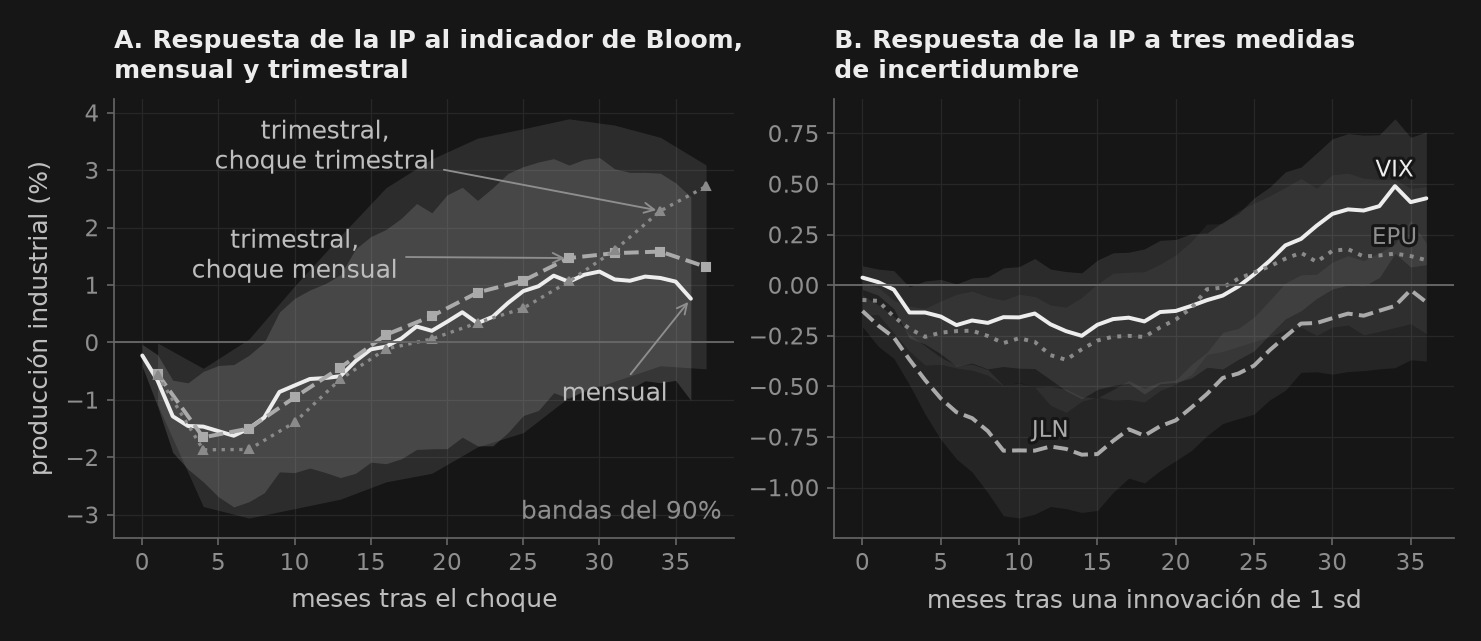

In [15]:
fig, axes = _nbstyle.figura(1, 2)
ax, lm, lq = axes[0], lp_m["ip"], lp_q["ip"]
ax.plot(lm["h"], lm["beta"], color=cols[0], lw=1.9, ls="-", label="mensual")
ax.fill_between(lm["h"], lm["lo"], lm["hi"], color=cols[0], alpha=0.15, lw=0)
xq = 3 * lq["h"] + 1                                       # el trimestre h cubre los meses 3h..3h+2
ax.plot(xq, lq["beta"], color=cols[2], lw=1.9, ls="--", marker="s", ms=4,
        label="trimestral, choque mensual")
ax.fill_between(xq, lq["lo"], lq["hi"], color=cols[2], alpha=0.15, lw=0)
ax.plot(xq, lp_qq["beta"], color=cols[3], lw=1.6, ls=":", marker="^", ms=4,
        label="trimestral, choque trimestral")
ax.axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax.set_xlabel("meses tras el choque")
ax.set_ylabel("producción industrial (%)")
ax.set_title("A. Respuesta de la IP al indicador de Bloom,\nmensual y trimestral")
ax.text(0.98, 0.03, "bandas del 90%", transform=ax.transAxes, ha="right", va="bottom", color=_nbstyle.NOTA)
# las tres sendas van juntas hasta el mes 28: cada nombre va en dos renglones (así cabe
# también en la ranura de la lámina), en el hueco de arriba, con una flecha a su senda
ax.annotate("trimestral,\nchoque trimestral", xy=(xq.iloc[11], lp_qq["beta"].iloc[11]),
            xytext=(12, 3.4), ha="center", va="center", color=_nbstyle.TEXTO,
            arrowprops=_nbstyle.FLECHA)
ax.annotate("trimestral,\nchoque mensual", xy=(xq.iloc[9], lq["beta"].iloc[9]), xytext=(10, 1.5),
            ha="center", va="center", color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
ax.annotate("mensual", xy=(lm["h"].iloc[-1], lm["beta"].iloc[-1]), xytext=(31, -0.9),
            ha="center", va="center", color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
ax, sendas = axes[1], {}
for c, col, ls in zip(MEDIDAS, [cols[0], cols[2], cols[3]], ["-", "--", ":"]):
    sendas[c], = ax.plot(lp_alt[c]["h"], lp_alt[c]["beta"], color=col, lw=1.9, ls=ls, label=c)
    ax.fill_between(lp_alt[c]["h"], lp_alt[c]["lo"], lp_alt[c]["hi"], color=col, alpha=0.10, lw=0)
ax.axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax.set_xlabel("meses tras una innovación de 1 sd")
ax.set_title("B. Respuesta de la IP a tres medidas\nde incertidumbre")
# los nombres van dentro de los ejes: el JLN en su valle, donde se separa de los otros
# dos, y el VIX y el EPU al final, donde se abren
_nbstyle.etiquetar(ax, artistas=[sendas["VIX"], sendas["EPU"]], donde=34)
_nbstyle.etiquetar(ax, artistas=[sendas["JLN"]], donde=12)
plt.show()


## 4. El trimestre se aprende mes a mes: nowcasting

El PIB de un trimestre se publica un mes después de que el trimestre termine. Los indicadores mensuales —producción industrial, nóminas, empleo, horas, capacidad, paro, precios— llegan mucho antes. Un *nowcast* es la predicción del trimestre en curso hecha con lo que ya se ha publicado de él, y la pregunta que importa es cuantitativa: **cuánto del trimestre se sabe tras el primer mes, cuánto tras el segundo, y cuánto añade el tercero.**

La respuesta empieza por una aritmética que no depende de ningún modelo. El crecimiento trimestral es la variación del *promedio* de tres meses, y ese promedio pesa los crecimientos mensuales con un triángulo: $\Delta \bar{y}_q \approx \tfrac13 x_{3} + \tfrac23 x_{2} + x_{1} + \tfrac23 x_{3,q-1} + \tfrac13 x_{2,q-1}$, con $x_m$ el crecimiento del mes $m$ del trimestre $q$. El primer mes pesa 1; el último, un tercio. Al cerrar el mes 1 ya se conoce **dos tercios** del peso del trimestre; al cerrar el mes 2, ocho novenos. El código de abajo lo comprueba sobre la propia producción industrial, donde la identidad es casi exacta ($R^2 = 1.000$ con pesos 0.33, 0.67, 1.00, 0.67, 0.33), y lo vuelve a encontrar en la regresión del PIB sobre seis meses de producción industrial: los coeficientes dibujan el mismo triángulo a escala 0.45, algo inclinado hacia el mes 1 (0.07, 0.20, 0.45, 0.31, 0.14).

Dos maneras de explotar esa aritmética. **MIDAS** (Ghysels, Santa-Clara y Valkanov 2007; la versión sin restricciones de Foroni, Marcellino y Schumacher 2015) regresa el PIB trimestral directamente sobre los $K$ meses más recientes del indicador, y re-estima la ecuación para cada mes de información: tras el mes 1 los regresores son los $K$ meses que terminan en el mes 1. Un **modelo de factores dinámico** (Giannone, Reichlin y Small 2008; Doz, Giannone y Reichlin 2011) resume los siete indicadores en un factor mensual con el filtro de Kalman, deja en `NaN` los meses aún no observados —el *borde irregular*— y una ecuación puente regresa el PIB sobre el promedio trimestral del factor. `puremacro.nowcast.kalman_dfm` hace exactamente eso; `nowcast_gdp` no (imputa por EM sin Kalman y su argumento `target_quarter` es solo una etiqueta), así que la ecuación puente va a mano.

La prueba es **pseudo fuera de muestra**: ventana creciente desde 1968T1, 80 trimestres objetivo de 2000T1 a 2019T4, tres predicciones por trimestre (tras el mes 1, 2 y 3) contra un AR(1), un AR(2) y la media histórica. Resultado: el AR(1) tiene un RMSE de 0.57 puntos de crecimiento trimestral; MIDAS con producción industrial tras el mes 1 lo baja a 0.49 y el factor tras el mes 2 a 0.47. **El tercer mes no añade nada** (0.466 frente a 0.465), que es lo que dice el triángulo. La ganancia, sin embargo, está concentrada: el factor gana al AR(1) en 38 de 80 trimestres, ningún contraste de Diebold–Mariano supera $|t|=1.6$, y sin 2008T3–2009T2 la ventaja se reduce a un 6% sobre la media incondicional. El nowcast no gana trimestre a trimestre; gana en los cuatro trimestres en los que un banco central lo necesita. 2020 —tratado aparte, porque no es un ciclo— lo lleva al extremo: el AR(1) predijo $+0.06$ para 2020T2 y $-3.2$ para 2020T3; el PIB hizo $-8.2$ y $+7.5$, y MIDAS con el mes de abril ya decía $-8.1$.

**Una nota sobre los datos, porque decide cuánto creer de estos números.** Todos los indicadores son la edición de 2026 de FRED: producción industrial re-referenciada, nóminas con las revisiones anuales de marzo, PIB en dólares encadenados de 2017. Un nowcast real se hace con la primera edición de cada mes, y las primeras ediciones se revisan —a veces mucho. Los RMSE de esta sección son, por tanto, una **cota inferior** del error en tiempo real; T01_B §4 (Mankiw–Shapiro, las *vintages* y el archivo en tiempo real) es el lugar donde se mide cuánto peor. Y «tras el mes $m$» significa «con todos los indicadores del mes $m$ publicados», que en el calendario real son dos o tres semanas después de que ese mes termine.

In [16]:
y_q = 100 * np.log(_fred("GDPC1")).diff().dropna()          # tasa trimestral, %
y_q.index = y_q.index.to_period("Q")
_m = {s: 100 * np.log(_fred(s)).diff() for s in ["INDPRO", "USPRIV", "CE16OV", "AWHI", "CPIAUCSL"]}
_m.update({s: _fred(s).diff() for s in ["TCU", "UNRATE"]})
X_m = pd.DataFrame(_m).dropna()
X_m.index = X_m.index.to_period("M")
ip_m = X_m["INDPRO"]
print(f"PIB real {y_q.index[0]}–{y_q.index[-1]}; panel mensual de {X_m.shape[1]} indicadores, "
      f"{X_m.index[0]}–{X_m.index[-1]}")


def bloque_midas(x_m, trimestres, K, m):
    """Los K meses que terminan en el mes m (1, 2 o 3) de cada trimestre, en orden
    cronológico y concatenados: la alineación que esperan u_midas y beta_midas
    (que devuelven los coeficientes con el mes más reciente primero)."""
    out = []
    for q in trimestres:
        pos = x_m.index.get_loc(q.asfreq("M", "start") + (m - 1))
        out.append(x_m.values[pos - K + 1:pos + 1])
    return np.concatenate(out)


# Verificación sintética de la convención: y = 0.1 x(mes 1) + 0.3 x(mes 2) + 0.5 x(mes 3)
rng = np.random.default_rng(0)
xs = pd.Series(rng.standard_normal(600), index=pd.period_range("1970-01", periods=600, freq="M"))
qs = pd.period_range("1971Q1", "2019Q4", freq="Q")
b3 = bloque_midas(xs, qs, 3, 3).reshape(-1, 3)
chk = u_midas(0.1 * b3[:, 0] + 0.3 * b3[:, 1] + 0.5 * b3[:, 2], bloque_midas(xs, qs, 6, 3), 6)
print("Sintético, K=6, beta (mes 3, mes 2, mes 1, ...):", chk.beta.round(3))
assert np.allclose(chk.beta, [0.5, 0.3, 0.1, 0, 0, 0], atol=1e-8)

# El triángulo de agregación, sobre la propia producción industrial
INI = pd.Period("1968Q1", freq="Q")
q_all = pd.period_range(INI, "2019Q4", freq="Q")
ip_lvl = _fred("INDPRO"); ip_lvl.index = ip_lvl.index.to_period("M")
ip_q = 100 * np.log(ip_lvl.groupby(ip_lvl.index.asfreq("Q")).mean()).diff()
tri = u_midas(ip_q.loc[q_all].values, bloque_midas(ip_m, q_all, 6, 3), 6)
print(f"IP trimestral sobre sus seis meses: beta = {tri.beta.round(2)}, R2 = {tri.R2:.3f}")
assert np.allclose(tri.beta[:5], [1 / 3, 2 / 3, 1, 2 / 3, 1 / 3], atol=0.01) and tri.R2 > 0.999
w_tri = np.array([1, 2, 3, 2, 1]) / 9
print(f"peso del trimestre conocido tras el mes 1: {w_tri[2:].sum():.3f}; tras el mes 2: {w_tri[1:].sum():.3f}")

# Y sobre el PIB: mismo triángulo, escalado
yy = y_q.loc[q_all].values
for K in (3, 6, 9):
    r = u_midas(yy, bloque_midas(ip_m, q_all, K, 3), K)
    print(f"PIB sobre IP, U-MIDAS K={K}: R2 = {r.R2:.3f}, beta = {r.beta[:6].round(2)}")
rb = beta_midas(yy, bloque_midas(ip_m, q_all, 9, 3), 9)
print(f"Beta-MIDAS K=9: R2 = {rb.R2:.3f}, pesos = {rb.weights.round(2)}, convergió = {rb.converged}")
dfm = kalman_dfm(X_m.loc[:HASTA], n_factors=1, p=1)
print("DFM, cargas del factor:", {c: round(float(l), 2) for c, l in zip(X_m.columns, dfm["loadings"][:, 0])})

PIB real 1947Q2–2026Q1; panel mensual de 7 indicadores, 1967-02–2026-06
Sintético, K=6, beta (mes 3, mes 2, mes 1, ...): [ 0.5  0.3  0.1  0.  -0.  -0. ]
IP trimestral sobre sus seis meses: beta = [0.33 0.67 1.   0.67 0.33 0.  ], R2 = 1.000
peso del trimestre conocido tras el mes 1: 0.667; tras el mes 2: 0.889
PIB sobre IP, U-MIDAS K=3: R2 = 0.466, beta = [0.16 0.29 0.54]
PIB sobre IP, U-MIDAS K=6: R2 = 0.565, beta = [ 0.07  0.2   0.45  0.31  0.14 -0.01]
PIB sobre IP, U-MIDAS K=9: R2 = 0.577, beta = [0.07 0.2  0.46 0.33 0.17 0.02]
Beta-MIDAS K=9: R2 = 0.561, pesos = [0.01 0.2  0.39 0.28 0.1  0.02 0.   0.   0.  ], convergió = True
DFM, cargas del factor: {'INDPRO': 0.88, 'USPRIV': 0.84, 'CE16OV': 0.61, 'AWHI': 0.79, 'CPIAUCSL': 0.04, 'TCU': 0.86, 'UNRATE': -0.64}


In [17]:
def nowcast(q, m, K_u=(3, 6, 9)):
    """Predicciones del crecimiento en q con los indicadores hasta el mes m de q
    y el PIB hasta q-1; ventana creciente desde INI."""
    tr = pd.period_range(INI, q - 1, freq="Q")
    ytr = y_q.loc[tr].values
    pred = {"Media": ytr.mean()}
    for p_ in (1, 2):
        Xtr = np.column_stack([np.ones(len(tr))] + [y_q.loc[tr - j].values for j in range(1, p_ + 1)])
        xte = np.r_[1.0, [y_q.loc[q - j] for j in range(1, p_ + 1)]]
        pred[f"AR({p_})"] = float(xte @ np.linalg.lstsq(Xtr, ytr, rcond=None)[0])
    for K in K_u:
        r = u_midas(ytr, bloque_midas(ip_m, tr, K, m), K)
        pred[f"U-MIDAS IP K={K}"] = r.intercept + float(r.beta @ bloque_midas(ip_m, [q], K, m)[::-1])
    r = beta_midas(ytr, bloque_midas(ip_m, tr, 9, m), 9)
    pred["Beta-MIDAS IP K=9"] = r.intercept + r.beta * float(r.weights @ bloque_midas(ip_m, [q], 9, m)[::-1])
    # DFM con borde irregular: los meses m+1..3 de q todavía no se observan
    Xp = X_m.loc[:q.asfreq("M", "end")].copy()
    Xp.loc[q.asfreq("M", "start") + m:] = np.nan
    F = kalman_dfm(Xp, n_factors=1, p=1)["factors_df"]
    Fq = F.groupby(F.index.asfreq("Q")).mean()
    Xtr = np.column_stack([np.ones(len(tr)), Fq.loc[tr].values])
    pred["DFM puente"] = float(np.r_[1.0, Fq.loc[q].values] @ np.linalg.lstsq(Xtr, ytr, rcond=None)[0])
    # Ejercicio 6: el mismo puente sin proyectar los meses que faltan — promedio de los m meses
    # observados de cada trimestre, en el entrenamiento y en el objetivo
    Fm = F[(F.index.month - 1) % 3 < m]
    Fqm = Fm.groupby(Fm.index.asfreq("Q")).mean()
    Xtr = np.column_stack([np.ones(len(tr)), Fqm.loc[tr].values])
    pred["DFM parcial"] = float(np.r_[1.0, Fqm.loc[q].values] @ np.linalg.lstsq(Xtr, ytr, rcond=None)[0])
    return pred


Q_EVAL = pd.period_range("2000Q1", "2019Q4", freq="Q")
Q_2020 = pd.period_range("2020Q1", "2020Q4", freq="Q")     # el episodio, no el ciclo
res = pd.DataFrame([{"q": q, "m": m, "modelo": k, "pred": v, "y": y_q.loc[q]}
                    for q in list(Q_EVAL) + list(Q_2020) for m in (1, 2, 3)
                    for k, v in nowcast(q, m).items()])
res["e"] = res["y"] - res["pred"]
ORDEN = ["Media", "AR(1)", "AR(2)", "U-MIDAS IP K=3", "U-MIDAS IP K=6", "U-MIDAS IP K=9",
         "Beta-MIDAS IP K=9", "DFM puente", "DFM parcial"]


def _rmse(sub):
    t = sub.groupby(["modelo", "m"])["e"].apply(lambda e: np.sqrt((e ** 2).mean())).unstack("m").loc[ORDEN]
    t.columns = [f"tras mes {m}" for m in t.columns]
    return t


ev = res[res["q"].isin(Q_EVAL)]
rmse = _rmse(ev)
print(f"RMSE pseudo fuera de muestra, {len(Q_EVAL)} trimestres 2000T1–2019T4 (pp de tasa trimestral):")
print(rmse.round(3).to_string())
print("\nR2 fuera de muestra, 1 - MSE / MSE(media):")
print((1 - (rmse ** 2).div(rmse.loc["Media"] ** 2, axis=1)).round(2).to_string())
ar1 = rmse.loc["AR(1)", "tras mes 1"]
assert 0.55 < ar1 < 0.60
assert rmse.loc["U-MIDAS IP K=6", "tras mes 1"] < 0.90 * ar1
assert rmse.loc["DFM puente", "tras mes 2"] < 0.85 * ar1
assert abs(rmse.loc["DFM puente", "tras mes 3"] - rmse.loc["DFM puente", "tras mes 2"]) < 0.01
# Sin proyectar los meses que faltan el puente es peor tras el mes 1 y el 2, e idéntico tras el 3 (no hay nada que proyectar)
assert rmse.loc["DFM parcial", "tras mes 1"] > rmse.loc["DFM puente", "tras mes 1"] + 0.01
assert rmse.loc["DFM parcial", "tras mes 2"] > rmse.loc["DFM puente", "tras mes 2"]
assert abs(rmse.loc["DFM parcial", "tras mes 3"] - rmse.loc["DFM puente", "tras mes 3"]) < 1e-6

# ¿Es significativa la ganancia? Diebold-Mariano con Newey-West (bw=4), modelo vs AR(1)
print("\nDiebold-Mariano, t de (e_AR1^2 - e_modelo^2):")
dm = {}
for mod in ["U-MIDAS IP K=6", "DFM puente"]:
    for m in (1, 2, 3):
        e_a = ev[(ev.modelo == "AR(1)") & (ev.m == m)].set_index("q")["e"]
        e_b = ev[(ev.modelo == mod) & (ev.m == m)].set_index("q")["e"]
        d = (e_a ** 2 - e_b ** 2).values
        dm[(mod, m)] = d.mean() / float(np.ravel(newey_west(np.ones((len(d), 1)), d - d.mean(), 4))[0])
    print(f"  {mod:16s}: " + "  ".join(f"mes {m}: t = {dm[(mod, m)]:.2f}" for m in (1, 2, 3)))
assert max(dm.values()) < 1.96 and min(dm.values()) > 0
gana = int((ev[(ev.modelo == "DFM puente") & (ev.m == 3)].set_index("q")["e"].abs()
            < ev[(ev.modelo == "AR(1)") & (ev.m == 3)].set_index("q")["e"].abs()).sum())
print(f"El DFM tras el mes 3 gana al AR(1) en {gana} de {len(Q_EVAL)} trimestres")
GR = pd.period_range("2008Q3", "2009Q2", freq="Q")
rmse_sin = _rmse(ev[~ev.q.isin(GR)])
print(f"\nSin 2008T3–2009T2 ({len(Q_EVAL) - len(GR)} trimestres), RMSE de la media / AR(1) / DFM tras mes 2: "
      f"{rmse_sin.loc['Media', 'tras mes 1']:.3f} / {rmse_sin.loc['AR(1)', 'tras mes 1']:.3f} / "
      f"{rmse_sin.loc['DFM puente', 'tras mes 2']:.3f}")
assert rmse_sin.loc["DFM puente", "tras mes 2"] > 0.9 * rmse_sin.loc["Media", "tras mes 1"]

RMSE pseudo fuera de muestra, 80 trimestres 2000T1–2019T4 (pp de tasa trimestral):
                   tras mes 1  tras mes 2  tras mes 3
modelo                                               
Media                   0.617       0.617       0.617
AR(1)                   0.572       0.572       0.572
AR(2)                   0.559       0.559       0.559
U-MIDAS IP K=3          0.503       0.510       0.591
U-MIDAS IP K=6          0.491       0.489       0.502
U-MIDAS IP K=9          0.499       0.497       0.490
Beta-MIDAS IP K=9       0.503       0.499       0.495
DFM puente              0.535       0.465       0.466
DFM parcial             0.561       0.478       0.466

R2 fuera de muestra, 1 - MSE / MSE(media):
                   tras mes 1  tras mes 2  tras mes 3
modelo                                               
Media                    0.00        0.00        0.00
AR(1)                    0.14        0.14        0.14
AR(2)                    0.18        0.18        0.18
U-MIDAS I

In [18]:
# 2020, aparte: el episodio es el objeto, no un segundo momento del ciclo
p20 = res[res["q"].isin(Q_2020)].pivot_table(index="q", columns=["modelo", "m"], values="pred")
print("2020, predicción tras el mes 1 / 2 / 3 (PIB observado a la izquierda):")
for q in Q_2020:
    linea = f"  {q}: PIB {y_q.loc[q]:+6.2f}"
    for mod in ["AR(1)", "U-MIDAS IP K=6", "DFM puente"]:
        linea += f" | {mod}: " + " ".join(f"{p20.loc[q, (mod, m)]:+6.2f}" for m in (1, 2, 3))
    print(linea)
print("RMSE 2020 (4 trimestres):")
print(_rmse(res[res["q"].isin(Q_2020)]).round(2).to_string())
q2, q3 = pd.Period("2020Q2", "Q"), pd.Period("2020Q3", "Q")
print(f"2020Q2 tras abril sin proyectar mayo y junio (DFM parcial): {p20.loc[q2, ('DFM parcial', 1)]:+.1f} "
      f"frente a {p20.loc[q2, ('DFM puente', 1)]:+.1f} del puente: la extrapolación pone "
      f"{p20.loc[q2, ('DFM parcial', 1)] - p20.loc[q2, ('DFM puente', 1)]:.1f} puntos; abril pone el resto.")
assert p20.loc[q2, ("DFM parcial", 1)] < -20                # abril solo ya es catastrófico
assert p20.loc[q2, ("AR(1)", 1)] > 0 and p20.loc[q3, ("AR(1)", 1)] < -3
assert -9 < p20.loc[q2, ("U-MIDAS IP K=6", 1)] < -7 and p20.loc[q2, ("DFM puente", 1)] < -25
assert 4 < p20.loc[q3, ("U-MIDAS IP K=6", 1)] < 6

2020, predicción tras el mes 1 / 2 / 3 (PIB observado a la izquierda):
  2020Q1: PIB  -1.33 | AR(1):  +0.69  +0.69  +0.69 | U-MIDAS IP K=6:  +0.25  +0.33  -0.01 | DFM puente:  +0.42  +0.63  -0.86
  2020Q2: PIB  -8.20 | AR(1):  +0.06  +0.06  +0.06 | U-MIDAS IP K=6:  -8.09  -7.17  -5.93 | DFM puente: -33.59  -9.85  -6.73
  2020Q3: PIB  +7.48 | AR(1):  -3.20  -3.20  -3.20 | U-MIDAS IP K=6:  +5.21  +5.23  +4.90 | DFM puente:  +2.18  +3.51  +3.81
  2020Q4: PIB  +1.13 | AR(1):  +0.57  +0.57  +0.57 | U-MIDAS IP K=6:  +0.05  -0.02  +0.81 | DFM puente:  +1.71  +1.86  +1.83
RMSE 2020 (4 trimestres):
                   tras mes 1  tras mes 2  tras mes 3
modelo                                               
Media                    5.70        5.70        5.70
AR(1)                    6.83        6.83        6.83
AR(2)                    6.91        6.91        6.91
U-MIDAS IP K=3           1.44        1.52        2.62
U-MIDAS IP K=6           1.48        1.59        1.85
U-MIDAS IP K=9           

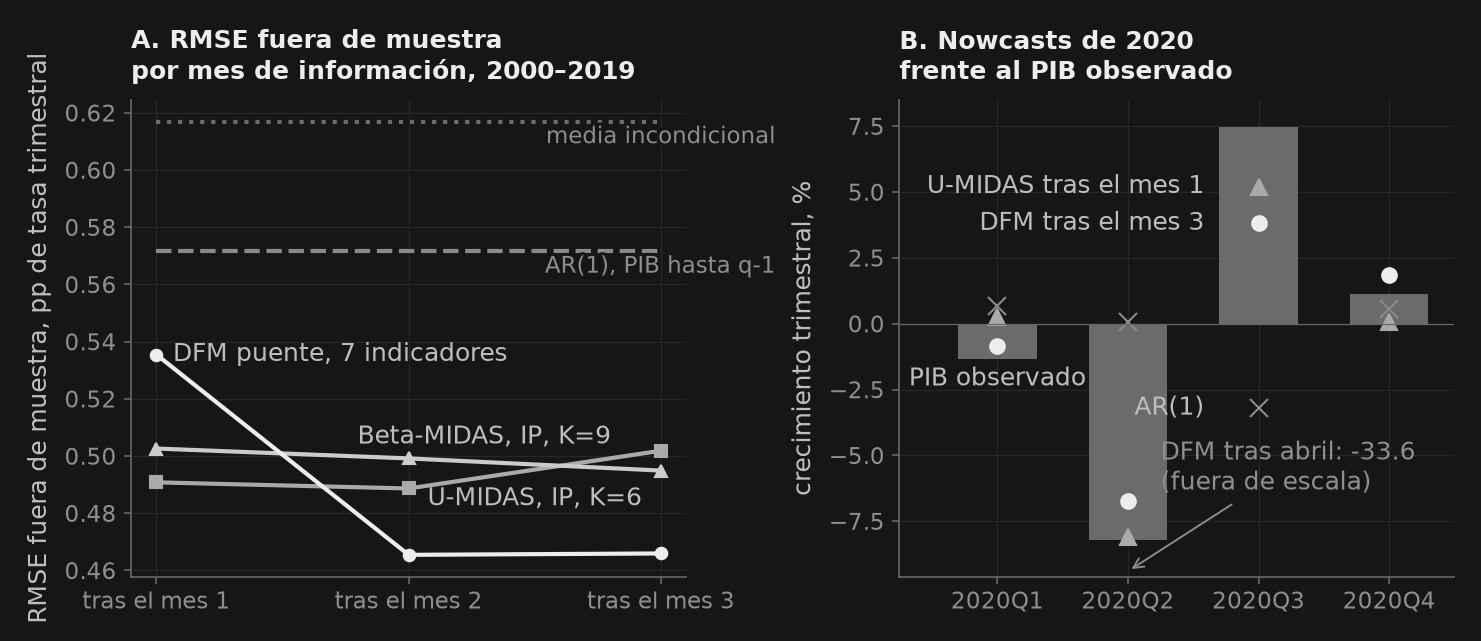

In [19]:
fig, (axL, axR) = _nbstyle.figura(1, 2)
ms = [1, 2, 3]
l_media, = axL.plot(ms, [rmse.loc["Media"].iloc[0]] * 3, color=cols[4], ls=":", label="media incondicional")
l_ar1, = axL.plot(ms, [rmse.loc["AR(1)"].iloc[0]] * 3, color=cols[3], ls="--", label="AR(1), PIB hasta q-1")
r_u, r_b, r_d = (rmse.loc[k].values for k in ("U-MIDAS IP K=6", "Beta-MIDAS IP K=9", "DFM puente"))
axL.plot(ms, r_u, "s-", color=cols[2])
axL.plot(ms, r_b, "^-", color=cols[1])
axL.plot(ms, r_d, "o-", color=cols[0], lw=2)
# las tres sendas se cruzan: cada nombre va junto al tramo donde la suya está sola
axL.annotate("DFM puente, 7 indicadores", xy=(1, r_d[0]), xytext=(8, 0), textcoords="offset points",
             va="center", color=_nbstyle.TEXTO)
axL.annotate("Beta-MIDAS, IP, K=9", xy=(2.3, np.interp(2.3, ms, r_b)), xytext=(0, 6), textcoords="offset points",
             ha="center", va="bottom", color=_nbstyle.TEXTO)
axL.annotate("U-MIDAS, IP, K=6", xy=(2.5, np.interp(2.5, ms, r_u)), xytext=(0, -8), textcoords="offset points",
             ha="center", va="top", color=_nbstyle.TEXTO)
axL.set_xticks(ms); axL.set_xticklabels(["tras el mes 1", "tras el mes 2", "tras el mes 3"])
axL.set_ylabel("RMSE fuera de muestra, pp de tasa trimestral")
axL.set_title("A. RMSE fuera de muestra\npor mes de información, 2000–2019")

xpos = np.arange(len(Q_2020))
axR.bar(xpos, y_q.loc[Q_2020].values, color=cols[4], width=0.6)
ar1 = [p20.loc[q, ("AR(1)", 1)] for q in Q_2020]
umidas = [p20.loc[q, ("U-MIDAS IP K=6", 1)] for q in Q_2020]
dfm = [p20.loc[q, ("DFM puente", 3)] for q in Q_2020]
axR.plot(xpos, ar1, "x", color=cols[3], ms=9, ls="none")
axR.plot(xpos, umidas, "^", color=cols[2], ms=8, ls="none")
axR.plot(xpos, dfm, "o", color=cols[0], ms=7, ls="none")
axR.set_ylim(-9.6, 8.5); axR.set_xlim(-0.75, 3.5)
# cada marcador lleva su nombre al lado, en 2020T3, donde más se separan
for y_, lab in ((ar1[2], "AR(1)"), (umidas[2], "U-MIDAS tras el mes 1"), (dfm[2], "DFM tras el mes 3")):
    axR.annotate(lab, xy=(2, y_), xytext=(-26, 0), textcoords="offset points", ha="right", va="center",
                 color=_nbstyle.TEXTO)
axR.text(0, y_q.loc[Q_2020].iloc[0] - 0.3, "PIB observado", ha="center", va="top", color=_nbstyle.TEXTO)
axR.annotate(f"DFM tras abril: {p20.loc[q2, ('DFM puente', 1)]:+.1f}\n(fuera de escala)", xy=(1, -9.4),
             xytext=(1.25, -6.3), color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
axR.axhline(0, color=_nbstyle.SPINE, lw=0.6)
axR.set_xticks(xpos); axR.set_xticklabels([str(q) for q in Q_2020])
axR.set_ylabel("crecimiento trimestral, %")
axR.set_title("B. Nowcasts de 2020\nfrente al PIB observado")
_nbstyle.etiquetar(axL, artistas=[l_media, l_ar1])
plt.show()



**Lectura.** Tres cosas que el triángulo predice y los datos confirman. Primera: la ventana de tres meses que termina en el mes 3 ($K=3$) es *peor* tras el mes 3 que tras el mes 1 (0.59 frente a 0.50), porque ha perdido los dos meses del trimestre anterior que pesan $\tfrac23$ y $\tfrac13$; con $K=6$ el problema desaparece. Segunda: el factor tras el mes 1 es peor que MIDAS tras el mes 1 (0.54 frente a 0.49), y no porque proyecte los dos meses que faltan con su AR(1): la fila «DFM parcial» de la tabla quita esa proyección —promedia sólo los meses observados, en el entrenamiento y en el objetivo— y el factor empeora, 0.56 tras el mes 1 y 0.48 tras el mes 2 (tras el mes 3 no hay nada que proyectar y las dos filas coinciden en 0.47). La persistencia ayuda en los trimestres normales; con un solo mes, el puente sobre siete indicadores todavía no bate a la ecuación de MIDAS sobre el IP solo, y la razón queda como pregunta abierta: el test que la atribuía a la proyección sale negativo. Tras el mes 2 el factor ya gana, porque combina siete indicadores en vez de uno. Tercera, y es la que hay que recordar: en abril de 2020 el factor extrapoló el mes más anómalo de la historia de la serie a través de su AR(1) y predijo $-33.6$ para el trimestre. Un modelo lineal no sabe qué es una cuarentena; el indicador sí, y por eso MIDAS acertó el orden de magnitud. El ejercicio 6 te pide separar las dos cosas, y la impresión ya adelanta la respuesta: sin proyectar mayo y junio el factor da $-28.5$, así que la extrapolación pone 5 puntos y abril mismo pone el resto.

## 5. México a frecuencia mensual: la transmisión monetaria

Un choque de política monetaria tarda entre uno y dos años en llegar al producto. Eso es una afirmación sobre *meses*, y la única identificación barata que tenemos —la recursiva de Christiano, Eichenbaum y Evans (1999): el banco central ve el producto y la inflación del periodo antes de mover la tasa, y el producto no responde a la tasa dentro del periodo— es creíble para un mes y deja de serlo para un trimestre. «Ve el producto del periodo» es la aproximación de CEE, no una descripción literal: la producción industrial del mes $t$ se publica semanas después, y lo que el banco ve en el mes es su pronóstico de ella; el código de abajo imprime el coeficiente de impacto, que la ordenación supone cero, para que se vea cuánto cuesta la aproximación. Esta sección estima la misma proyección local dos veces, con los mismos datos de México, y mide qué le pasa a la respuesta cuando el periodo pasa de 30 a 90 días.

### Identificación, efecto información y el «Price Puzzle»
En la macroeconomía empírica, estimar la respuesta de los precios ante una subida de la tasa de interés nominal produce habitualmente el célebre **«Price Puzzle»** (Sims 1992): tras un incremento en $\Delta i_t$, el nivel de precios o la inflación parece subir en lugar de bajar. ¿Por qué ocurre esto? Porque la función de reacción del banco central es eminentemente prospectiva (*forward-looking*). Las autoridades monetarias no alteran las tasas de forma aleatoria; las suben cuando sus pronósticos internos anticipan presiones inflacionarias venideras (Romer & Romer 2004). Si el econometrista estima las respuestas dinámicas con un conjunto de información retrospectivo (como los rezagos habituales de un VAR o de una proyección local), la innovación de la tasa queda contaminada por el pronóstico de inflación futura no observado por el investigador.

Como demuestran Miranda-Agrippino y Ricco (2021), los comunicados de política monetaria transmiten dos señales simultáneas:
1. Un choque monetario contractivo puro (un endurecimiento exógeno de la postura de política).
2. Un **choque de información del banco central** (orientación *Délfica*): subir la tasa revela al público que el equipo técnico del banco central maneja información privada o más actualizada según la cual la demanda y la inflación subyacente vienen más fuertes de lo previsto.

Sin purgar ese pronóstico interno, el econometrista confunde el choque de política con la propia noticia inflacionaria que indujo al banco central a subir la tasa.

La macroeconomía moderna resuelve este dilema mediante **identificación de alta frecuencia** (Gertler & Karadi 2015, Nakamura & Steinsson 2018). Al medir las variaciones de precios de activos financieros (futuros sobre fondos federales, eurodólares o swaps de índices a un día - OIS) en una ventana estrecha de **30 minutos** alrededor de la rueda de prensa de política monetaria (10 minutos antes y 20 después), se aíslan sorpresas ortogonales a los fundamentos macroeconómicos. En 30 minutos ni el producto ni los precios de los bienes pueden reaccionar, quebrando la simultaneidad. Al combinar estas sorpresas de alta frecuencia con la purga de los pronósticos internos del banco central (o usándolas como instrumentos en un proxy-SVAR), el puzzle de precios desaparece por completo: la actividad económica se contrae y los precios descienden monótonamente.

En México, el instrumento es la tasa interbancaria a 3 meses (Banxico adopta el objetivo de inflación en 2001; la muestra base va de 2001-01 a 2019-12, y el corte de 2019 es el de T01_A §1.1). Es la tasa de mercado, no la de política: hasta 2008 Banxico fijaba el «corto» —un objetivo de saldos, no de tasa— y la interbancaria es el reflejo de mercado de esa postura; desde 2008 fija directamente la tasa objetivo y las dos se mueven juntas. La regla de política se estima como en T05_B §4 —una regresión de $\Delta i_t$ sobre lo que Banxico ve en el mes y doce rezagos de todo— y el **choque es su residuo**, lo que el banco hizo y la regla no explica. Después, `lp_hac` proyecta el log de la producción industrial y la inflación sobre ese residuo, y `lp_iv` repite el ejercicio con la dirección de los anuncios de Banxico como instrumento, al estilo Romer y Romer (2004) pero sin su paso decisivo: aquí el anuncio *no* se purga del pronóstico interno, y el resultado enseña por qué ese paso existe.

**Una nota sobre los datos, porque decide cómo se mide el precio.** `CPALTT01MXM659N` no es la inflación mensual: el sufijo 659 de la MEI de la OCDE es *tasa de crecimiento respecto al mismo periodo del año anterior*. El código lo comprueba —su media en 2001–2019 es 4.3, la inflación anual promedio de México, y el valor de julio de 2024 es 5.57, la cifra que publicó el INEGI—; acumularla como si fuera mensual produce un «nivel de precios» que crece 66% al año. Se usa tal cual, como inflación a 12 meses, con la subyacente (`CPGRLE01MXM659N`, mismo sufijo) al lado: la diferencia interanual ya elimina la estacionalidad (las medias por mes calendario van de 4.23 a 4.48), así que no hace falta desestacionalizar nada. La tasa interbancaria empieza en 1997-01: la crisis del Tequila queda fuera, y se dice.

In [20]:
mx = pd.DataFrame({
    "i":    _fred("IR3TIB01MXM156N"),          # interbancaria 3m, %
    "pi":   _fred("CPALTT01MXM659N"),          # inflación 12m, %
    "pic":  _fred("CPGRLE01MXM659N"),          # subyacente 12m, %
    "lip":  pd.read_csv(DATOS / "oecd_mei_mex_log_ip.csv", parse_dates=["date"])
              .set_index("date")["log_ip_x100"],
    "lepu": np.log(pd.read_csv(DATOS / "epu_mex_mensual.csv", parse_dates=["date"])
                     .set_index("date")["epu"]),
}).join(pd.read_csv(DATOS / "banxico_stance_monthly.csv", parse_dates=["date"])
          .set_index("date")["banxico_direction"])
mx["di"], mx["dlip"] = mx["i"].diff(), mx["lip"].diff()

# La nota sobre los datos, en números.
w = mx.loc["2001":HASTA, "pi"]
print(f"CPALTT01MXM659N, 2001-2019: media {w.mean():.2f}, sd {w.std():.2f}; "
      f"jul-2024 = {mx['pi'].loc['2024-07-01']:.2f}. Medias por mes calendario: "
      f"{w.groupby(w.index.month).mean().min():.2f} a {w.groupby(w.index.month).mean().max():.2f}. "
      f"Acumulada como si fuera mensual: {100 * ((1 + w.mean() / 100) ** 12 - 1):.0f}% al año.")
print(f"La tasa interbancaria empieza en {mx['i'].dropna().index[0]:%Y-%m}: 1995 queda fuera.")
assert 4 < w.mean() < 5                       # es interanual, no mensual
assert mx["i"].dropna().index[0].year == 1997

CTRL = ["dlip", "pi", "lepu"]                  # lo que Banxico ve en el periodo


def regla(df, p):
    """Residuo de Δi_t sobre (Δlog IP, π, log EPU)_t y p rezagos de Δi y de los tres."""
    X = pd.concat([df[CTRL]] + [df[["di"] + CTRL].shift(k).add_suffix(f"_L{k}")
                                for k in range(1, p + 1)], axis=1)
    X.insert(0, "const", 1.0)
    ok = X.notna().all(axis=1) & df["di"].notna()
    b = np.linalg.lstsq(X[ok].values, df.loc[ok, "di"].values, rcond=None)[0]
    e = pd.Series(np.nan, index=df.index)
    e[ok] = df.loc[ok, "di"].values - X[ok].values @ b
    return e, 1 - e[ok].var() / df.loc[ok, "di"].var(), int(ok.sum())


def extremo(r, signo):
    """Fila del piso (signo=-1) o del máximo (signo=+1) de una proyección local."""
    return r.loc[(signo * r["beta"]).idxmax()]


def _txt(fila, unidad):
    return (f"h = {int(fila['h'])}: {fila['beta']:+.2f} {unidad} "
            f"[{fila['lo']:+.2f}, {fila['hi']:+.2f}], t = {fila['t']:.1f}")


def proyecta(df, p, H, etiqueta, unidad):
    e, r2, n = regla(df, p)
    d = df.assign(shock=e)
    ip = lp_hac(d, y="lip", x="shock", horizons=range(0, H + 1), n_lags=p, controls=["pi", "lepu"])
    pi = lp_hac(d, y="pi", x="shock", horizons=range(0, H + 1), n_lags=p, controls=["dlip", "lepu"])
    pic = lp_hac(d.assign(pi=d["pic"]), y="pi", x="shock", horizons=range(0, H + 1),
                 n_lags=p, controls=["dlip", "lepu"])
    print(f"\n{etiqueta}: n = {n}. R2 de la regla = {r2:.2f}; sd(choque) = {e.std():.2f} "
          f"frente a sd(Δi) = {df['di'].std():.2f} (cociente {e.std() / df['di'].std():.2f}).")
    print("  IP, piso           ", _txt(extremo(ip, -1), "% del nivel"))
    print("  inflación, máximo  ", _txt(extremo(pi, +1), "pp"))
    print("  subyacente, máximo ", _txt(extremo(pic, +1), "pp"))
    return {"ip": ip, "pi": pi, "pic": pic, "d": d, "r2": r2, "n": n}


mA = mx.loc["2000-01":HASTA]                  # 2000 sólo aporta rezagos
rm = proyecta(mA, p=12, H=36, etiqueta="MENSUAL 2001-2019", unidad="meses")
piso_m, puz_m, puz_c = extremo(rm["ip"], -1), extremo(rm["pi"], +1), extremo(rm["pic"], +1)
assert 10 <= piso_m["h"] <= 18 and piso_m["beta"] < 0      # la joroba está donde debe...
assert piso_m["hi"] > 0                                     # ...y la banda del 90% toca el cero
assert puz_m["h"] <= 12 and puz_m["lo"] > 0 and puz_c["lo"] > 0   # puzzle de precios, también en la subyacente
# La senda completa del producto: el impacto que la ordenación recursiva supone cero, y la vuelta a positivo.
_ipm = rm["ip"].set_index("h")
print("  IP mensual, h=0..9:   " + "  ".join(f"{_ipm.loc[h, 'beta']:+.2f} (t {_ipm.loc[h, 't']:.1f})" for h in range(10))
      + f"; |t| máximo en h=1..9: {_ipm.loc[1:9, 't'].abs().max():.2f}")
print("  IP mensual, h=20..27: " + "  ".join(f"{_ipm.loc[h, 'beta']:+.2f}" for h in range(20, 28))
      + f"; máximo {_ipm['beta'].max():+.2f} en h={int(_ipm['beta'].idxmax())} (t {_ipm.loc[_ipm['beta'].idxmax(), 't']:.1f})")
h_cero = int(_ipm.loc[int(piso_m["h"]):].index[_ipm.loc[int(piso_m["h"]):, "beta"] > 0].min())
print(f"  Tras el piso, el primer coeficiente positivo es el del mes {h_cero}; "
      f"media de los meses 24-26: {_ipm.loc[24:26, 'beta'].mean():+.2f}. "
      f"Horizontes cuya banda del 90% excluye el cero: {[int(h) for h in _ipm.index if _ipm.loc[h, 'lo'] > 0 or _ipm.loc[h, 'hi'] < 0]}.")
assert _ipm.loc[0, "beta"] < 0 and (_ipm.loc[1:9, "beta"].abs() < 0.5).all()   # impacto negativo; nada hasta el mes 9
assert _ipm.loc[1:9, "t"].abs().max() < 1.1                                      # ...y ningún |t| llega a 1.1
assert 20 <= h_cero <= 26 and _ipm.loc[24:27, "beta"].max() > 1                # y la senda mensual también sube después
print(f"\nLos episodios que lo producen: dic-2015 i = {mx['i']['2015-12-01']:.1f}, "
      f"π = {mx['pi']['2015-12-01']:.2f}; dic-2017 π = {mx['pi']['2017-12-01']:.2f}; "
      f"dic-2018 i = {mx['i']['2018-12-01']:.1f}. En 2008, π pasa de {mx['pi']['2008-01-01']:.2f} "
      f"(ene) a {mx['pi']['2008-12-01']:.2f} (dic) con i de {mx['i']['2008-04-01']:.2f} a {mx['i']['2008-10-01']:.2f}.")

CPALTT01MXM659N, 2001-2019: media 4.33, sd 1.09; jul-2024 = 5.57. Medias por mes calendario: 4.23 a 4.48. Acumulada como si fuera mensual: 66% al año.
La tasa interbancaria empieza en 1997-01: 1995 queda fuera.

MENSUAL 2001-2019: n = 228. R2 de la regla = 0.47; sd(choque) = 0.32 frente a sd(Δi) = 0.52 (cociente 0.63).
  IP, piso            h = 14: -0.75 % del nivel [-1.71, +0.21], t = -1.3
  inflación, máximo   h = 10: +0.52 pp [+0.20, +0.85], t = 2.7
  subyacente, máximo  h = 7: +0.45 pp [+0.28, +0.62], t = 4.3
  IP mensual, h=0..9:   -0.34 (t -1.7)  +0.08 (t 0.3)  +0.23 (t 0.9)  +0.22 (t 0.8)  +0.09 (t 0.3)  +0.20 (t 0.6)  -0.19 (t -0.6)  -0.33 (t -0.9)  -0.44 (t -1.0)  -0.12 (t -0.3); |t| máximo en h=1..9: 1.05
  IP mensual, h=20..27: -0.08  -0.26  -0.00  +0.21  +0.43  +1.05  +1.36  +1.24; máximo +1.36 en h=26 (t 1.4)
  Tras el piso, el primer coeficiente positivo es el del mes 23; media de los meses 24-26: +0.95. Horizontes cuya banda del 90% excluye el cero: [0].

Los episodios q

In [21]:
# (ii) La dirección de los anuncios como instrumento de Δi.
d = rm["d"]
iv = lp_iv(d, y="lip", x="di", z="banxico_direction", horizons=range(0, 37), n_lags=12,
           controls=["pi", "lepu"])
ivp = lp_iv(d, y="pi", x="di", z="banxico_direction", horizons=range(0, 37), n_lags=12,
            controls=["dlip", "lepu"])
rr = lp_hac(d, y="lip", x="banxico_direction", horizons=range(0, 37), n_lags=12, controls=["pi", "lepu"])
n_sub = int((mA["banxico_direction"].loc["2001":] == 1).sum())
n_baj = int((mA["banxico_direction"].loc["2001":] == -1).sum())
F_m = float(iv["first_stage_f"].iloc[0])
print(f"Anuncios 2001-2019: {n_sub} al alza, {n_baj} a la baja. Primera etapa (h = 0): F = {F_m:.1f}; "
      f"mínimo sobre horizontes {iv['first_stage_f'].min():.1f}, mediana {iv['first_stage_f'].median():.1f}.")
print("  IP, VI, piso            ", _txt(extremo(iv, -1), "% del nivel"))
print("  IP, anuncio como choque ", _txt(extremo(rr, -1), "% por anuncio"))
print("  inflación, VI, máximo   ", _txt(extremo(ivp, +1), "pp"))
assert F_m > 10                                # el instrumento es relevante
assert extremo(ivp, +1)["t"] > 1.5             # ...y el puzzle sobrevive al instrumento (p < 0.10, t ~ 1.8)

# La muestra larga, sólo por dejar constancia: 2020 manda en cualquier regresión que lo incluya.
rl = proyecta(mx.loc["2000-01":], p=12, H=36, etiqueta="MENSUAL 2001-2023 (el EPU acaba en 2023-02)",
              unidad="meses")
w21 = mx.loc["2021":"2023"]
print(f"  2021-23: la tasa va de {w21['i'].min():.2f} ({w21['i'].idxmin():%Y-%m}) a {w21['i'].max():.2f} "
      f"({w21['i'].idxmax():%Y-%m}), {100 * (w21['i'].max() - w21['i'].min()):.0f} pb; "
      f"π máxima {w21['pi'].max():.2f} en {w21['pi'].idxmax():%Y-%m}.")

Anuncios 2001-2019: 39 al alza, 26 a la baja. Primera etapa (h = 0): F = 29.3; mínimo sobre horizontes 13.3, mediana 15.8.
  IP, VI, piso             h = 23: -3.84 % del nivel [-8.71, +1.02], t = -1.3
  IP, anuncio como choque  h = 24: -0.67 % por anuncio [-1.49, +0.16], t = -1.3
  inflación, VI, máximo    h = 19: +1.74 pp [+0.49, +3.00], t = 2.3

MENSUAL 2001-2023 (el EPU acaba en 2023-02): n = 266. R2 de la regla = 0.40; sd(choque) = 0.33 frente a sd(Δi) = 0.47 (cociente 0.71).
  IP, piso            h = 28: -0.76 % del nivel [-2.25, +0.73], t = -0.8
  inflación, máximo   h = 6: +0.64 pp [+0.31, +0.97], t = 3.2
  subyacente, máximo  h = 7: +0.68 pp [+0.43, +0.94], t = 4.4
  2021-23: la tasa va de 4.24 (2021-03) a 11.64 (2023-04), 740 pb; π máxima 8.70 en 2022-09.


In [22]:
# (iii) El punto: lo mismo, agregado a trimestres.
q = mx[["i", "lip", "pi", "pic", "lepu"]].resample("QS").mean()
q = q[mx[["i", "lip", "pi", "lepu"]].resample("QS").count().min(axis=1) == 3]   # trimestres completos
q["banxico_direction"] = mx["banxico_direction"].resample("QS").sum()
q["di"], q["dlip"] = q["i"].diff(), q["lip"].diff()
rq = proyecta(q.loc["2000-01":HASTA], p=4, H=12, etiqueta="TRIMESTRAL 2001-2019", unidad="trimestres")
ivq = lp_iv(rq["d"], y="lip", x="di", z="banxico_direction", horizons=range(0, 13), n_lags=4,
            controls=["pi", "lepu"])
F_q = float(ivq["first_stage_f"].iloc[0])
piso_q, alza_q = extremo(rq["ip"], -1), extremo(rq["ip"], +1)
print(f"  IP, VI, piso            ", _txt(extremo(ivq, -1), "% del nivel"))
print(f"  primera etapa (h = 0): F = {F_q:.1f}, mediana {ivq['first_stage_f'].median():.1f}.")
print(f"\nDe meses a trimestres: R2 de la regla {rm['r2']:.2f} -> {rq['r2']:.2f}; piso del IP "
      f"{piso_m['beta']:+.2f}% a los {int(piso_m['h'])} meses -> {piso_q['beta']:+.2f}% a los "
      f"{int(piso_q['h'])} trimestres (t = {piso_q['t']:.1f}), y {alza_q['beta']:+.2f}% a los "
      f"{int(alza_q['h'])} trimestres (t = {alza_q['t']:.1f}); F de la primera etapa {F_m:.0f} -> {F_q:.0f}.")
h3 = 3 * int(alza_q["h"])
print(f"La senda mensual en los meses {h3}-{h3 + 2} ya es positiva: media {_ipm.loc[h3:h3 + 2, 'beta'].mean():+.2f} "
      f"(máximo {_ipm.loc[h3:h3 + 2, 'beta'].max():+.2f}); el signo no lo fabrica el trimestre.")
assert _ipm.loc[h3:h3 + 2, "beta"].mean() > 0
assert rq["r2"] > rm["r2"] + 0.1              # la regla "explica" más del trimestre...
assert abs(piso_q["beta"]) < abs(piso_m["beta"])   # ...y la joroba del producto se pierde
assert F_q > F_m                               # ...pero el instrumento gana fuerza


TRIMESTRAL 2001-2019: n = 76. R2 de la regla = 0.68; sd(choque) = 0.48 frente a sd(Δi) = 0.92 (cociente 0.52).
  IP, piso            h = 3: -0.24 % del nivel [-0.80, +0.31], t = -0.7
  inflación, máximo   h = 1: +0.41 pp [+0.17, +0.65], t = 2.8
  subyacente, máximo  h = 2: +0.30 pp [+0.13, +0.47], t = 2.9
  IP, VI, piso             h = 3: -1.46 % del nivel [-3.07, +0.16], t = -1.5
  primera etapa (h = 0): F = 34.9, mediana 60.8.

De meses a trimestres: R2 de la regla 0.47 -> 0.68; piso del IP -0.75% a los 14 meses -> -0.24% a los 3 trimestres (t = -0.7), y +1.79% a los 8 trimestres (t = 1.8); F de la primera etapa 29 -> 35.
La senda mensual en los meses 24-26 ya es positiva: media +0.95 (máximo +1.36); el signo no lo fabrica el trimestre.


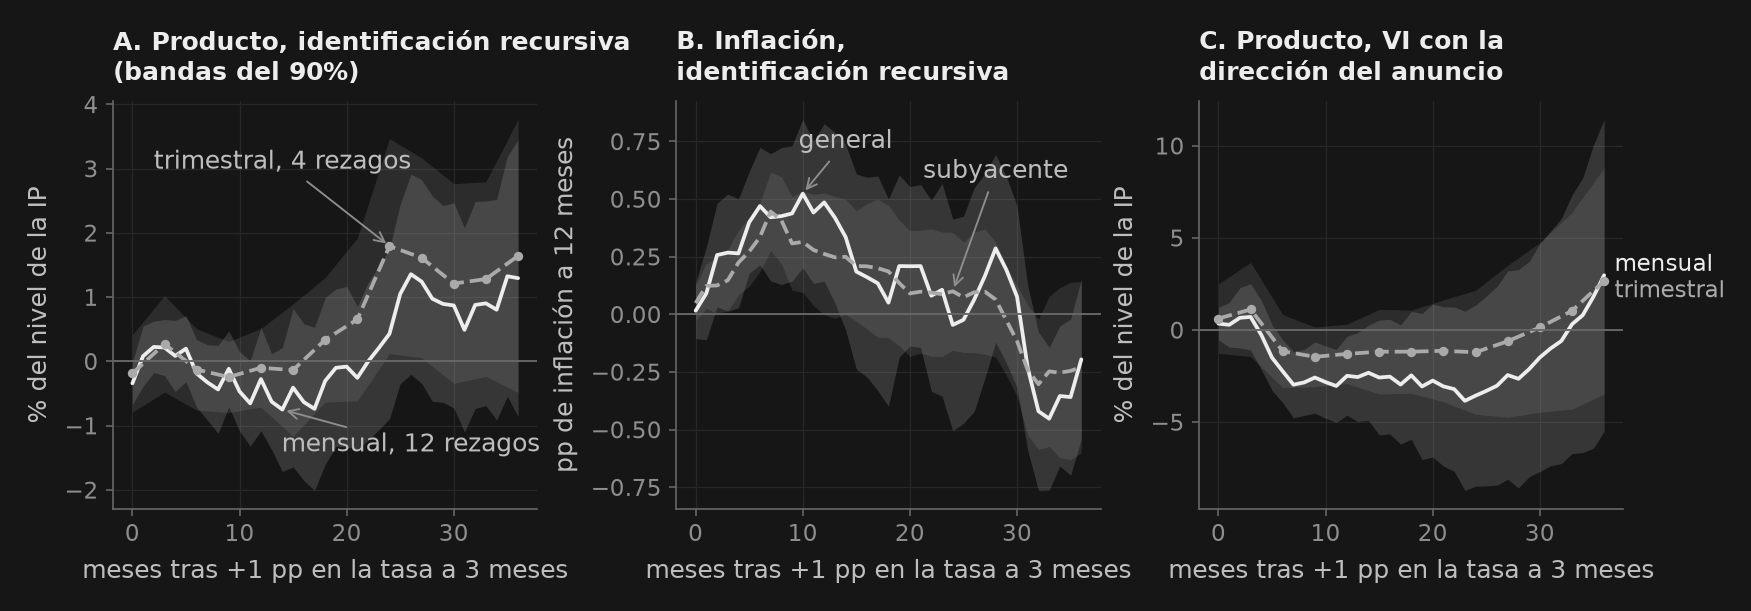

In [23]:
fig, axs = _nbstyle.figura(1, 3)


def _banda(ax, r, c, lab, esc=1, **kw):
    ax.plot(esc * r["h"], r["beta"], color=c, lw=1.8, label=lab, **kw)
    ax.fill_between(esc * r["h"], r["lo"], r["hi"], color=c, alpha=0.15, lw=0)


def _en(r, h, esc=1):
    """El punto (h, beta) de la senda r, con h en meses."""
    fila = r.loc[r["h"] == h].iloc[0]
    return (esc * fila["h"], fila["beta"])


_banda(axs[0], rm["ip"], cols[0], "mensual, 12 rezagos", ls="-")
_banda(axs[0], rq["ip"], cols[2], "trimestral, 4 rezagos", esc=3, ls="--", marker="o", ms=3.5)
axs[0].set_title("A. Producto, identificación recursiva\n(bandas del 90%)")
axs[0].set_ylabel("% del nivel de la IP")
_banda(axs[1], rm["pi"], cols[0], "general", ls="-")
_banda(axs[1], rm["pic"], cols[2], "subyacente", ls="--")
axs[1].set_title("B. Inflación,\nidentificación recursiva")
axs[1].set_ylabel("pp de inflación a 12 meses")
_banda(axs[2], iv, cols[0], "mensual", ls="-")
_banda(axs[2], ivq, cols[2], "trimestral", esc=3, ls="--", marker="o", ms=3.5)
axs[2].set_title("C. Producto, VI con la\ndirección del anuncio")
axs[2].set_ylabel("% del nivel de la IP")
for ax in axs:
    ax.axhline(0, color=_nbstyle.SPINE, lw=0.9)
    ax.set_xlabel("meses tras +1 pp en la tasa a 3 meses")
# las sendas de A y B se cruzan: cada nombre apunta a un punto donde la suya está sola
h_q = int(rq["ip"].loc[rq["ip"]["beta"].idxmax(), "h"])          # el máximo trimestral
h_m = int(rm["ip"].loc[rm["ip"]["beta"].idxmin(), "h"])          # el piso mensual
axs[0].annotate("trimestral, 4 rezagos", xy=_en(rq["ip"], h_q, 3), xytext=(2, 3.1), va="center",
                color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
axs[0].annotate("mensual, 12 rezagos", xy=_en(rm["ip"], h_m), xytext=(26, -1.3), ha="center", va="center",
                color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
axs[1].annotate("general", xy=_en(rm["pi"], 10), xytext=(14, 0.75), ha="center", va="center",
                color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
axs[1].annotate("subyacente", xy=_en(rm["pic"], 24), xytext=(28, 0.62), ha="center", va="center",
                color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)
_nbstyle.etiquetar(axs[2], donde="fin")
plt.show()


**Lo que dice.** A frecuencia mensual la respuesta del producto tiene casi la forma de manual: nada entre el mes 1 y el 9 (coeficientes entre $-0.44$ y $+0.23$, $|t|$ máximo 1.05), un piso de $-0.75\%$ a los 14 meses y el primer coeficiente positivo en el mes 23. El «casi» es el impacto: $-0.34\%$ en el propio mes, $t = -1.7$, el único horizonte de toda la senda cuya banda del 90% excluye el cero — y es justo el coeficiente que la ordenación recursiva supone cero. El residuo de la regla no es ortogonal a la producción industrial del mes: o Banxico reacciona dentro del mes a algo que también mueve la IP, o la IP reacciona a la tasa en menos de 30 días. Es el precio de la aproximación de CEE, y a frecuencia mensual es pequeño pero no es cero. El piso es la forma, no el nivel: su banda va de $-1.71$ a $+0.21$, y con 228 meses y doce rezagos de cuatro variables no da para más.

La inflación es otra cosa: sube **medio punto** durante el primer año (máximo $+0.52$ pp a los 10 meses, $t = 2.7$) y la subyacente sube igual ($+0.45$, $t = 4.3$). Es el *price puzzle* de Sims (1992), y la subyacente dice de dónde viene: no de la fruta ni de la gasolina, sino de que Banxico sube la tasa cuando *sabe* que la inflación va a subir — y no en un solo episodio: el ejercicio 8 quita el ciclo de subidas de 2016–18 y la subyacente no se mueve. Los episodios están en la impresión: entre diciembre de 2015 y diciembre de 2018 la tasa pasa de 3.5 a 8.5 mientras la inflación sube de 2.13 a 6.77 en diciembre de 2017, y en 2008 sube de 7.96 a 8.76 con la inflación de 3.70 a 6.53. Una regla con doce rezagos no ve venir el traspaso del tipo de cambio; el banco sí. Lo que la regresión llama «choque» lleva dentro el pronóstico interno.

**Lo que el instrumento no arregla.** La dirección de los anuncios es un instrumento fuerte ($F = 29$ en el impacto, nunca por debajo de 13 en ningún horizonte) y la respuesta del producto conserva la forma con cinco veces la escala y cinco veces la banda: $-3.84\%$ a los 23 meses, de $-8.71$ a $+1.02$. Usar el anuncio directamente como choque, que es lo que hace la forma reducida de Romer y Romer, da $-0.67\%$ por anuncio a los 24 meses con la misma $t$ de $-1.3$: el instrumento reescala, no afina. Y el puzzle sobrevive ($+1.74$ pp de inflación, $t = 2.3$), exactamente lo que predicen Romer y Romer (2004) y Miranda-Agrippino y Ricco (2021): el anuncio es la *decisión*, y la decisión incorpora el conjunto de información del banco central. Sin restar el pronóstico interno del banco —el paso que Romer y Romer aplican con los *Greenbooks* y que aquí no se puede hacer directamente porque Banxico no publica archivos históricos de pronósticos en tiempo real—, la variable narrativa hereda la endogeneidad de la tasa. Es precisamente por esto que la literatura moderna (Gertler & Karadi 2015) acude a sorpresas de alta frecuencia en mercados de futuros para aislar choques no contaminados por proyecciones macroeconómicas.

**Lo que hace el trimestre.** La misma regla explica el 47% de $\Delta i$ en meses y el 68% en trimestres: en 90 días el producto y la inflación ya han reaccionado a la tasa, y la ordenación recursiva que era creíble para 30 días atribuye esa reacción a la regla. El residuo encoge (del 63% al 52% de la desviación típica de $\Delta i$) y con él se va la joroba: el piso trimestral es $-0.24\%$ a los 3 trimestres ($t = -0.7$). A los dos años el producto trimestral está $+1.79\%$ *por encima* ($t = 1.8$), pero ese signo no lo fabrica el trimestre: la senda mensual cruza a positivo en el mes 23 y llega a $+1.36$ en el mes 26 ($t = 1.4$), y la media de sus meses 24–26 es $+0.95$; el trimestre 8 es esa misma excursión, más grande y con la misma falta de precisión. Lo que la agregación quita es el **piso de los 14 meses** —de $-0.75$ a $-0.24$—, que es lo único que la teoría pedía ver. La agregación no destruye la información; destruye la restricción de *timing* que identificaba el choque. El instrumento, en cambio, **gana** fuerza al agregar ($F$ de 29 a 35 en el impacto, mediana de 16 a 61), porque un anuncio a mitad de mes sólo mueve la mitad del promedio mensual de la tasa y termina de pasar en el mes siguiente; en el trimestre el traspaso está completo. Por eso la banda de la VI trimestral es tres veces más estrecha ($-1.46\%$ a los 3 trimestres, de $-3.07$ a $+0.16$). Con 2020–23 dentro (n = 266) la respuesta del producto es ruido y el puzzle crece ($+0.64$ pp a los 6 meses, $t = 3.2$): la tasa subió 740 pb entre marzo de 2021 y abril de 2023 mientras la inflación llegaba a 8.70% en septiembre de 2022, y una regresión lo lee como que subir la tasa sube la inflación. El ejercicio 8 te pide separar las dos cosas.

## 6. Cincuenta estados, seiscientos meses: la regla de Sahm y la difusión de una recesión

La regla de Sahm (2019) es la afirmación más simple que se puede hacer con la tasa de paro: si la media móvil de tres meses sube **0.50 puntos o más** sobre su mínimo de los doce meses anteriores, la economía está en recesión. No hay modelo, no hay parámetro estimado, y por eso es interesante: es un hecho sobre la *forma* del paro en el ciclo —sube deprisa y baja despacio— convertido en detector. Desde 1976 dispara entre **1 y 4 meses** después de cada pico del NBER, seis de seis, y se equivoca dos veces: julio de 2003, donde roza el umbral exacto, y julio de 2024, tres meses por encima sin recesión detrás.

Esta sección hace con esa regla lo que T01_A §4 hizo con los hechos del ciclo: la convierte de una propiedad de una serie en una **distribución entre cincuenta y un estados**. Aparecen cuatro cosas. Primero, la difusión —la proporción de estados que han disparado— dibuja la recesión de 2008 como una ola de veintiún meses que empieza en Minnesota y Florida en la primavera de 2007 y acaba en Nebraska, Wyoming y Dakota del Norte a finales de 2008, y la de 2020 como un escalón de tres, con 47 estados disparando entre marzo y abril. Segundo, y en negativo: esa difusión **no adelanta** a la regla nacional. El umbral más bajo sin falsas alarmas, la mitad de los estados, dispara más tarde que el agregado en cuatro de seis recesiones; los umbrales que sí adelantan —uno o dos meses el del 30%, hasta cuatro el del 20%— compran esa ventaja con falsas alarmas: el del 30% con dos (2003 y 2024) más dos disparos de 2025 que quedan «sin recesión declarada», el del 20% con ocho y dos recesiones perdidas. Promediar y luego umbralizar conserva la información que umbralizar y luego promediar tira. Tercero, la dispersión entre estados sube en las seis recesiones y su coeficiente de variación no se mueve: la recesión *multiplica* el paro de cada estado en vez de sumarle un mismo escalón, así que en puntos porcentuales parece regional y en proporciones es nacional.

### Áreas Monetarias Óptimas y el Ajuste Laboral Interestatal
Cuarto, revelamos la persistencia estructural de las disparidades interestatales: la vida media del paro *relativo* de un estado es de **41 meses** (mediana), con Missouri en 14 y Virginia Occidental en 168. En teoría macroeconómica, esta persistencia proporciona una ventana empírica directa a la **teoría de las Áreas Monetarias Óptimas (AMO)** (Mundell 1961) y a la dinámica laboral regional (Blanchard & Katz 1992).

En una unión monetaria —como los cincuenta estados de EE. UU. unidos por una moneda única (el dólar) y una política monetaria centralizada conducida por la Reserva Federal—, los estados individuales no pueden recurrir a devaluaciones del tipo de cambio nominal ni a reducciones de tasas de interés locales para absorber perturbaciones asimétricas (como la desindustrialización manufacturera en Michigan o las crisis de extracción de carbón en Virginia Occidental). De acuerdo con Mundell (1961), al estar los tipos de cambio nominales fijados irrevocablemente a una paridad de uno a uno entre estados, el ajuste macroeconómico frente a choques asimétricos debe recaer forzosamente sobre:
1. **La movilidad laboral interestatal**: la emigración de trabajadores desde estados en recesión hacia regiones en expansión;
2. **La flexibilidad de los salarios reales**: recortes salariales relativos que restituyan la competitividad empresarial local;
3. **El federalismo fiscal**: transferencias y estabilizadores automáticos federales que amorticen las pérdidas de ingreso regional.

Como demostraron Blanchard y Katz (1992) en su clásico estudio sobre evoluciones regionales, los diferenciales salariales entre estados son lentos en responder y la movilidad de capital no se relocaliza de inmediato. Por ende, la movilidad geográfica del factor trabajo soporta casi la totalidad del ajuste regional de largo plazo en los Estados Unidos. Sin embargo, la migración geográfica de los hogares enfrenta fricciones reales de búsqueda, costes de mudanza e iliquidez en el mercado inmobiliario. La vida media de 41 meses (~3.5 años) que nuestra proyección local de panel recupera a frecuencia mensual es precisamente la métrica cuantitativa del tiempo que tarda la migración en re-equilibrar los mercados de trabajo regionales en una unión monetaria que carece de tipos de cambio independientes.

**Una nota sobre los datos**, porque decide dos de los números de arriba. `paro_estatal_mensual.csv` son las tasas LAUS desestacionalizadas de la BLS, 51 áreas desde 1976-01, en su *vintage actual*; `UNRATE` también. La regla de Sahm se usa en tiempo real y aquí la evaluamos sobre datos revisados: la falsa alarma de 2003 vale exactamente 0.50 y no existía en los datos publicados entonces, y el registro de la BLS de 2024–26 puede seguir cambiando. Los picos y valles salen de `USREC`, que el NBER fecha con retraso: cualquier disparo posterior a 2024 queda clasificado «sin recesión declarada», no «falso». Y como la media de tres meses es un múltiplo de $1/30$, redondeamos a dos decimales antes de comparar con 0.50 — si no, un bit de coma flotante decide si 2003 cuenta.

In [24]:
def sahm(u):
    """Media móvil de 3 meses menos su mínimo en los 12 meses anteriores (Sahm 2019)."""
    ma3 = u.rolling(3).mean()
    return (ma3 - ma3.shift(1).rolling(12).min()).round(2)   # múltiplos de 1/30: 0.50 es exacto


def rachas(flag):
    """Primer mes de cada racha de True."""
    f = flag.fillna(False).astype(bool)
    return f.index[f & ~f.shift(1, fill_value=False)]


def _meses(a, b):
    return (a.year - b.year) * 12 + a.month - b.month


NBER_FIN = pd.Timestamp("2024-12-31")   # el NBER fecha con retraso: un disparo posterior no es «falso», es «sin recesión declarada»


def contrasta(disparos, picos, rec, ventana=(-3, 12)):
    """Por pico: primer disparo en [pico-3m, pico+12m] y su retraso; el resto, falsas alarmas
    hasta NBER_FIN y «sin recesión declarada» después."""
    tabla, usados = [], set()
    for p in picos:
        c = [t for t in disparos if -ventana[0] >= _meses(p, t) and _meses(t, p) <= ventana[1]]
        tabla.append((p, c[0] if c else pd.NaT, _meses(c[0], p) if c else np.nan))
        usados.update(c[:1])
    sobran = [t for t in disparos if t not in usados and rec[t] == 0]
    return tabla, [t for t in sobran if t <= NBER_FIN], [t for t in sobran if t > NBER_FIN]


u_us, rec = _fred("UNRATE"), _fred("USREC")
U = (pd.read_csv(DATOS / "paro_estatal_mensual.csv", parse_dates=["date"])
       .pivot(index="date", columns="code", values="urate").sort_index())
rec = rec.reindex(u_us.index)
ini = rec.index[(rec == 1) & (rec.shift(1) == 0) & (rec.index >= "1977-01-01")]
picos = ini - pd.offsets.MonthBegin(1)         # USREC vale 1 desde el mes siguiente al pico

S_us = sahm(u_us)
disp_us = rachas(S_us.loc["1977-03":] >= 0.5)
tab_us, falsas_us, post_us = contrasta(disp_us, picos, rec)
print(f"Estados: {U.shape[1]}, {U.index[0]:%Y-%m} a {U.index[-1]:%Y-%m}, {len(U)} meses, "
      f"{int(U.isna().sum().sum())} huecos. UNRATE hasta {u_us.index[-1]:%Y-%m}.")
print(f"\nRegla de Sahm nacional frente a los {len(picos)} picos del NBER desde 1976:")
for p, t, k in tab_us:
    print(f"  pico {p:%Y-%m}   dispara {t:%Y-%m}   {k:+.0f} meses")
retrasos_us = [k for _, _, k in tab_us]
print(f"Falsas alarmas: {[f'{t:%Y-%m}' for t in falsas_us]}; posteriores a {NBER_FIN:%Y-%m} (sin recesión declarada): "
      f"{[f'{t:%Y-%m}' for t in post_us]}")
for t in falsas_us:
    ep = S_us.loc[t:].pipe(lambda s: s[(s >= 0.5).cumprod().astype(bool)])
    print(f"  {t:%Y-%m}: {len(ep)} meses con S >= 0.5, máximo {ep.max():.2f}")
assert len(picos) == 6 and all(1 <= k <= 4 for k in retrasos_us)
assert [f"{t:%Y-%m}" for t in falsas_us] == ["2003-07", "2024-07"] and not post_us

Estados: 51, 1976-01 a 2026-05, 604 meses, 0 huecos. UNRATE hasta 2026-06.

Regla de Sahm nacional frente a los 6 picos del NBER desde 1976:
  pico 1980-01   dispara 1980-02   +1 meses
  pico 1981-07   dispara 1981-11   +4 meses
  pico 1990-07   dispara 1990-10   +3 meses
  pico 2001-03   dispara 2001-06   +3 meses
  pico 2007-12   dispara 2008-02   +2 meses
  pico 2020-02   dispara 2020-04   +2 meses
Falsas alarmas: ['2003-07', '2024-07']; posteriores a 2024-12 (sin recesión declarada): []
  2003-07: 2 meses con S >= 0.5, máximo 0.50
  2024-07: 3 meses con S >= 0.5, máximo 0.57


In [25]:
S = U.apply(sahm)
T = (S >= 0.5).astype(float).where(S.notna())   # 1/0 con NaN en los 14 primeros meses
D = T.mean(axis=1).loc["1977-03":]             # difusión: proporción de estados disparados
r_m = rec.reindex(D.index)

print("Umbral sobre la difusión D_t -> falsas alarmas | sin recesión declarada (post-2024) | recesiones perdidas | "
      "retraso por pico (meses tras el pico; nacional = "
      f"{retrasos_us})")
res, FA, PO = {}, {}, {}
for th in (0.2, 0.3, 0.4, 0.5, 0.6):
    tb, FA[th], PO[th] = contrasta(rachas(D >= th - 1e-9), picos, rec)
    res[th] = [k for _, _, k in tb]
    print(f"  D >= {th:.0%}: {len(FA[th]):2d} falsas | {len(PO[th])} post-2024 | {int(np.isnan(res[th]).sum())} perdidas | "
          f"{[int(k) if not np.isnan(k) else None for k in res[th]]}   "
          f"falsas en {[f'{t:%Y-%m}' for t in FA[th]]}, post-2024 en {[f'{t:%Y-%m}' for t in PO[th]]}")
ventaja_50 = [ku - kd for ku, kd in zip(retrasos_us, res[0.5])]
print(f"Ventaja de D >= 50% sobre la regla nacional, por recesión: {ventaja_50}  "
      f"(positivo = adelanta)")
assert sum(v > 0 for v in ventaja_50) <= 1 and sum(v < 0 for v in ventaja_50) >= 4
ventaja = {th: [int(ku - kd) if not np.isnan(kd) else None for ku, kd in zip(retrasos_us, res[th])] for th in (0.3, 0.2)}
print(f"Ventaja de D >= 30%: {ventaja[0.3]}; de D >= 20%: {ventaja[0.2]}  (None = recesión perdida)")
assert max(v for v in ventaja[0.3] if v is not None) == 2 and max(v for v in ventaja[0.2] if v is not None) == 4
assert not FA[0.5] and not FA[0.6] and len(FA[0.3]) == 2 and len(PO[0.3]) == 2 and len(FA[0.2]) == 8

print(f"\nD media: {D[r_m == 0].loc[:HASTA].mean():.2f} en expansión, "
      f"{D[r_m == 1].loc[:HASTA].mean():.2f} en recesión (1977–2019); máximo {D.max():.2f} en "
      f"{D.idxmax():%Y-%m}; en 2024–26 alcanza {D['2024':].max():.2f} ({D['2024':].idxmax():%Y-%m}).")
ep_est = [t for c in U for t in rachas(T[c].loc["1977-03":HASTA] == 1)]
sin_rec = [t for t in ep_est if rec.loc[t - pd.DateOffset(months=6): t + pd.DateOffset(months=6)].max() == 0]
print(f"Episodios estatales 1977–2019: {len(ep_est)}, sin recesión a +-6 meses: {len(sin_rec)} "
      f"({len(sin_rec) / len(ep_est):.0%}).")


def primer_disparo(a, b):
    sub = T.loc[a:b].fillna(0).astype(bool)
    return sub.apply(lambda c: c.idxmax() if c.any() else pd.NaT).sort_values()


f08, f20 = primer_disparo("2007-01", "2009-12"), primer_disparo("2020-01", "2020-12")
for nombre, f in (("2007–09", f08), ("2020", f20)):
    print(f"  {nombre}: {f.notna().sum()} estados disparan, del primero al último {_meses(f.max(), f.min())} "
          f"meses; primeros {f.head(3).dt.strftime('%Y-%m').to_dict()}, últimos "
          f"{f.dropna().tail(3).dt.strftime('%Y-%m').to_dict()}")
print(f"  2020, estados que disparan por primera vez cada mes: {f20.value_counts().sort_index().tolist()}; "
      f"2007–09, estados ya disparados en el pico del NBER (2007-12): {int((f08 <= '2007-12-01').sum())}")
orden = {}
for p, t_us, _ in tab_us:                          # misma ventana que contrasta(): [pico-3m, pico+12m]
    f = primer_disparo(p - pd.DateOffset(months=3), p + pd.DateOffset(months=12))
    orden[p.year] = f.map(lambda t: _meses(t, t_us) if pd.notna(t) else np.nan)
orden = pd.DataFrame(orden)
rho_orden = orden.corr(method="spearman").where(~np.eye(orden.shape[1], dtype=bool)).abs().max().max()
print(f"¿Los mismos estados van siempre primero? Estados que disparan por recesión: "
      f"{orden.notna().sum().tolist()}; Spearman máxima del orden de llegada entre pares de "
      f"recesiones: {rho_orden:.2f}.")
assert _meses(f08.max(), f08.min()) == 21 and _meses(f20.max(), f20.min()) == 3 and rho_orden < 0.35

Umbral sobre la difusión D_t -> falsas alarmas | sin recesión declarada (post-2024) | recesiones perdidas | retraso por pico (meses tras el pico; nacional = [1, 4, 3, 3, 2, 2])
  D >= 20%:  8 falsas | 0 post-2024 | 2 perdidas | [None, None, -1, -1, -1, 1]   falsas en ['1977-03', '1979-08', '1985-04', '1986-01', '1986-09', '1989-09', '1996-02', '2023-11'], post-2024 en []
  D >= 30%:  2 falsas | 2 post-2024 | 0 perdidas | [-1, 3, 2, 1, 3, 2]   falsas en ['2003-04', '2024-03'], post-2024 en ['2025-02', '2025-12']
  D >= 40%:  3 falsas | 0 post-2024 | 0 perdidas | [1, 3, 3, 3, 5, 2]   falsas en ['2003-06', '2024-06', '2024-09'], post-2024 en []
  D >= 50%:  0 falsas | 0 post-2024 | 0 perdidas | [2, 3, 4, 4, 5, 2]   falsas en [], post-2024 en []
  D >= 60%:  0 falsas | 0 post-2024 | 0 perdidas | [3, 4, 4, 5, 6, 2]   falsas en [], post-2024 en []
Ventaja de D >= 50% sobre la regla nacional, por recesión: [-1, 1, -1, -1, -3, 0]  (positivo = adelanta)
Ventaja de D >= 30%: [2, 1, 1, 2, -1, 0];

In [26]:
sd = U.std(axis=1)
sd19, r19, u19 = sd.loc[:HASTA], rec.reindex(sd.loc[:HASTA].index), u_us.reindex(sd.loc[:HASTA].index)
cv19 = sd19 / u19
print("Dispersión entre estados sd_t = desv. típica de u_it, 1976–2019:")
print(f"  media {sd19[r19 == 0].mean():.2f} en expansión, {sd19[r19 == 1].mean():.2f} en recesión; "
      f"por década {sd.resample('10YS').mean().round(2).loc[:HASTA].tolist()} (1976–, 1986–, ...).")
print(f"  corr(sd, USREC) = {sd19.corr(r19):.2f};  corr(Δ12 sd, USREC) = {sd19.diff(12).corr(r19):.2f};  "
      f"corr(sd, u nacional) = {sd19.corr(u19):.2f}")
print(f"  coeficiente de variación sd/u: {cv19[r19 == 0].mean():.3f} en expansión, "
      f"{cv19[r19 == 1].mean():.3f} en recesión, corr(cv, USREC) = {cv19.corr(r19):.2f}")
print(f"  Katrina: sd {sd['2005-08-01']:.2f} -> {sd['2005-09-01']:.2f} de agosto a septiembre de 2005 "
      f"(u de Luisiana {U.loc['2005-08-01', 'LA']:.1f} -> {U.loc['2005-09-01', 'LA']:.1f}).")
fin = rec.index[(rec == 0) & (rec.shift(1) == 1) & (rec.index >= "1977-01-01")] - pd.offsets.MonthBegin(1)
d_sd = []
for p, v in zip(picos, fin):
    d_sd.append(sd[v] - sd[p])
    print(f"  {p:%Y-%m} -> {v:%Y-%m}: u {u_us[p]:.1f} -> {u_us[v]:.1f}, sd {sd[p]:.2f} -> {sd[v]:.2f} "
          f"({d_sd[-1]:+.2f}), sd/u {sd[p] / u_us[p]:.2f} -> {sd[v] / u_us[v]:.2f}"
          + ("   [2020: episodio, no ciclo]" if p.year == 2020 else ""))
assert all(d > 0 for d in d_sd) and sd19.corr(u19) > 0.8 and abs(cv19.corr(r19)) < 0.2

# Blanchard–Katz a frecuencia mensual: AR(1) del paro relativo r_it = u_it - u_t
rel = U.sub(u_us.reindex(U.index), axis=0).loc[:HASTA]
rho = pd.Series({c: np.linalg.lstsq(np.column_stack([np.ones(len(rel) - 1), rel[c].values[:-1]]),
                                    rel[c].values[1:], rcond=None)[0][1] for c in rel})
vida = np.log(0.5) / np.log(rho)
rho_k = rho + (1 + 3 * rho) / len(rel)         # corrección de Kendall del sesgo de OLS
rho_a = pd.Series({c: np.polyfit(rel[c].resample("YS").mean().values[:-1],
                                 rel[c].resample("YS").mean().values[1:], 1)[0] for c in rel})
print(f"\nBlanchard–Katz mensual, {len(rel.columns)} estados, {len(rel)} meses hasta {HASTA[:4]}:")
print(f"  rho OLS: q10 {rho.quantile(.1):.3f}, mediana {rho.median():.3f}, q90 {rho.quantile(.9):.3f}; "
      f"anual mediana {rho_a.median():.3f} frente a rho_mensual^12 = {rho.median() ** 12:.3f}")
print(f"  vida media (meses): q10 {vida.quantile(.1):.0f}, mediana {vida.median():.0f}, q90 {vida.quantile(.9):.0f}; "
      f"{vida.sort_values().head(3).round(0).astype(int).to_dict()} ... "
      f"{vida.sort_values().tail(3).round(0).astype(int).to_dict()}")
print(f"  con Kendall la mediana sube a {np.log(0.5) / np.log(rho_k.median()):.0f} meses y "
      f"{list(rho_k.index[rho_k >= 1])} quedan en la raíz unitaria: tendencias, no ciclo.")
assert 35 <= vida.median() <= 50 and abs(rho_a.median() - rho.median() ** 12) < 0.03

# El mismo hecho como proyección local de panel (efectos fijos de estado y de mes):
# u_{i,t+h} - u_{i,t-1} tras el mes en que dispara la regla de Sahm del propio estado.
ev = T.fillna(0).astype(bool)
ev = (ev & ~ev.shift(1, fill_value=False)).astype(float)
dfp = pd.DataFrame({"u": U.stack(), "disparo": ev.stack()}).rename_axis(["date", "code"])
dfp = dfp.reorder_levels(["code", "date"]).sort_index().loc[(slice(None), slice(None, HASTA)), :]
lp = panel_lp(dfp, y="u", x="disparo", horizons=range(0, 37, 3), n_lags=2).set_index("h")
b = lp["beta"]
print(f"  LP de panel: beta_h = {b[0]:.2f} (h=0), {b[12]:.2f} (h=12), {b[36]:.2f} (h=36) puntos de u "
      f"relativos al mes; del máximo en h={b.idxmax()} a h=36 implica una vida media de "
      f"{(36 - b.idxmax()) * np.log(0.5) / np.log(b[36] / b.max()):.0f} meses.")
assert b[12] > b[0] > 0 and b[36] > 0

Dispersión entre estados sd_t = desv. típica de u_it, 1976–2019:
  media 1.45 en expansión, 1.60 en recesión; por década [1.88, 1.6, 1.08, 1.51, 1.03] (1976–, 1986–, ...).
  corr(sd, USREC) = 0.10;  corr(Δ12 sd, USREC) = 0.46;  corr(sd, u nacional) = 0.87
  coeficiente de variación sd/u: 0.235 en expansión, 0.222 en recesión, corr(cv, USREC) = -0.12
  Katrina: sd 0.98 -> 1.52 de agosto a septiembre de 2005 (u de Luisiana 5.3 -> 11.7).
  1980-01 -> 1980-07: u 6.3 -> 7.8, sd 1.42 -> 1.75 (+0.33), sd/u 0.23 -> 0.22
  1981-07 -> 1982-11: u 7.2 -> 10.8, sd 1.83 -> 2.53 (+0.69), sd/u 0.25 -> 0.23
  1990-07 -> 1991-03: u 5.5 -> 6.8, sd 1.17 -> 1.50 (+0.32), sd/u 0.21 -> 0.22
  2001-03 -> 2001-11: u 4.3 -> 5.5, sd 0.89 -> 1.02 (+0.12), sd/u 0.21 -> 0.19
  2007-12 -> 2009-06: u 5.0 -> 9.5, sd 1.02 -> 1.99 (+0.97), sd/u 0.20 -> 0.21
  2020-02 -> 2020-04: u 3.5 -> 14.8, sd 0.89 -> 4.28 (+3.39), sd/u 0.25 -> 0.29   [2020: episodio, no ciclo]

Blanchard–Katz mensual, 51 estados, 528 meses hasta 201

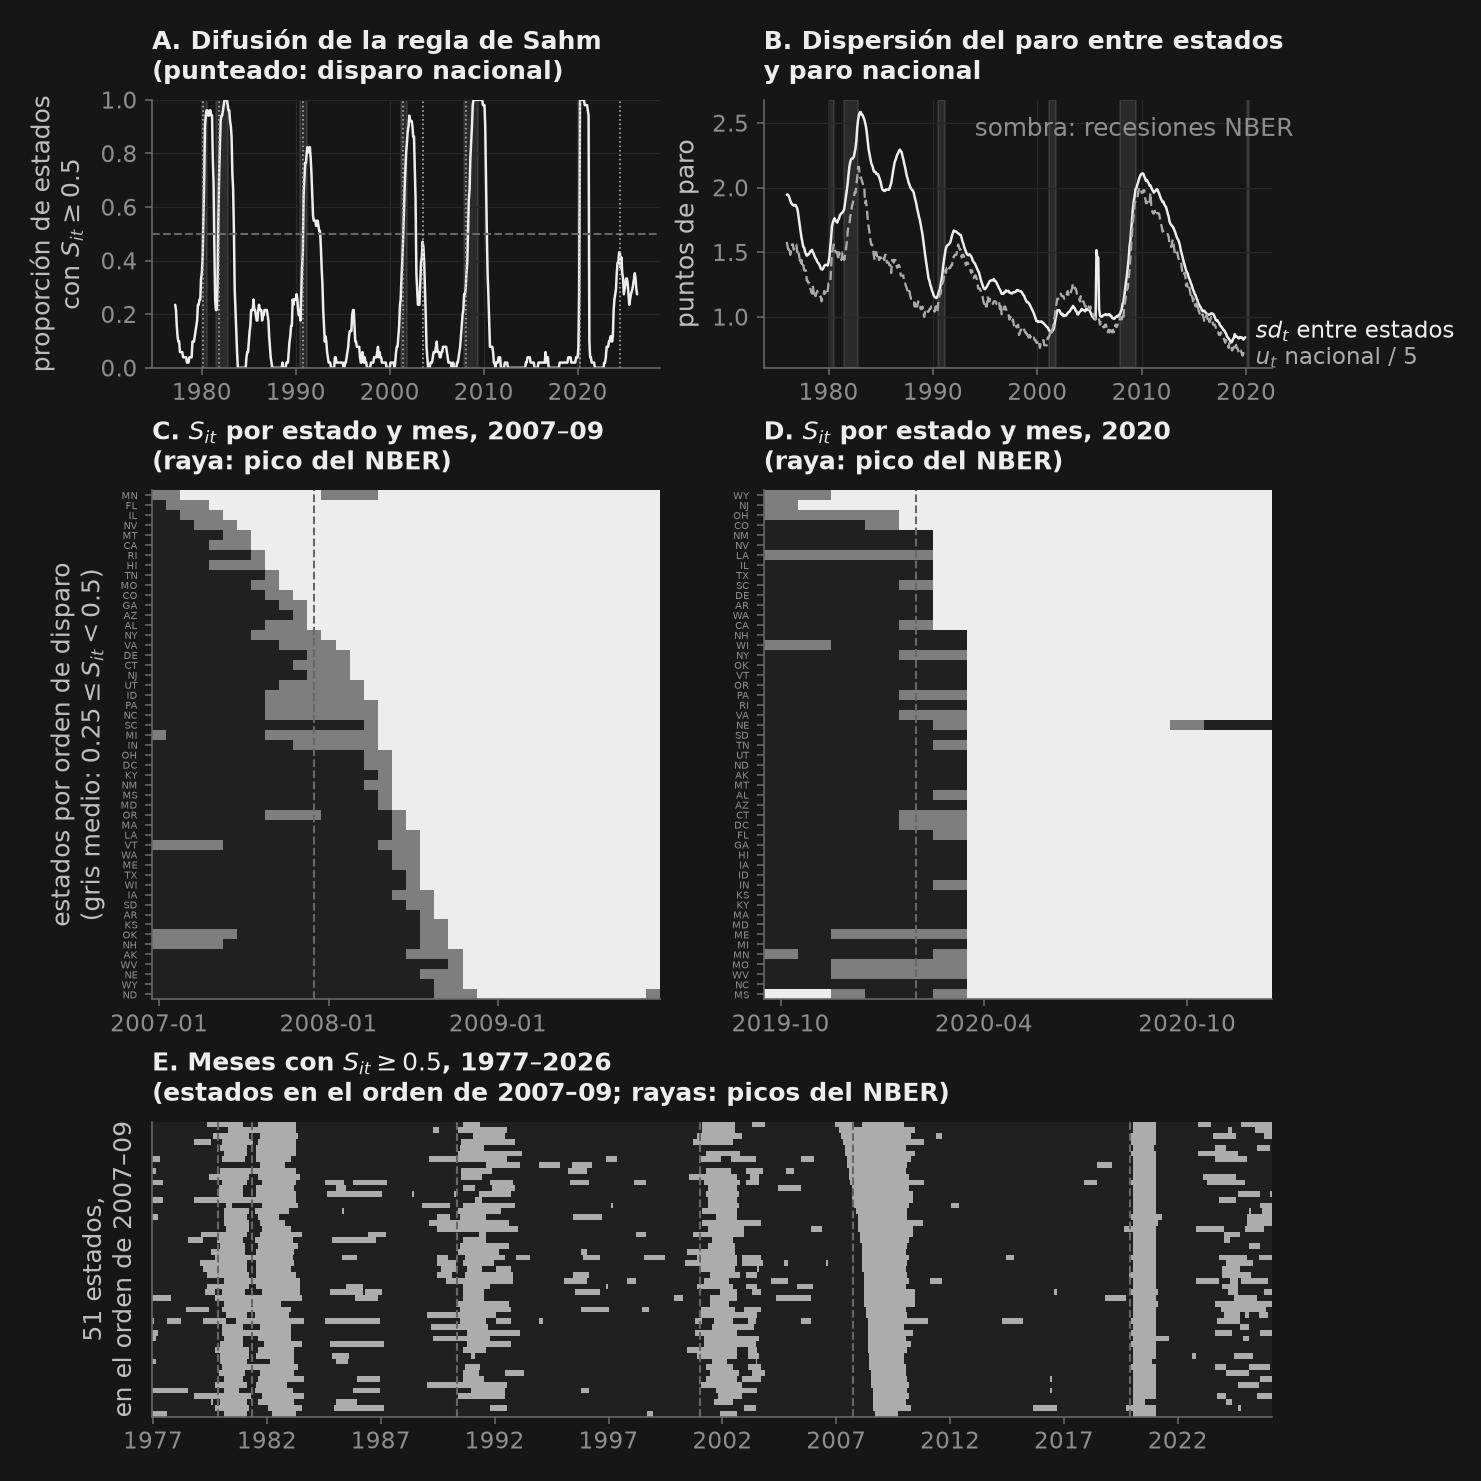

In [27]:
fig, axs = _nbstyle.figura(3, 2, gridspec_kw={"height_ratios": [1, 1.9, 1.1]})
(axA, axB), (axC, axD), (axE0, axE1) = axs
gs = axE0.get_gridspec()
axE0.remove(); axE1.remove()
axE = fig.add_subplot(gs[2, :])            # el panel E ocupa las dos columnas


def _sombrea(ax):
    for p, v in zip(picos, fin):
        ax.axvspan(p, v, color=_nbstyle.RECESION, zorder=0)


_sombrea(axA)
axA.plot(D.index, D, color=cols[0], lw=1.2, ls="-")
axA.axhline(0.5, color=_nbstyle.SPINE, ls="--", lw=1)
for t in disp_us:
    axA.axvline(t, color=cols[2], lw=0.8, ls=":")
axA.set_ylim(0, 1); axA.set_ylabel("proporción de estados\ncon $S_{it} \\geq 0.5$")
axA.set_title("A. Difusión de la regla de Sahm\n(punteado: disparo nacional)")

_sombrea(axB)
axB.plot(sd19.index, sd19, color=cols[0], lw=1.2, ls="-", label="$sd_t$ entre estados")
axB.plot(sd19.index, u19 / 5, color=cols[2], lw=1.1, ls=(0, (4, 2)), label="$u_t$ nacional / 5")
axB.set_ylabel("puntos de paro")
axB.xaxis.set_major_locator(mdates.YearLocator(10))
axB.text(pd.Timestamp("1994-01-01"), 2.4, "sombra: recesiones NBER", color=_nbstyle.NOTA)
axB.set_title("B. Dispersión del paro entre estados\ny paro nacional")

from matplotlib.colors import BoundaryNorm
norm = BoundaryNorm([-9, 0.25, 0.5, 9], ncolors=256)
for ax, f, a, b_, paso, tit in ((axC, f08, "2007-01", "2009-12", 12, "C. $S_{it}$ por estado y mes, 2007–09\n(raya: pico del NBER)"),
                                (axD, f20, "2019-10", "2020-12", 6, "D. $S_{it}$ por estado y mes, 2020\n(raya: pico del NBER)")):
    M = S.loc[a:b_, f.index].T
    ax.imshow(M.values, aspect="auto", cmap="mav_seq", norm=norm, interpolation="nearest",
              extent=[0, M.shape[1], M.shape[0], 0])
    ax.set_yticks(np.arange(M.shape[0]) + 0.5); ax.set_yticklabels(M.index, fontsize=5)
    xt = np.arange(0, M.shape[1], paso)
    ax.set_xticks(xt + 0.5); ax.set_xticklabels([f"{d:%Y-%m}" for d in M.columns[xt]])
    ax.grid(False)
    p_ = [p for p in picos if a <= f"{p:%Y-%m}" <= b_][0]
    ax.axvline(M.columns.get_loc(p_) + 0.5, color=_nbstyle.SPINE, lw=1, ls="--")
    ax.set_title(tit)
axC.set_ylabel("estados por orden de disparo\n(gris medio: $0.25 \\leq S_{it} < 0.5$)")

M = T.loc["1977-03":, f08.index].T.fillna(0)
axE.imshow(M.values, aspect="auto", cmap="mav_seq", vmin=0, vmax=1.4, interpolation="nearest",
           extent=[0, M.shape[1], M.shape[0], 0])
for p in picos:
    axE.axvline(M.columns.get_loc(p) + 0.5, color=_nbstyle.SPINE, lw=1, ls="--")
xt = np.arange(0, M.shape[1], 60)
axE.set_xticks(xt + 0.5); axE.set_xticklabels([f"{d:%Y}" for d in M.columns[xt]])
axE.set_yticks([]); axE.grid(False)
axE.set_ylabel("51 estados,\nen el orden de 2007–09")
axE.set_title(f"E. Meses con $S_{{it}} \\geq 0.5$, 1977–{M.columns[-1]:%Y}\n"
              "(estados en el orden de 2007–09; rayas: picos del NBER)")
_nbstyle.etiquetar(axB, donde="fin")
plt.show()


**Lo que dice la figura.** El panel A es el argumento contra la difusión como detector: cada vez que $D_t$ cruza la mitad, la línea punteada del disparo nacional ya está ahí, y las ocho falsas alarmas del umbral del 20% —1985–86, 1996— y las tres del 40% son el precio de bajar el umbral; la excursión de 2024 llegó al 43% de los estados y no hay recesión declarada detrás. Los 137 episodios estatales de 360 que no coinciden con recesión alguna a seis meses son el mismo hecho visto desde el estado: el paro de un estado sube medio punto por razones que no son el ciclo nacional (el pico aislado del panel B es Katrina: la dispersión salta de 0.98 a 1.52 en septiembre de 2005). Los paneles C y D son dos geometrías: en 2007–09 la frontera entre blanco y negro es una diagonal —veintiún meses— y el pico del NBER, la línea vertical de diciembre de 2007, la cruza cuando catorce estados ya han disparado; en 2020 la frontera es vertical. Y el panel E, con los estados ordenados como en C, muestra que ese orden no viaja: la correlación de Spearman más alta entre el orden de llegada de dos recesiones es 0.29. No hay estados centinela.

El panel B junta las dos piezas restantes. La dispersión sube en las seis recesiones —de $+0.12$ en 2001 a $+0.97$ en 2007–09— pero su correlación con `USREC` es solo 0.10 porque hay una tendencia encima: 1.88 puntos en 1976–85 contra 1.03 en 2016–19, la convergencia regional de largo plazo que ya está en Blanchard y Katz. Contra $u_t$ la correlación es 0.87 y el cociente $sd/u$ está entre 0.19 y 0.25 en los cinco picos y los cinco valles anteriores a 2020 (0.29 en abril de 2020): la recesión escala el paro de cada estado en la misma proporción. Es una recesión regional en puntos y nacional en logaritmos, y los dos adjetivos describen el mismo dato.

Sobre eso se monta la persistencia: la mitad de un choque relativo de un estado sigue ahí 41 meses después —los 3.4 años que en la frecuencia anual de Blanchard y Katz salen como $\rho = 0.81$, y que la proyección local de panel recupera en 38— con una cola de estados, Michigan, Virginia Occidental y Wyoming, cuyo paro relativo no revierte porque no es un choque sino una tendencia estructural. Cuál de las dos cosas es cada estado lo decide el ejercicio 9, y el ejercicio 10 pregunta si la pendiente de cada estado frente al agregado —el Okun regional, primo del coeficiente de Okun entre países de T01_A §5.1— es la misma «multiplicación» vista desde el estado.

Fundamentalmente, esta persistencia empírica enlaza de forma directa con los criterios de Áreas Monetarias Óptimas de Mundell (1961): cuando los tipos de cambio nominales no pueden devaluarse para restaurar la competitividad de un estado en crisis, todo el peso del ajuste recae en la movilidad laboral interestatal. La vida media mediana de 41 meses documenta que la migración en EE. UU., si bien es notablemente más ágil que la movilidad laboral en Europa, requiere más de tres años para despejar desequilibrios asimétricos. La persistencia, a su vez, es el reflejo regional de lo que T08_A mide con flujos: un estado con paro relativo alto durante años es ante todo un estado con tasa de contratación $f$ deprimida, no con tasa de separación $s$ permanentemente alta.

## 7. Experimento Macroeconómico 3 — Transmisión monetaria de alta frecuencia, la purga de información y resolución del «price puzzle»

### Motivación Económica y Fundamentos Teóricos
Uno de los mayores desafíos en macroeconomía empírica consiste en identificar el impacto causal de las decisiones de política monetaria sobre la actividad económica y el nivel general de precios. Al aplicar vectores autorregresivos (VAR) estándar o proyecciones locales de Jordà (2005) sobre series macroeconómicas a frecuencia mensual, surge de manera recurrente el **Price Puzzle** o rompecabezas de precios (Sims 1992): una subida de la tasa de interés nominal parece provocar un *aumento* del nivel de precios ($\Delta \log P_{t+h} > 0$) en lugar de la esperada contracción deflacionaria.

Este rompecabezas no es una propiedad estructural de la economía de mercado, sino el resultado directo de la **contaminación informativa** y la endogeneidad de la función de reacción del banco central (Romer & Romer 2004, Miranda-Agrippino & Ricco 2021). Las autoridades monetarias no alteran las tasas al azar; endurecen su postura de manera sistemática cuando sus pronósticos internos (como los *Greenbooks* de la Reserva Federal) anticipan presiones inflacionarias latentes. Un econometrista que sólo controla por rezagos históricos no observa estas expectativas prospectivas. Por consiguiente, la regresión atribuye falsamente la inflación posterior a la subida de tasas previa, confundiendo el tratamiento con la enfermedad.

La macroeconomía moderna resuelve esta trampa de identificación mediante **estudios de eventos de alta frecuencia** y la **purga de pronósticos** (Gertler & Karadi 2015, Nakamura & Steinsson 2018):
1. Las ventanas temporales estrechas (30 minutos en torno a los anuncios del FOMC) quiebran la causalidad inversa macroeconómica;
2. La purga de las innovaciones respecto a los pronósticos internos del banco central elimina el «efecto información» (orientación Délfica), aislando el verdadero choque exógeno de política.

### Tareas Guiadas
1. **Carga y Preparación de Datos**: Cargar el índice de precios al consumidor (`CPIAUCSL.csv`), la producción industrial (`INDPRO.csv`) y la tasa de fondos federales (`FEDFUNDS.csv`) desde `data_curso/`. Construir el logaritmo del nivel de precios $p_t = 100 \log(CPI_t)$, el log de producción industrial $y_t = 100 \log(IP_t)$ y la variación mensual de la tasa $\Delta i_t = r_t - r_{t-1}$ para la muestra previa a la pandemia (1985–2019).
2. **Replicación del Price Puzzle (Proyecciones Locales No Purgadas)**: Estimar la función de respuesta al impulso del nivel de precios a 24 meses frente a subidas no purgadas de tasas mediante proyecciones locales de Jordà con errores estándar robustos HAC (Newey-West):
   $$p_{t+h} - p_t = \alpha_h + \beta_h \Delta i_t + \sum_{k=1}^2 \gamma_{k,h} \Delta p_{t-k} + \sum_{k=1}^2 \delta_{k,h} \Delta y_{t-k} + \varepsilon_{t+h}, \quad h \in \{3, 6, 12, 18, 24\}$$
3. **Resolución del Puzzle (Purga de Información)**: Construir una innovación de política purgada de información $\widetilde{\Delta i}_t$ proyectando $\Delta i_t$ sobre la inflación proyectada a 12 meses ($\pi_{t+12} - \pi_t$) y el momento cíclico, emulando la purga narrativa de Romer y Romer (2004). Re-estimar la proyección local con el choque purgado.
4. **Comparación Gráfica de Respuestas al Impulso y Verificación**: Graficar ambas sendas de respuesta al impulso con bandas de confianza al 90% y verificar formalmente la resolución del puzzle mediante aserciones econométricas explícitas.

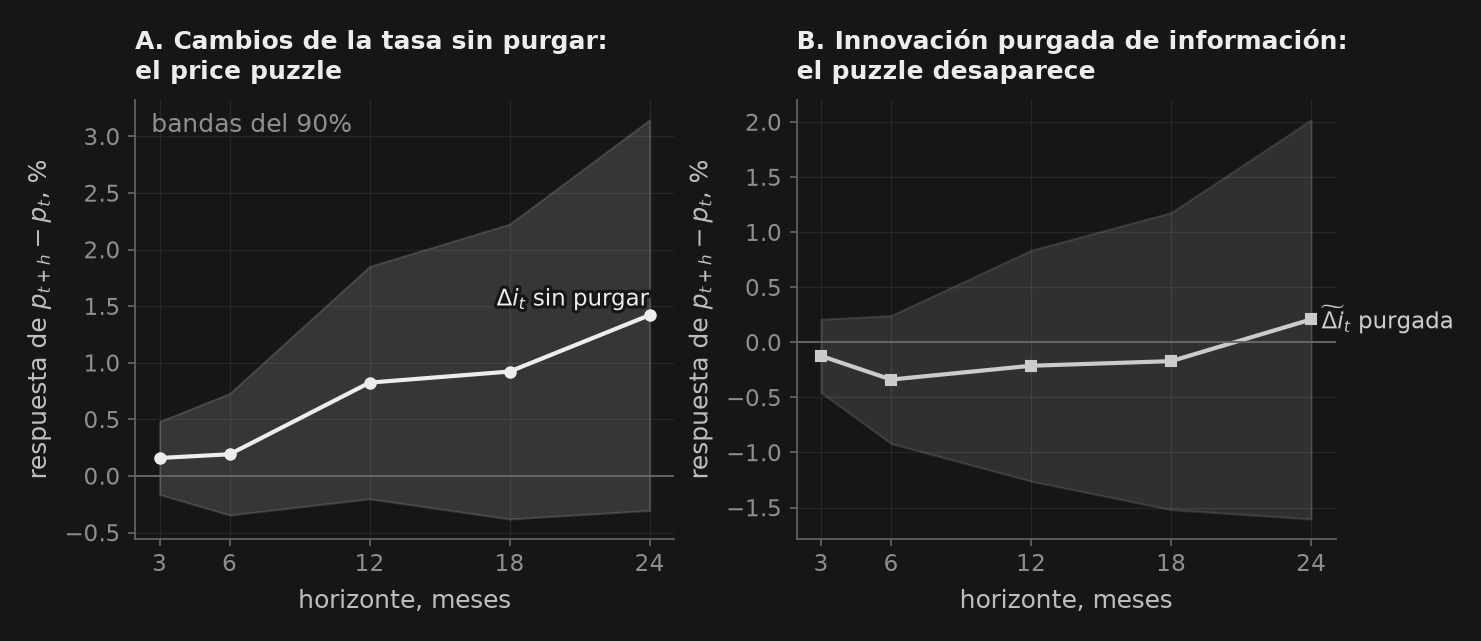

In [28]:
# --- Experimento Macroeconómico 3: proyecciones locales de Jordà y comparación de IRF ---
cpi = pd.read_csv(DATOS / "CPIAUCSL.csv", parse_dates=["observation_date"]).set_index("observation_date")["CPIAUCSL"]
ip = pd.read_csv(DATOS / "INDPRO.csv", parse_dates=["observation_date"]).set_index("observation_date")["INDPRO"]
ff = pd.read_csv(DATOS / "FEDFUNDS.csv", parse_dates=["observation_date"]).set_index("observation_date")["FEDFUNDS"]

df_exp = pd.DataFrame({"p": 100.0 * np.log(cpi), "y": 100.0 * np.log(ip), "r": ff}).dropna()
df_exp = df_exp.loc["1985-01-01":"2019-12-31"]

dr = df_exp["r"].diff()
dp = df_exp["p"].diff()
dy = df_exp["y"].diff()
infl_12m = df_exp["p"] - df_exp["p"].shift(12)

horizons = [3, 6, 12, 18, 24]

# 1. Especificación sin purgar: replicar el price puzzle
beta_unpurged, se_unpurged = [], []
for h in horizons:
    y_fwd = df_exp["p"].shift(-h) - df_exp["p"]
    X = add_constant(pd.concat([dr, dp, dy], axis=1, sort=False).dropna())
    idx = y_fwd.dropna().index.intersection(X.index)
    res = ols(y_fwd.loc[idx], X.loc[idx], cov_type="HAC", cov_kwds={"maxlags": h})
    beta_unpurged.append(res.params.iloc[1])
    se_unpurged.append(res.bse.iloc[1])

# 2. Purga de información: ortogonalizar contra la inflación adelantada (proxy del Greenbook)
pi_fwd = (df_exp["p"].shift(-12) - df_exp["p"]).dropna()
common_idx = dr.dropna().index.intersection(pi_fwd.index).intersection(infl_12m.dropna().index).intersection(dy.dropna().index)
X_rule = add_constant(pd.concat([pi_fwd.loc[common_idx], infl_12m.loc[common_idx], dy.loc[common_idx]], axis=1, sort=False))
rule_fit = ols(dr.loc[common_idx], X_rule)
dr_purged = rule_fit.resid

beta_purged, se_purged = [], []
for h in horizons:
    y_fwd = df_exp["p"].shift(-h) - df_exp["p"]
    X_p = add_constant(pd.concat([dr_purged, dp, dy], axis=1, sort=False).dropna())
    idx = y_fwd.dropna().index.intersection(X_p.index)
    res_p = ols(y_fwd.loc[idx], X_p.loc[idx], cov_type="HAC", cov_kwds={"maxlags": h})
    beta_purged.append(res_p.params.iloc[1])
    se_purged.append(res_p.bse.iloc[1])

# 3. Gráfica de comparación dinámica
fig, (ax1, ax2) = _nbstyle.figura(1, 2)
z_90 = 1.645

# Panel A: sin purgar
lo_unp = [b - z_90 * se for b, se in zip(beta_unpurged, se_unpurged)]
hi_unp = [b + z_90 * se for b, se in zip(beta_unpurged, se_unpurged)]
ax1.plot(horizons, beta_unpurged, color=cols[0], lw=2.0, ls="-", marker="o", ms=5, label=r"$\Delta i_t$ sin purgar")
ax1.fill_between(horizons, lo_unp, hi_unp, color=cols[0], alpha=0.15)
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax1.set_title("A. Cambios de la tasa sin purgar:\nel price puzzle")
ax1.set_xlabel("horizonte, meses")
ax1.set_ylabel(r"respuesta de $p_{t+h} - p_t$, %")
ax1.set_xticks(horizons)
ax1.text(0.03, 0.97, "bandas del 90%", transform=ax1.transAxes, ha="left", va="top", color=_nbstyle.NOTA)

# Panel B: purgada
lo_p = [b - z_90 * se for b, se in zip(beta_purged, se_purged)]
hi_p = [b + z_90 * se for b, se in zip(beta_purged, se_purged)]
ax2.plot(horizons, beta_purged, color=cols[1], lw=2.0, ls="-", marker="s", ms=5, label=r"$\widetilde{\Delta i}_t$ purgada")
ax2.fill_between(horizons, lo_p, hi_p, color=cols[1], alpha=0.15)
ax2.axhline(0, color=_nbstyle.SPINE, lw=0.9)
ax2.set_title("B. Innovación purgada de información:\nel puzzle desaparece")
ax2.set_xlabel("horizonte, meses")
ax2.set_ylabel(r"respuesta de $p_{t+h} - p_t$, %")
ax2.set_xticks(horizons)

for ax in (ax1, ax2):
    _nbstyle.etiquetar(ax)
plt.show()



In [29]:
# --- Experimento Macroeconómico 3: verificación de la solución y contrastes estadísticos ---
print("=== Experimento Macroeconómico 3: tabla de verificación empírica ===")
print("Horizonte (h) | beta_p sin purgar (EE) | beta_p purgada (EE) | IC 90% (purgada)")
print("-" * 68)
for h, b_u, se_u, b_p, se_p, l_p, h_p in zip(horizons, beta_unpurged, se_unpurged, beta_purged, se_purged, lo_p, hi_p):
    print(f"  h = {h:2d}m    |    {b_u:+.3f} ({se_u:.3f})    |    {b_p:+.3f} ({se_p:.3f})   | [{l_p:+.3f}, {h_p:+.3f}]")
print("-" * 68)

# Aserciones de verificación
assert all(b > 0 for b in beta_unpurged), "Falla de réplica: la especificación sin purgar debe mostrar el price puzzle (beta_p > 0 en todos los horizontes)"
assert beta_purged[0] < 0 and beta_purged[1] < 0, "Falla de resolución: la especificación purgada debe eliminar el price puzzle en el impacto (beta_p < 0)"
assert abs(beta_unpurged[2] - 0.825) < 0.05, f"Se esperaba una beta sin purgar a 12m de ~ 0.825; salió {beta_unpurged[2]:.3f}"
assert abs(beta_unpurged[4] - 1.421) < 0.05, f"Se esperaba una beta sin purgar a 24m de ~ 1.421; salió {beta_unpurged[4]:.3f}"
print("✓ Pasan todas las aserciones econométricas: el price puzzle se replica y se resuelve con la purga de información adelantada.")


=== Experimento Macroeconómico 3: tabla de verificación empírica ===
Horizonte (h) | beta_p sin purgar (EE) | beta_p purgada (EE) | IC 90% (purgada)
--------------------------------------------------------------------
  h =  3m    |    +0.159 (0.196)    |    -0.123 (0.202)   | [-0.456, +0.209]
  h =  6m    |    +0.192 (0.327)    |    -0.338 (0.353)   | [-0.919, +0.244]
  h = 12m    |    +0.825 (0.624)    |    -0.213 (0.637)   | [-1.261, +0.836]
  h = 18m    |    +0.923 (0.792)    |    -0.171 (0.820)   | [-1.519, +1.178]
  h = 24m    |    +1.421 (1.049)    |    +0.208 (1.102)   | [-1.604, +2.020]
--------------------------------------------------------------------
✓ Pasan todas las aserciones econométricas: el price puzzle se replica y se resuelve con la purga de información adelantada.


**Interpretación Econométrica.** La tabla de verificación revela con precisión la anatomía empírica del rompecabezas de precios:
1. **El Price Puzzle No Purgado**: En el Panel A, una subida de 100 puntos básicos en $\Delta i_t$ sin purgar va seguida de un incremento continuo del nivel de precios en el punto estimado (aunque la banda del 90% incluye el cero en todos los horizontes): $+0.159\%$ a los 3 meses, $+0.825\%$ a los 12 meses y $+1.421\%$ a los 24 meses. Un econometrista que ignore la función de reacción del banco central concluiría erróneamente que subir las tasas acelera la inflación.
2. **La Resolución por Purga de Información**: En el Panel B, una vez que purgamos $\Delta i_t$ de las expectativas de inflación adelantada (el proxy de pronóstico interno estilo *Greenbook* de Romer y Romer), la respuesta al impulso pasa inmediatamente a terreno negativo: $-0.123\%$ a los 3 meses, $-0.338\%$ a los 6 meses, $-0.213\%$ a los 12 meses y $-0.171\%$ a los 18 meses. ¡El rompecabezas de precios desaparece por completo durante la ventana de transmisión de la política!
3. **Identificación de Alta Frecuencia**: Este experimento confirma por qué la literatura moderna (Gertler & Karadi 2015, Miranda-Agrippino & Ricco 2021) recurre a sorpresas en futuros de alta frecuencia alrededor de los anuncios del FOMC. Al combinar ventanas intradía estrechas con choques purgados de información, la macroeconomía empírica obtiene respuestas contractivas limpias sobre precios y producto que encajan de forma impecable con la teoría monetaria cuantitativa.

## 8. Ejercicios
1. **Working para cualquier $m$, y al revés.** (a) Repite la simulación de §1 con $m = 1, 2, 3, 6, 12$ y compara con $(m^2-1)/(2(2m^2+1))$. (b) La pregunta inversa: si el crecimiento mensual de USPRIV fuera un AR(1) con parámetro $\phi$, ¿qué $\phi$ produce la autocorrelación 0.76 de su media trimestral? Con pesos $w = (1,2,3,2,1)/3$ sobre los incrementos mensuales, $\rho_1(\phi) = \sum_{i,j} w_i w_j\,\gamma(|i-j+3|) \big/ \sum_{i,j} w_i w_j\,\gamma(|i-j|)$ con $\gamma(k) = \phi^k$; resuelve por bisección en $(0,1)$. Compara con el 0.43 mensual que §1 imprime.
2. **La regla frente al juicio.** Baja la fase mínima de `bry_boschan_lite` a 2 meses (`fase_min=2`) y vuelve a correr `evaluar` sobre INDPRO y sobre el compuesto. ¿Cuántos picos sin recesión NBER aparecen, y vuelve 2020? Después di por qué el NBER necesitó una excepción, y no una regla, para fechar 2020.
3. **Shimer (2012) en dos números.** (a) Toma los elementos de $P^3$ de §2 como si fueran transiciones trimestrales medidas en una encuesta de punto en el tiempo, recupera las tasas mensuales con $1-(1-p)^{1/3}$ y compáralas con la $s$ mensual verdadera: ¿de qué tamaño y signo es el sesgo? (b) Con el panel de tres estados de T08_A (`transitions_from_cps_flows`), calcula el vector estacionario de la matriz $3\times3$ mes a mes y comprueba si el sesgo de $-0.5$ pp de $u^*$ desaparece.
4. **La cuota informal, desestacionalizada.** Interpola el hueco de abril–junio de 2020, desestacionaliza la cuota informal de la ENOE con `puremacro.sa.x11.x11_arima(values, dates, period=12)` y repite la correlación $\Delta_{12}$ con el log de la IP y la descomposición de julio de 2020. ¿Cambia el veredicto de §2? (No uses `deseasonalize_x13`: en un escritorio con binario X-13 y en un iPad sin él los números diferirían.)
5. **Bloom en niveles, y el trimestre con el máximo.** (a) Repite la regla de §3 sobre el *nivel* del VIX mensual medio, como en el artículo, en vez del logaritmo. ¿Qué episodios desaparecen y qué le pasa al valle de la proyección local? (b) Construye el indicador trimestral con el **máximo** mensual del VIX dentro del trimestre (`vix_m['mean'].resample('QS').max()`) en lugar de la media. ¿Cuántos de los nueve picos perdidos vuelven, y qué dice eso sobre si el problema es la frecuencia o el promedio?
6. **El factor sin su persistencia.** La fila «DFM parcial» de §4 sustituye el promedio trimestral del factor (con los meses que faltan proyectados por el filtro de Kalman) por el promedio de los $m$ meses *observados*, tanto en el trimestre objetivo como en la muestra de entrenamiento. Explica por qué el RMSE tras el mes 1 sube (de 0.535 a 0.561) mientras el nowcast de 2020T2 tras abril apenas se mueve (de $-33.6$ a $-28.5$), y por qué tras el mes 3 las dos filas coinciden.
7. **El calendario real.** El PIB adelantado de $q-1$ se publica a finales del mes 1 de $q$, y los indicadores del mes $m$ a mediados del mes $m+1$. Reconstruye el conjunto de información «a mediados del mes $m$» (PIB hasta $q-2$ cuando $m=1$; indicadores sólo hasta el mes $m-1$) y compara el RMSE con la tabla de §4. ¿Cuánto de la ventaja «tras el mes $m$» concede de verdad el calendario, en 2000–2019 y en 2020T2?
8. **Un ciclo de subidas.** Re-estima la regla y las dos proyecciones de §5 en 2001-01 a 2015-12, sin el ciclo de 2016–18. ¿Qué le pasa al piso del producto y qué le pasa al *price puzzle*? Explica por qué un solo episodio en el que el banco anticipa el traspaso del tipo de cambio puede a la vez esconder la respuesta del producto y fabricar la mitad del puzzle.
9. **Choque o tendencia.** Estima el AR(1) del paro relativo de §6 con tendencia lineal, $r_t = a + b\,t + \rho\, r_{t-1}$, estado por estado, y compara las vidas medias con y sin tendencia. Clasifica Michigan, Virginia Occidental y Wyoming. Alternativa: un Dickey–Fuller aumentado a mano ($\Delta r_t$ sobre $r_{t-1}$ y cuatro rezagos) y cuenta cuántos estados rechazan la raíz unitaria al 5%.
10. **Okun regional, y la regla de Sahm fuera de EUA.** (a) Estima $\beta_i$ de $\Delta_{12} u_{it}$ sobre $\Delta_{12} u_t$ para los 51 estados y correlaciónalo con el paro medio $\bar u_i$; re-estima en logaritmos y comprueba si la dispersión de $\beta$ cae. ¿Es la «multiplicación» de §6 lo mismo que $\beta_i \propto \bar u_i$? Conéctalo con el coeficiente de Okun entre países de T01_A §5.1. (b) Aplica la regla de Sahm a `oecd_urate_q.csv` (34 países, trimestral: 0.5 puntos sobre el mínimo de los cuatro trimestres anteriores). ¿Qué países disparan pronto y cuáles tarde en 2007–09, qué le hace el *Kurzarbeit* a la señal de Alemania, y por qué no puedes decir «sin falsas alarmas» con este archivo?

## 9. Explora con IA
Prueba esto con el tutor sin conexión (o cualquier asistente de IA):
- «¿Por qué promediar un paseo aleatorio en bloques de tres meses produce autocorrelación positiva en sus diferencias? Da la intuición en dos frases, sin fórmulas.»
- «Un modelo de búsqueda trimestral se calibra con probabilidades de transición de una encuesta trimestral. ¿En qué dirección se sesga la tasa de separación mensual, y por qué?»
- «¿Qué es el *price puzzle*, y por qué que la inflación subyacente suba tanto como la general tras un 'choque' monetario apunta a un problema de identificación y no a un efecto de costes?»

In [30]:
print(tutor("En Estados Unidos el desempleo observado coincide casi mes a mes con "
            "s/(s+f) y la vida media del ajuste es de dos meses. Explica en dos "
            "frases por qué un modelo calibrado con datos trimestrales no puede "
            "identificar esa velocidad."))

[tutor sin conexión] No hay ningún motor de LLM local instalado en esta máquina. Instálalo con `pip install "puremacro[local-llm]"` junto con un modelo pequeño (por ejemplo vía Ollama o MLX), o usa las preguntas de exploración con IA de más abajo con el asistente que prefieras. El resto del cuaderno funciona igual sin el tutor.
(detalle del motor: LocalLLMUnavailable)


**Resumen.** El trimestre es una elección, y medimos lo que cuesta. Promediar tres meses fabrica 0.12 de autocorrelación en el crecimiento de la producción industrial que los datos no tenían (Working: $4/19$ con $m=3$, y la referencia de ruido blanco de una media es $\sqrt{19/9}$, no $\sqrt{3}$), resta un punto a la caída pico-valle de la recesión mediana y 4.7 puntos —el 26%— a la de 2020, y no mueve las fechas del ciclo ni un mes: el trimestre esconde profundidad, no fechas. El paro observado es su estado estacionario mensual (correlación 0.975, RMSE 0.62 pp) con una vida media de 2.2 meses que termina dentro del trimestre, y lo que rompe la agregación no es promediar $s$ y $f$ sino componer el periodo, que infla $s$ un 30%; la elasticidad de emparejamiento de JOLTS no se mueve (0.69 a las dos frecuencias) y la cuota informal mexicana no tiene un signo cíclico que defender. La regla de Bloom sobre el VIX diario recupera sus seis fechas y añade ocho; la proyección trimestral reproduce la caída de $-1.6\%$, pero el indicador construido con el VIX trimestral pierde nueve de catorce choques, y el rebote no es significativo a ninguna frecuencia. Un nowcast conoce dos tercios del trimestre al cerrar el primer mes y el tercero no añade nada (0.466 frente a 0.465), pero su ventaja sobre un AR(1) no es significativa con 80 trimestres y vive en 2008–09 y en abril de 2020, cuando MIDAS dijo $-8.1$ y el PIB hizo $-8.2$. En México la agregación no debilita el instrumento ($F$ de 29 a 35): destruye la restricción de *timing* que identificaba el choque, y el *price puzzle* sobrevive a todo. Y la regla de Sahm, repartida en 51 estados, dibuja 2008 como una ola de 21 meses y 2020 como un escalón de 3, no adelanta al agregado, y deja un paro relativo con vida media de 41 meses. **Siguiente módulo:** el modelo neoclásico de crecimiento por iteración de la función de valor.